# RAMMs Contact Classifier
Geometry-first contact and jamming analysis for a 2-unit polycatenated system.

This notebook studies how the configuration of two interlocked unit cells
changes the contact state of the system. Starting from a reference geometry,
the top unit is rotated and/or  vertically shifted, then the code:

1. computes the updated node/segment geometry,
2. evaluates gap functions that represent admissible contact conditions,
3. detects whether the configuration is free, contacting, or invalid,
4. builds a contact Jacobian from the active smooth constraints, and
5. classifies whether the contacting configuration is locally jammed or still
   has feasible tangent motion.

The goal is to create a configuration-to-state pipeline:
configuration -> contact pattern -> active constraints -> mobility state

This supports the larger research goal of identifying which deployed
configurations of polycatenated architected materials are geometrically stiff
(jammed) before adding force-response and slip analysis.

### Imports

In [15]:
# cell 1
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
plt.style.use("seaborn-v0_8-whitegrid")
import plotly.graph_objects as go
import copy
import re
import pprint
from math import cos, sin, radians
from plotly.subplots import make_subplots
from collections import Counter
from scipy.optimize import root
from IPython.display import display # for printing things in LaTex
from matplotlib.lines import Line2D

### Establish Global Tolerances

In [16]:
# ------------------------------------------------------------
# Global numerical tolerances
# ------------------------------------------------------------
TOL = {
    "gap_contact": 1e-5,     # treat |gap| <= this as contact
    "gap_overlap": -1e-5,    # gap < this means invalid overlap
    "root": 1e-6,            # root-finding / boundary solve tolerance
    "svd": 1e-10,            # nullspace / rank tolerance
    "theta_fd": 1e-5,        # finite diff step in theta
    "z_fd": 1e-6,           # finite diff step in z
}

def classify_gap_value(g, gap_tol=None):
    """
    Classify one scalar gap value using a single global tolerance policy.
    """
    if gap_tol is None:
        gap_tol = TOL["gap_contact"]

    if g < -gap_tol:
        return "invalid_overlap"
    elif abs(g) <= gap_tol:
        return "contact"
    else:
        return "free"

### Establish Palette for Graphs

In [17]:
# cell 2
# for plots
palette = {
    "free": "#2A9D8F",           # teal
    "single-contact": "#E9C46A",      # sand
    "double-contact": "#E76F51",                 # blood orange
    "invalid_overlap": "#264653",  # dark blue
}

## Geometry Layer

### Symbolic Node Definitions

In [ ]:
# ------------------------------------------------------------
# Define symbolic node coordinates
# ------------------------------------------------------------

# Unit 0 nodes
y0B, z0B = sp.symbols('y0B z0B', real=True)
y0L, z0L = sp.symbols('y0L z0L', real=True)
y0R, z0R = sp.symbols('y0R z0R', real=True)
y0T, z0T = sp.symbols('y0T z0T', real=True)

# Unit 1 nodes
y1B, z1B = sp.symbols('y1B z1B', real=True)
y1L, z1L = sp.symbols('y1L z1L', real=True)
y1R, z1R = sp.symbols('y1R z1R', real=True)
y1T, z1T = sp.symbols('y1T z1T', real=True)

# Unit 2 nodes
y2B, z2B = sp.symbols('y2B z2B', real=True)
y2L, z2L = sp.symbols('y2L z2L', real=True)
y2R, z2R = sp.symbols('y2R z2R', real=True)
y2T, z2T = sp.symbols('y2T z2T', real=True)

# Unit 3 nodes
y3B, z3B = sp.symbols('y3B z3B', real=True)
y3L, z3L = sp.symbols('y3L z3L', real=True)
y3R, z3R = sp.symbols('y3R z3R', real=True)
y3T, z3T = sp.symbols('y3T z3T', real=True)

# Unit 4 nodes
y4B, z4B = sp.symbols('y4B z4B', real=True)
y4L, z4L = sp.symbols('y4L z4L', real=True)
y4R, z4R = sp.symbols('y4R z4R', real=True)
y4T, z4T = sp.symbols('y4T z4T', real=True)

# ------------------------------------------------------------
# Node list
# ------------------------------------------------------------

nodes = [
    # Unit 0
    sp.Matrix([y0B, z0B]),  # 0
    sp.Matrix([y0L, z0L]),  # 1
    sp.Matrix([y0R, z0R]),  # 2
    sp.Matrix([y0T, z0T]),  # 3

    # Unit 1
    sp.Matrix([y1B, z1B]),  # 4
    sp.Matrix([y1L, z1L]),  # 5
    sp.Matrix([y1R, z1R]),  # 6
    sp.Matrix([y1T, z1T]),  # 7

    # Unit 2
    sp.Matrix([y2B, z2B]),  # 8
    sp.Matrix([y2L, z2L]),  # 9
    sp.Matrix([y2R, z2R]),  # 10
    sp.Matrix([y2T, z2T]),  # 11
]

In [ ]:
#TODO: update to accomidate motion in y
def build_symbolic_nodes(n_units):
    """
    Create symbolic coordinates and node list.

    Returns
    -------
    symbols : dict

    nodes : list
        [0B,0L,0R,0T,1B,1L,...]
    """

    symbols = {}
    nodes = []

    for unit in range(n_units):

        symbols[unit] = {}

        for label in ["B", "L", "R", "T"]:

            y, z = sp.symbols(
                f"y{unit}{label} z{unit}{label}",
                real=True
            )

            symbols[unit][label] = {
                "y": y,
                "z": z
            }

            nodes.append(
                sp.Matrix([y, z])
            )

    return symbols, nodes

In [36]:
def print_nodes(nodes):
    print(f"Chain length: {len(nodes)/4} nodes")
    for i, node in enumerate(nodes):
        print(f"{i:2d}: {node}")

def print_units(sym):
    for u in sym:
        print(f"\nUnit {u}")
        for n in ["B","L","R","T"]:
            y = sym[u][n]["y"]
            z = sym[u][n]["z"]
            print(f"  {n}: [{y}, {z}]")

In [38]:
SYMS, nodes = build_symbolic_nodes(5)
print_nodes(nodes)

Chain length: 5.0 nodes
 0: Matrix([[y0B], [z0B]])
 1: Matrix([[y0L], [z0L]])
 2: Matrix([[y0R], [z0R]])
 3: Matrix([[y0T], [z0T]])
 4: Matrix([[y1B], [z1B]])
 5: Matrix([[y1L], [z1L]])
 6: Matrix([[y1R], [z1R]])
 7: Matrix([[y1T], [z1T]])
 8: Matrix([[y2B], [z2B]])
 9: Matrix([[y2L], [z2L]])
10: Matrix([[y2R], [z2R]])
11: Matrix([[y2T], [z2T]])
12: Matrix([[y3B], [z3B]])
13: Matrix([[y3L], [z3L]])
14: Matrix([[y3R], [z3R]])
15: Matrix([[y3T], [z3T]])
16: Matrix([[y4B], [z4B]])
17: Matrix([[y4L], [z4L]])
18: Matrix([[y4R], [z4R]])
19: Matrix([[y4T], [z4T]])


In [39]:
print_units(SYMS)


Unit 0
  B: [y0B, z0B]
  L: [y0L, z0L]
  R: [y0R, z0R]
  T: [y0T, z0T]

Unit 1
  B: [y1B, z1B]
  L: [y1L, z1L]
  R: [y1R, z1R]
  T: [y1T, z1T]

Unit 2
  B: [y2B, z2B]
  L: [y2L, z2L]
  R: [y2R, z2R]
  T: [y2T, z2T]

Unit 3
  B: [y3B, z3B]
  L: [y3L, z3L]
  R: [y3R, z3R]
  T: [y3T, z3T]

Unit 4
  B: [y4B, z4B]
  L: [y4L, z4L]
  R: [y4R, z4R]
  T: [y4T, z4T]


### Baseline Config
(define here because its a global used in some functions below)

In [49]:
def get_system_dimensions(conf):
    """
    Infer system info from a node-coordinate config like BASELINE_CONF.

    Returns
    -------
    info : dict with keys
        n_units            : number of units
        ambient_dim        : spatial dimension of each node (2 here: y,z)
        coords_per_unit    : number of scalar coordinates per unit
        nodes_per_unit     : number of nodes per unit
        total_nodes        : total number of nodes
        total_coords       : total number of scalar coordinates in conf
        unit_ids           : sorted list of unit indices found
    """
    unit_ids = set()
    coord_letters = set()
    node_labels_by_unit = {}

    for sym in conf.keys():
        name = str(sym)   # e.g. y0B, z1T

        m = re.fullmatch(r'([A-Za-z]+)(\d+)([A-Za-z]+)', name)
        if m is None:
            raise ValueError(f"Could not parse symbol name: {name}")

        coord_letter, unit_str, node_label = m.groups()
        unit_id = int(unit_str)

        unit_ids.add(unit_id)
        coord_letters.add(coord_letter)

        if unit_id not in node_labels_by_unit:
            node_labels_by_unit[unit_id] = set()
        node_labels_by_unit[unit_id].add(node_label)

    unit_ids = sorted(unit_ids)
    n_units = len(unit_ids)
    ambient_dim = len(coord_letters)
    total_coords = len(conf)

    # assume each unit has same number of node labels
    nodes_per_unit = len(next(iter(node_labels_by_unit.values())))
    total_nodes = total_coords // ambient_dim
    coords_per_unit = total_coords // n_units

    return {
        "n_units": n_units,
        "ambient_dim": ambient_dim,
        "coords_per_unit": coords_per_unit,
        "nodes_per_unit": nodes_per_unit,
        "total_nodes": total_nodes,
        "total_coords": total_coords,
        "unit_ids": unit_ids,
    }

In [58]:
def get_num_units(nodes):
    """
    Infer number of units from symbolic node variables.
    """
    unit_ids = set()

    for p in nodes:
        for sym in p:
            name = str(sym)   # e.g. "y0B"
            # extract the number between y/z and node letter
            idx = int(name[1:-1])
            unit_ids.add(idx)

    return len(unit_ids)

In [59]:
def get_node(geom, y_key, z_key):
    return (geom[y_key], geom[z_key])

def get_nodes(conf):
    """
    Convert config dict into:

    {
        "0": {"B": [y,z], "L": [y,z], ...},
        "1": {"B": [y,z], "L": [y,z], ...},
        ...
    }
    """

    nodes = {}

    for sym in conf.keys():

        name = str(sym)

        m = re.fullmatch(r'([yz])(\d+)([BLRT])', name)
        if m is None:
            continue

        coord, unit_id, node_label = m.groups()

        if unit_id not in nodes:
            nodes[unit_id] = {}

        if node_label not in nodes[unit_id]:
            nodes[unit_id][node_label] = np.zeros(2)

        idx = 0 if coord == "y" else 1
        nodes[unit_id][node_label][idx] = float(conf[sym])

    return nodes

def get_nodes_flat(conf):

    nodes = get_nodes(conf)

    flat = {}

    for unit_id, unit_nodes in nodes.items():
        for label, point in unit_nodes.items():
            flat[f"{unit_id}{label}"] = point

    return flat

In [230]:
def build_baseline_conf(
    symbols,
    odd_step=10.0,
    even_step=6.0
):

    conf = {}

    cumulative_shift = 0.0

    for unit in sorted(symbols.keys()):

        if unit > 0:

            step = (
                odd_step
                if unit % 2 == 1
                else even_step
            )

            cumulative_shift += step

        conf[symbols[unit]["B"]["y"]] = 0
        conf[symbols[unit]["B"]["z"]] = 0 + cumulative_shift

        conf[symbols[unit]["L"]["y"]] = -8
        conf[symbols[unit]["L"]["z"]] = 10 + cumulative_shift

        conf[symbols[unit]["R"]["y"]] = 8
        conf[symbols[unit]["R"]["z"]] = 10 + cumulative_shift

        conf[symbols[unit]["T"]["y"]] = 0
        conf[symbols[unit]["T"]["z"]] = 20 + cumulative_shift

    return conf

In [231]:
def apply_unit_z_shift(conf, shift=5):
    """
    Apply a vertical offset to every unit except Unit 0.
    """

    out = dict(conf)

    info = get_system_dimensions(conf)

    for unit in info["unit_ids"]:

        if unit == 0:
            continue

        for label in ["B", "L", "R", "T"]:

            z_sym = next(
                sym for sym in conf.keys()
                if str(sym) == f"z{unit}{label}"
            )

            out[z_sym] += shift

    return out


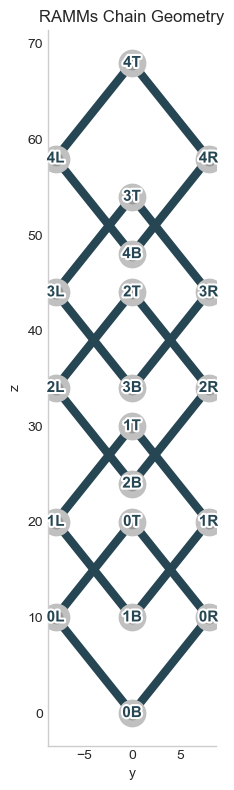

In [242]:
BASELINE_CONF = build_baseline_conf(SYMS, odd_step=10, even_step=14)
plot_geometry(BASELINE_CONF)

In [213]:
def print_baseline(conf):

    info = get_system_dimensions(conf)

    for unit in info["unit_ids"]:

        print(f"\nUnit {unit}")
        print("-" * 30)

        for label in ["B", "L", "R", "T"]:

            y_sym = next(
                sym for sym in conf
                if str(sym) == f"y{unit}{label}"
            )

            z_sym = next(
                sym for sym in conf
                if str(sym) == f"z{unit}{label}"
            )

            print(
                f"{label}: "
                f"[{conf[y_sym]:6.2f}, {conf[z_sym]:6.2f}]"
            )

In [214]:
print_baseline(BASELINE_CONF)


Unit 0
------------------------------
B: [  0.00,   0.00]
L: [ -8.00,  10.00]
R: [  8.00,  10.00]
T: [  0.00,  20.00]

Unit 1
------------------------------
B: [  0.00,   5.00]
L: [ -8.00,  15.00]
R: [  8.00,  15.00]
T: [  0.00,  25.00]

Unit 2
------------------------------
B: [  0.00,  10.00]
L: [ -8.00,  20.00]
R: [  8.00,  20.00]
T: [  0.00,  30.00]

Unit 3
------------------------------
B: [  0.00,  15.00]
L: [ -8.00,  25.00]
R: [  8.00,  25.00]
T: [  0.00,  35.00]

Unit 4
------------------------------
B: [  0.00,  20.00]
L: [ -8.00,  30.00]
R: [  8.00,  30.00]
T: [  0.00,  40.00]


In [215]:
# ------------------------------------------------------------
# Transformation Helpers
# ------------------------------------------------------------

def get_point_array(conf, yk, zk):
    """Return point as numpy array [y, z]."""
    return np.array([float(conf[yk]), float(conf[zk])], dtype=float)

def get_distance_points(P, Q):
    d = P - Q
    return float(d @ d)

In [216]:
# ------------------------------------------------------------
# Transformation (and theta/z recovery) functions
# ------------------------------------------------------------

def transform_chain_from_reference(conf_ref, motions):
    """
    Apply relative motions to every unit.

    Unit 0 remains fixed.

    motions = {
        1: {"theta": theta1, "z": z1},
        2: {"theta": theta2, "z": z2},
        ...
    }

    Each unit moves relative to the already-transformed unit below it.
    """

    out = dict(conf_ref)

    nodes_ref = get_nodes(conf_ref)

    n_units = get_system_dimensions(conf_ref)["n_units"]

    # current transformed geometry
    nodes_cur = get_nodes(out)

    for unit_id in range(1, n_units):

        theta_deg = motions.get(unit_id, {}).get("theta", 0.0)
        z_shift   = motions.get(unit_id, {}).get("z", 0.0)

        unit_key = str(unit_id)

        B_ref = nodes_ref[unit_key]["B"]
        L_ref = nodes_ref[unit_key]["L"]
        R_ref = nodes_ref[unit_key]["R"]
        T_ref = nodes_ref[unit_key]["T"]

        th = radians(-theta_deg)

        Rm = np.array([
            [cos(th), -sin(th)],
            [sin(th),  cos(th)]
        ])

        B_new = np.array([
            B_ref[0],
            B_ref[1] + z_shift
        ])

        def xform(P_ref):
            rel = P_ref - B_ref
            return B_new + Rm @ rel

        transformed = {
            "B": B_new,
            "L": xform(L_ref),
            "R": xform(R_ref),
            "T": xform(T_ref),
        }

        nodes_cur[unit_key] = transformed

        for label in ["B", "L", "R", "T"]:

            ysym = next(
                s for s in out.keys()
                if str(s) == f"y{unit_id}{label}"
            )

            zsym = next(
                s for s in out.keys()
                if str(s) == f"z{unit_id}{label}"
            )

            out[ysym] = transformed[label][0]
            out[zsym] = transformed[label][1]

    return out

# cell 15
# returns the angle of rotation used to go from v_ref to v_cur
def get_signed_theta_helper(v_ref, v_cur): # not used
    """
    Get signed angle from v_ref to v_cur in degrees.
    Positive = CCW, negative = CW (based on RHR + RAMMs legend)
    """
    cross = v_ref[0] * v_cur[1] - v_ref[1] * v_cur[0]
    dot = v_ref[0] * v_cur[0] + v_ref[1] * v_cur[1]
    return np.degrees(np.arctan2(cross, dot))


def get_theta_z(conf, conf_ref): # not used
    """
    Recover the user-facing (theta_deg, z) from a configuration
    generated by transform_top_unit_from_reference(...).

    Assumes your transform uses:
        th = radians(-theta_deg)

    so we flip the sign back before returninorient theta_deg.
    """
    nodes_ref = get_nodes(conf_ref)
    nodes_cur = get_nodes(conf)

    B_ref = nodes_ref["1"]["B"]
    T_ref = nodes_ref["1"]["T"]

    B_cur = nodes_cur["1"]["B"]
    T_cur = nodes_cur["1"]["T"]

    v_ref = T_ref - B_ref
    v_cur = T_cur - B_cur

    # standard math signed angle
    theta_math_deg = get_signed_theta_helper(v_ref, v_cur)

    # if your transform uses th = radians(-theta_deg),
    # then user-facing theta is the negative of the math angle
    theta_deg = -theta_math_deg

    z = float(B_cur[1] - B_ref[1])

    return float(theta_deg), z

In [217]:
# ------------------------------------------------------------
# Gap function helpers
# ------------------------------------------------------------
# more robust helpers to exclude invalid configurations
#
# describes rotation of seg(A->B)->P as a clockwise, counterclockwise, or neither
def orient(A, B, P):
    """
    Compute the signed 2D orientation (cross product) of three points.
    Return:
        Scalar indicating size and direction of rotation
    Geometric meaning:
        Measures the signed area of the parallelogram formed by vectors AB and AP,
        which is proportional to the signed area of triangle (A, B, P).

    Interpretation:
        > 0 : P lies to the left of the directed line A → B (counterclockwise turn)
        < 0 : P lies to the right of the directed line A → B (clockwise turn)
        ≈ 0 : P lies on the INFINITE line through AB (never returns exact 0, mathematically)

    Why this is useful:
        - Determines which side of a segment a point lies on
        - Provides a smooth signed quantity that can be used to build
          contact constraints and compute gradients

    Notes:
        The magnitude is proportional to area (not distance), but dividing
        by |AB| converts it into a signed distance from the line.
    """
    return (B[0] - A[0]) * (P[1] - A[1]) - (B[1] - A[1]) * (P[0] - A[0])

# tolerance is needed because orient will never return an exact zero
def point_on_segment_helper(A, B, P, tol=1e-9): # tol is one billion by default
    """
    Check whether a point P lies on the finite segment AB.

    This requires:
        1. P is collinear with A and B (via orient)
        2. P lies within the bounding box of A and B

    Used for:
        - exact geometric checks
        - handling edge cases (e.g., endpoint contact)
        - debugging contact conditions

    Note:
        This is a discrete geometric test, unlike projection-based
        checks used in smooth barrier functions.
    """
    if abs(orient(A, B, P)) > tol:
        return False

    return (
        #P’s x-coordinate is between A and B (allowing a tiny margin)
        #P’s y-coordinate is between A and B (allowing a tiny margin)
        min(A[0], B[0]) - tol <= P[0] <= max(A[0], B[0]) + tol and
        min(A[1], B[1]) - tol <= P[1] <= max(A[1], B[1]) + tol
    )


def point_on_segment_discrete_helper(P, A, B, tol=1e-9):
    """
    +1 : point safely off segment
     0 : point touching segment
    """
    return 0.0 if point_on_segment_helper(A, B, P, tol) else 1.0


def segments_intersect_helper(A, B, C, D, tol=1e-9):
    """
    Robust finite-segment intersection test.
    Returns True if segments AB and CD intersect or touch.
    """
    o1 = orient(A, B, C)
    o2 = orient(A, B, D)
    o3 = orient(C, D, A)
    o4 = orient(C, D, B)

    # proper intersection
    if ((o1 > tol and o2 < -tol) or (o1 < -tol and o2 > tol)) and \
       ((o3 > tol and o4 < -tol) or (o3 < -tol and o4 > tol)):
        return True

    # endpoint / collinear touching cases
    if abs(o1) <= tol and point_on_segment_helper(A, B, C, tol): return True
    if abs(o2) <= tol and point_on_segment_helper(A, B, D, tol): return True
    if abs(o3) <= tol and point_on_segment_helper(C, D, A, tol): return True
    if abs(o4) <= tol and point_on_segment_helper(C, D, B, tol): return True

    return False


# Tells you if P is violating, touching, or safely separated from segment AB 
# when that segment (AB) is actually the relevant contact surface.
def get_distance_point_segment(P, A, B, safe_sign=+1, outside_value=1e6):
    """
    Compute a signed, one-sided contact constraint between a point P and a segment AB.

    - Uses signed distance to determine which side of the segment P lies on
    - Activates only when P projects onto the segment interior
    - Otherwise returns a large value (inactive constraint)

    In short:
        side + distance + local relevance → contact gap

    Returns
    -------
    gap : float
        > 0 : safe (point is on the allowed side of the segment)
        = 0 : contact (point lies on the segment)
        < 0 : violated (point has crossed to the forbidden side)

    info : dict
        Debug info (projection parameter, orientation, etc.)

    main Idea
    ---------
    This acts as a *local barrier*:
        - Only active when the closest point on the infinite line lies
          within the segment (0 <= t <= 1)
        - Otherwise ignored (returns large positive value)

    safe_sign
    ---------
    Chosen so that a known VALID reference configuration yields gap > 0.
    This defines which side of the segment is "allowed".
    """

    # ------------------------------------------------------------------
    # Step 1: Define vectors
    # ------------------------------------------------------------------
    # AB: direction of the segment
    # AP: vector from segment start to point
    AB = B - A
    AP = P - A

    # Squared length of the segment
    denom = np.dot(AB, AB)

    # ------------------------------------------------------------------
    # Degenerate case: segment is collapsed (A == B)
    # ------------------------------------------------------------------
    # If the segment has zero length, we cannot define a meaningful barrier
    # → return a large positive value (i.e., "not active")
    if np.isclose(denom, 0.0):
        return outside_value, {
            "t_raw": 0.0,
            "projection_interior": False,
            "signed_line_distance": None,
            "orient": 0.0,
        }

    # ------------------------------------------------------------------
    # Step 2: Project P onto the infinite line through A->B
    # ------------------------------------------------------------------
    # t_raw tells us where the projection lies:
    #   t = 0   → at A
    #   t = 1   → at B
    #   0<t<1   → inside segment
    #   outside → projection is beyond endpoints
    t_raw = np.dot(AP, AB) / denom

    # Check whether projection lies within segment bounds
    projection_interior = (0.0 <= t_raw <= 1.0)

    # ------------------------------------------------------------------
    # Step 3: Compute signed distance from point to line
    # ------------------------------------------------------------------
    # orient(A, B, P):
    #   tells us which side of the segment P lies on 
    #       (calculates the signed area: 2D cross product)
    s = orient(A, B, P)
    # Normalize by |AB| to get something proportional to distance
    line_dist_signed = safe_sign * s / np.linalg.norm(AB)

    # ------------------------------------------------------------------
    # Step 4: Apply "local barrier" logic
    # ------------------------------------------------------------------
    # Only enforce the barrier if the projection lies inside the segment
    #
    # If projection is outside:
    # → this segment should NOT constrain this point
    # → return large positive value (inactive constraint)
    if projection_interior:
        gap = line_dist_signed
    else:
        gap = outside_value

    # ------------------------------------------------------------------
    # Debug info
    # ------------------------------------------------------------------
    info = {
        "t_raw": float(t_raw),                       # projection parameter
        "projection_interior": projection_interior,  # whether constraint is active
        "signed_line_distance": float(line_dist_signed),  # signed distance value
        "orient": float(s),                          # raw orientation value
    }

    return float(gap), info

# helper to get unit1 strut lengths
def get_reference_unit1_lengths_helper(conf_ref):
    """
    Use the reference configuration to define the rigid geometry of unit 1.
    """
    B = get_point_array(conf_ref, y1B, z1B)
    L = get_point_array(conf_ref, y1L, z1L)
    R = get_point_array(conf_ref, y1R, z1R)
    T = get_point_array(conf_ref, y1T, z1T)

    return {
        "BL2": get_distance_points(B, L),
        "BR2": get_distance_points(B, R),
        "LT2": get_distance_points(L, T),
        "RT2": get_distance_points(R, T),
        # diagonals for extra validation
        "BT2": get_distance_points(B, T),
        "LR2": get_distance_points(L, R),
    }

def get_reference_unit_lengths_helper(conf_ref, unit_id):
    """
    Use the reference configuration to define the rigid geometry
    of an arbitrary unit.

    Parameters
    ----------
    conf_ref : dict
        Reference configuration

    unit_id : int
        Unit index (0,1,2,...)

    Returns
    -------
    dict
        Squared strut lengths and diagonals.
    """

    nodes = get_nodes(conf_ref)

    unit = nodes[str(unit_id)]

    B = unit["B"]
    L = unit["L"]
    R = unit["R"]
    T = unit["T"]

    return {
        "BL2": get_distance_points(B, L),
        "BR2": get_distance_points(B, R),
        "LT2": get_distance_points(L, T),
        "RT2": get_distance_points(R, T),

        # diagonals for validation
        "BT2": get_distance_points(B, T),
        "LR2": get_distance_points(L, R),
    }

def get_all_reference_unit_lengths(conf_ref):

    n_units = get_system_dimensions(conf_ref)["n_units"]

    return {
        unit_id: get_reference_unit_lengths_helper(
            conf_ref,
            unit_id
        )
        for unit_id in range(n_units)
    }

## Gap Functions
**gap_functions** defines the full contact model, while **smooth_gap_functions** defines the subset of constraints that can be linearized for tangent-space jamming analysis.

In [218]:
# Define some global tolerances that will be used to calc test configs too
PIN_DIAMETER_CONTACT_TOL = 2.46  # mm (from CAD)
LEFT_RIGHT_CONTACT_TOL = 2.75 # 3.72 is the node distance between midponts, adjust this to be smaller to capture segment to node distance

Test point-segment only gap function

In [219]:
def print_segment_orientation_guide(conf_valid):
    """
    For each segment-to-point gap, determine the correct (A, B)
    ordering so that orient(A, B, P_valid) > 0.

    Prints the recommended segment direction for use in gap functions.
    """

    nodes = get_nodes(conf_valid)

    # Bottom unit
    P0B = nodes["0"]["B"]
    P0L = nodes["0"]["L"]
    P0R = nodes["0"]["R"]
    P0T = nodes["0"]["T"]

    # Top unit
    P1B = nodes["1"]["B"]
    P1L = nodes["1"]["L"]
    P1R = nodes["1"]["R"]
    P1T = nodes["1"]["T"]

    def check(name, A, B, P):
        val = orient(A, B, P)

        if val > 0:
            chosen = (A, B)
            direction = "A -> B"
        elif val < 0:
            chosen = (B, A)
            direction = "B -> A (FLIPPED)"
        else:
            print(f"{name:35s} | WARNING: collinear (orient ≈ 0)")
            return

        print(f"{name:35s} | orient = {val:+.6f} | use {direction}")

    print("\n=== SEGMENT ORIENTATION GUIDE ===\n")

    # ------------------------------------------------------------
    # Original (top node vs bottom segment)
    # ------------------------------------------------------------
    check("1L vs 0L-0T", P0L, P0T, P1L)
    check("1R vs 0R-0T", P0R, P0T, P1R)
    check("1B vs 0B-0L", P0B, P0L, P1B)
    check("1B vs 0B-0R", P0B, P0R, P1B)
    check("1B vs 0R-0T", P0R, P0T, P1B)
    check("1B vs 0L-0T", P0L, P0T, P1B)

    # ------------------------------------------------------------
    # Reciprocal (bottom node vs top segment)
    # ------------------------------------------------------------
    check("0T vs 1B-1R", P1B, P1R, P0T)
    check("0T vs 1B-1L", P1B, P1L, P0T)
    check("0T vs 1R-1T", P1R, P1T, P0T)
    check("0T vs 1L-1T", P1L, P1T, P0T)

    check("0B vs 1B-1R", P1B, P1R, P0B)
    check("0B vs 1B-1L", P1B, P1L, P0B)

    print("\n================================\n")

def print_segment_orientation_guide(conf_valid, bottom_unit):
    """
    For a neighboring pair of units:

        bottom_unit
        top_unit = bottom_unit + 1

    determine the correct segment orientation so that

        orient(A, B, P) > 0

    for each point-segment contact candidate.

    Prints the recommended segment direction for use
    in gap functions.
    """

    nodes = get_nodes(conf_valid)

    bottom_key = str(bottom_unit)
    top_key = str(bottom_unit + 1)

    if bottom_key not in nodes:
        raise ValueError(f"Unit {bottom_unit} not found")

    if top_key not in nodes:
        raise ValueError(
            f"Unit {bottom_unit + 1} not found "
            f"(no neighboring unit above)"
        )

    # ------------------------------------------------------------
    # Bottom unit
    # ------------------------------------------------------------

    PB = nodes[bottom_key]

    P0B = PB["B"]
    P0L = PB["L"]
    P0R = PB["R"]
    P0T = PB["T"]

    # ------------------------------------------------------------
    # Top unit
    # ------------------------------------------------------------

    PT = nodes[top_key]

    P1B = PT["B"]
    P1L = PT["L"]
    P1R = PT["R"]
    P1T = PT["T"]

    # ------------------------------------------------------------
    # Helper
    # ------------------------------------------------------------

    def check(name, A, B, P):

        val = orient(A, B, P)

        if val > 0:
            direction = "A -> B"

        elif val < 0:
            direction = "B -> A (FLIPPED)"

        else:
            print(
                f"{name:35s} | "
                f"WARNING: collinear (orient ≈ 0)"
            )
            return

        print(
            f"{name:35s} | "
            f"orient = {val:+.6f} | "
            f"use {direction}"
        )

    print("\n=== SEGMENT ORIENTATION GUIDE ===\n")
    print(
        f"Bottom unit = {bottom_unit}, "
        f"Top unit = {bottom_unit + 1}\n"
    )

    # ------------------------------------------------------------
    # Original
    # top node vs bottom segment
    # ------------------------------------------------------------

    check(
        f"{bottom_unit+1}L vs {bottom_unit}L-{bottom_unit}T",
        P0L, P0T, P1L
    )

    check(
        f"{bottom_unit+1}R vs {bottom_unit}R-{bottom_unit}T",
        P0R, P0T, P1R
    )

    check(
        f"{bottom_unit+1}B vs {bottom_unit}B-{bottom_unit}L",
        P0B, P0L, P1B
    )

    check(
        f"{bottom_unit+1}B vs {bottom_unit}B-{bottom_unit}R",
        P0B, P0R, P1B
    )

    check(
        f"{bottom_unit+1}B vs {bottom_unit}R-{bottom_unit}T",
        P0R, P0T, P1B
    )

    check(
        f"{bottom_unit+1}B vs {bottom_unit}L-{bottom_unit}T",
        P0L, P0T, P1B
    )

    # ------------------------------------------------------------
    # Reciprocal
    # bottom node vs top segment
    # ------------------------------------------------------------

    check(
        f"{bottom_unit}T vs {bottom_unit+1}B-{bottom_unit+1}R",
        P1B, P1R, P0T
    )

    check(
        f"{bottom_unit}T vs {bottom_unit+1}B-{bottom_unit+1}L",
        P1B, P1L, P0T
    )

    check(
        f"{bottom_unit}T vs {bottom_unit+1}R-{bottom_unit+1}T",
        P1R, P1T, P0T
    )

    check(
        f"{bottom_unit}T vs {bottom_unit+1}L-{bottom_unit+1}T",
        P1L, P1T, P0T
    )

    check(
        f"{bottom_unit}B vs {bottom_unit+1}B-{bottom_unit+1}R",
        P1B, P1R, P0B
    )

    check(
        f"{bottom_unit}B vs {bottom_unit+1}B-{bottom_unit+1}L",
        P1B, P1L, P0B
    )

    print("\n================================\n")

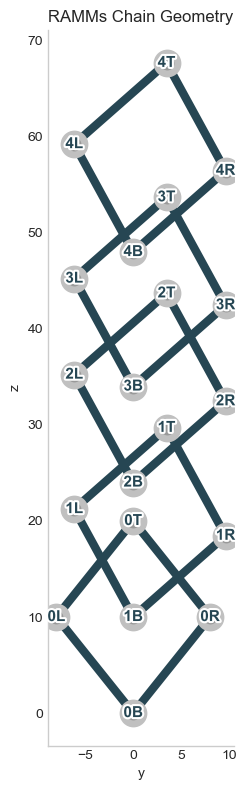

In [244]:
VALID_CONF = transform_chain_from_reference(
    BASELINE_CONF,
    motions={
        1: {"theta": 10.0, "z": 0},
        2: {"theta": 10.0, "z": 0},
        3: {"theta": 10.0, "z": 0},
        4: {"theta": 10.0, "z": 0},
    }
)
plot_geometry(VALID_CONF)

In [ ]:
n_units = get_system_dimensions(VALID_CONF)["n_units"]

for bottom_unit in range(n_units - 1):
    print_segment_orientation_guide(
        VALID_CONF,
        bottom_unit
    )


=== SEGMENT ORIENTATION GUIDE ===

Bottom unit = 0, Top unit = 1

1L vs 0L-0T                         | orient = +31.317906 | use A -> B
1R vs 0R-0T                         | orient = -43.820575 | use B -> A (FLIPPED)
1B vs 0B-0L                         | orient = -40.000000 | use B -> A (FLIPPED)
1B vs 0B-0R                         | orient = +40.000000 | use A -> B
1B vs 0R-0T                         | orient = +120.000000 | use A -> B
1B vs 0L-0T                         | orient = -120.000000 | use B -> A (FLIPPED)
0T vs 1B-1R                         | orient = +144.224157 | use A -> B
0T vs 1B-1L                         | orient = -92.129704 | use B -> A (FLIPPED)
0T vs 1R-1T                         | orient = +67.870296 | use A -> B
0T vs 1L-1T                         | orient = -15.775843 | use B -> A (FLIPPED)
0B vs 1B-1R                         | orient = -48.074719 | use B -> A (FLIPPED)
0B vs 1B-1L                         | orient = +30.709901 | use A -> B



=== SEGMENT ORI

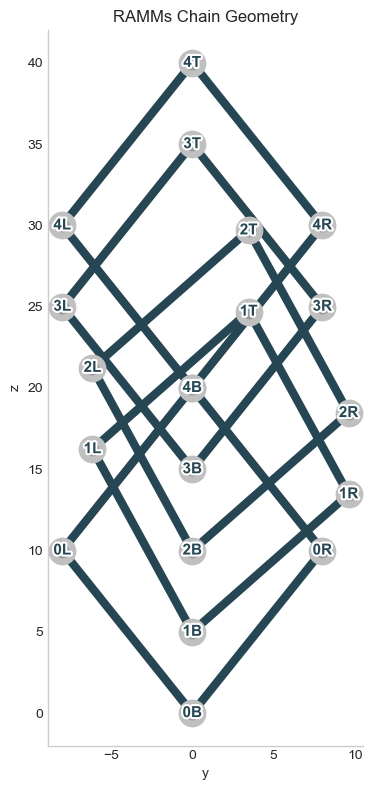

In [224]:
plot_geometry(VALID_CONF)

In [158]:
# don't need this if you write invalid geometry filter and call that 
# before looking for active gaps
def safe_sign_from_reference(P_ref, A_ref, B_ref, tol=1e-12):
    """
    Choose safe_sign so the reference configuration is on the allowed side.
    """
    s = orient(A_ref, B_ref, P_ref)

    if abs(s) < tol:
        raise ValueError(
            "Reference point is nearly on the segment line, so safe_sign is ambiguous. "
            "Set safe_sign manually for this gap."
        )

    return +1 if s > 0 else -1

def point_above_segment_by_y(P, A, B, offset=0.0):
    """
    Returns True if point P is above segment A-B at P's y-location.

    Assumes:
        point = [y, z]
    """

    yP, zP = P
    yA, zA = A
    yB, zB = B

    if abs(yB - yA) < 1e-12:
        z_seg = max(zA, zB)
        return zP > z_seg + offset

    t = (yP - yA) / (yB - yA)

    if t < 0.0 or t > 1.0:
        return False

    z_seg = zA + t * (zB - zA)

    return zP > z_seg + offset

def point_below_segment_by_y(P, A, B, offset=0.0):
    """
    Returns True if point P is below segment A-B at P's y-location.

    Assumes:
        point = [y, z]
    """

    yP, zP = P
    yA, zA = A
    yB, zB = B

    # If segment is nearly vertical in y, fall back to min z comparison
    if abs(yB - yA) < 1e-12:
        z_seg = min(zA, zB)
        return zP < z_seg - offset

    # Interpolate z on segment at y = yP
    t = (yP - yA) / (yB - yA)

    # Only apply this check when P is horizontally over the segment
    if t < 0.0 or t > 1.0:
        return False

    z_seg = zA + t * (zB - zA)

    return zP < z_seg - offset


In [159]:
def build_gap_info(bottom_unit):

    top_unit = bottom_unit + 1

    return {

        # =====================================================
        # LOWER UNIT NODES vs UPPER UNIT SEGMENTS
        # =====================================================

        f"node_{bottom_unit}B_vs_seg_{top_unit}B_{top_unit}L": {
            "short":
                f"{bottom_unit}B vs ({top_unit}B-{top_unit}L)",
            "category":
                "segment_barrier",
            "description":
                f"Bottom node of unit {bottom_unit} "
                f"against lower-left edge of unit {top_unit}",
        },

        f"node_{bottom_unit}B_vs_seg_{top_unit}B_{top_unit}R": {
            "short":
                f"{bottom_unit}B vs ({top_unit}B-{top_unit}R)",
            "category":
                "segment_barrier",
            "description":
                f"Bottom node of unit {bottom_unit} "
                f"against lower-right edge of unit {top_unit}",
        },

        f"node_{bottom_unit}L_vs_seg_{top_unit}B_{top_unit}L": {
            "short":
                f"{bottom_unit}L vs ({top_unit}B-{top_unit}L)",
            "category":
                "segment_barrier",
            "description":
                f"Left node of unit {bottom_unit} "
                f"against lower-left edge of unit {top_unit}",
        },

        f"node_{bottom_unit}R_vs_seg_{top_unit}B_{top_unit}R": {
            "short":
                f"{bottom_unit}R vs ({top_unit}B-{top_unit}R)",
            "category":
                "segment_barrier",
            "description":
                f"Right node of unit {bottom_unit} "
                f"against lower-right edge of unit {top_unit}",
        },

        f"node_{bottom_unit}T_vs_seg_{top_unit}B_{top_unit}L": {
            "short":
                f"{bottom_unit}T vs ({top_unit}B-{top_unit}L)",
            "category":
                "segment_barrier",
            "description":
                f"Top node of unit {bottom_unit} "
                f"against lower-left edge of unit {top_unit}",
        },

        f"node_{bottom_unit}T_vs_seg_{top_unit}B_{top_unit}R": {
            "short":
                f"{bottom_unit}T vs ({top_unit}B-{top_unit}R)",
            "category":
                "segment_barrier",
            "description":
                f"Top node of unit {bottom_unit} "
                f"against lower-right edge of unit {top_unit}",
        },

        f"node_{bottom_unit}T_vs_seg_{top_unit}L_{top_unit}T": {
            "short":
                f"{bottom_unit}T vs ({top_unit}L-{top_unit}T)",
            "category":
                "segment_barrier",
            "description":
                f"Top node of unit {bottom_unit} "
                f"against upper-left edge of unit {top_unit}",
        },

        f"node_{bottom_unit}T_vs_seg_{top_unit}R_{top_unit}T": {
            "short":
                f"{bottom_unit}T vs ({top_unit}R-{top_unit}T)",
            "category":
                "segment_barrier",
            "description":
                f"Top node of unit {bottom_unit} "
                f"against upper-right edge of unit {top_unit}",
        },

        # =====================================================
        # UPPER NODES vs LOWER SEGMENTS
        # =====================================================

        f"node_{top_unit}B_vs_seg_{bottom_unit}B_{bottom_unit}L": {
            "short":
                f"{top_unit}B vs ({bottom_unit}B-{bottom_unit}L)",
            "category":
                "segment_barrier",
            "description":
                f"Bottom node of unit {top_unit} "
                f"against lower-left edge of unit {bottom_unit}",
        },

        f"node_{top_unit}B_vs_seg_{bottom_unit}B_{bottom_unit}R": {
            "short":
                f"{top_unit}B vs ({bottom_unit}B-{bottom_unit}R)",
            "category":
                "segment_barrier",
            "description":
                f"Bottom node of unit {top_unit} "
                f"against lower-right edge of unit {bottom_unit}",
        },

        f"node_{top_unit}B_vs_seg_{bottom_unit}L_{bottom_unit}T": {
            "short":
                f"{top_unit}B vs ({bottom_unit}L-{bottom_unit}T)",
            "category":
                "segment_barrier",
            "description":
                f"Bottom node of unit {top_unit} "
                f"against upper-left edge of unit {bottom_unit}",
        },

        f"node_{top_unit}B_vs_seg_{bottom_unit}R_{bottom_unit}T": {
            "short":
                f"{top_unit}B vs ({bottom_unit}R-{bottom_unit}T)",
            "category":
                "segment_barrier",
            "description":
                f"Bottom node of unit {top_unit} "
                f"against upper-right edge of unit {bottom_unit}",
        },

        f"node_{top_unit}L_vs_seg_{bottom_unit}L_{bottom_unit}T": {
            "short":
                f"{top_unit}L vs ({bottom_unit}L-{bottom_unit}T)",
            "category":
                "segment_barrier",
            "description":
                f"Left node of unit {top_unit} "
                f"against upper-left edge of unit {bottom_unit}",
        },

        f"node_{top_unit}R_vs_seg_{bottom_unit}R_{bottom_unit}T": {
            "short":
                f"{top_unit}R vs ({bottom_unit}R-{bottom_unit}T)",
            "category":
                "segment_barrier",
            "description":
                f"Right node of unit {top_unit} "
                f"against upper-right edge of unit {bottom_unit}",
        },
    }

def build_chain_gap_info(conf):

    n_units = get_system_dimensions(conf)["n_units"]

    gap_info = {}

    for bottom_unit in range(n_units - 1):
        gap_info.update(
            build_gap_info(bottom_unit)
        )

    return gap_info

def print_all_gaps(conf):

    gap_info = build_chain_gap_info(conf)

    print("=" * 100)

    for k, v in gap_info.items():
        print(f"{k:45s} --> {v['short']}")

    print("=" * 100)

def describe_gap(conf, gap_name):

    gap_info = build_chain_gap_info(conf)

    info = gap_info.get(gap_name, None)

    if info is None:
        print("Gap not found.")
        return

    print("\n" + "=" * 80)

    print("name:       ", gap_name)
    print("short:      ", info["short"])
    print("category:   ", info["category"])
    print("description:", info["description"])

    print("=" * 80 + "\n")

In [160]:
print_all_gaps(BASELINE_CONF)

describe_gap(BASELINE_CONF,"node_0R_vs_seg_1B_1R")

node_0B_vs_seg_1B_1L                          --> 0B vs (1B-1L)
node_0B_vs_seg_1B_1R                          --> 0B vs (1B-1R)
node_0L_vs_seg_1B_1L                          --> 0L vs (1B-1L)
node_0R_vs_seg_1B_1R                          --> 0R vs (1B-1R)
node_0T_vs_seg_1B_1L                          --> 0T vs (1B-1L)
node_0T_vs_seg_1B_1R                          --> 0T vs (1B-1R)
node_0T_vs_seg_1L_1T                          --> 0T vs (1L-1T)
node_0T_vs_seg_1R_1T                          --> 0T vs (1R-1T)
node_1B_vs_seg_0B_0L                          --> 1B vs (0B-0L)
node_1B_vs_seg_0B_0R                          --> 1B vs (0B-0R)
node_1B_vs_seg_0L_0T                          --> 1B vs (0L-0T)
node_1B_vs_seg_0R_0T                          --> 1B vs (0R-0T)
node_1L_vs_seg_0L_0T                          --> 1L vs (0L-0T)
node_1R_vs_seg_0R_0T                          --> 1R vs (0R-0T)
node_1B_vs_seg_2B_2L                          --> 1B vs (2B-2L)
node_1B_vs_seg_2B_2R                    

In [161]:
def get_oriented_segment(A, B, A_baseline, B_baseline, P_baseline):

    if orient(A_baseline, B_baseline, P_baseline) > 0:
        return A, B
    else:
        return B, A

In [162]:
PAIR_POINT_SEGMENT_CONTACTS = [

    # ============================================================
    # top_B vs bottom unit
    # ============================================================

    {
        "name": "node_{top}B_vs_seg_{bottom}B_{bottom}L",
        "point": "top_B",
        "segment": ("bottom_B", "bottom_L"),
        "baseline_point": "baseline_top_B",
        "baseline_segment": (
            "baseline_bottom_B",
            "baseline_bottom_L"
        ),
        "sign_rule": "valid_node_above_node",
        "reference_node": "bottom_B",
    },

    {
        "name": "node_{top}B_vs_seg_{bottom}B_{bottom}R",
        "point": "top_B",
        "segment": ("bottom_B", "bottom_R"),
        "baseline_point": "baseline_top_B",
        "baseline_segment": (
            "baseline_bottom_B",
            "baseline_bottom_R"
        ),
        "sign_rule": "valid_node_above_node",
        "reference_node": "bottom_B",
    },

    {
        "name": "node_{top}B_vs_seg_{bottom}L_{bottom}T",
        "point": "top_B",
        "segment": ("bottom_L", "bottom_T"),
        "baseline_point": "baseline_top_B",
        "baseline_segment": (
            "baseline_bottom_L",
            "baseline_bottom_T"
        ),
        "sign_rule": "valid_node_below_node",
        "reference_node": "bottom_T",
    },

    {
        "name": "node_{top}B_vs_seg_{bottom}R_{bottom}T",
        "point": "top_B",
        "segment": ("bottom_R", "bottom_T"),
        "baseline_point": "baseline_top_B",
        "baseline_segment": (
            "baseline_bottom_R",
            "baseline_bottom_T"
        ),
        "sign_rule": "valid_node_below_node",
        "reference_node": "bottom_T",
    },

    # ============================================================
    # bottom_T vs top unit
    # ============================================================

    {
        "name": "node_{bottom}T_vs_seg_{top}B_{top}L",
        "point": "bottom_T",
        "segment": ("top_B", "top_L"),
        "baseline_point": "baseline_bottom_T",
        "baseline_segment": (
            "baseline_top_B",
            "baseline_top_L"
        ),
        "sign_rule": "valid_node_right_of_node",
        "reference_node": "top_L",
    },

    {
        "name": "node_{bottom}T_vs_seg_{top}B_{top}R",
        "point": "bottom_T",
        "segment": ("top_B", "top_R"),
        "baseline_point": "baseline_bottom_T",
        "baseline_segment": (
            "baseline_top_B",
            "baseline_top_R"
        ),
        "sign_rule": "valid_node_left_of_node",
        "reference_node": "top_R",
    },

    {
        "name": "node_{bottom}T_vs_seg_{top}L_{top}T",
        "point": "bottom_T",
        "segment": ("top_L", "top_T"),
        "baseline_point": "baseline_bottom_T",
        "baseline_segment": (
            "baseline_top_L",
            "baseline_top_T"
        ),
        "sign_rule": "valid_node_below_node",
        "reference_node": "top_T",
    },

    {
        "name": "node_{bottom}T_vs_seg_{top}R_{top}T",
        "point": "bottom_T",
        "segment": ("top_R", "top_T"),
        "baseline_point": "baseline_bottom_T",
        "baseline_segment": (
            "baseline_top_R",
            "baseline_top_T"
        ),
        "sign_rule": "valid_node_below_node",
        "reference_node": "top_T",
    },

]

In [163]:
PAIR_SEGMENT_SEGMENT_CONTACTS = [

    {
        "name":
            "seg_{bottom}L_{bottom}T_vs_seg_{top}B_{top}R",

        "segment_A":
            ("bottom_L", "bottom_T"),

        "segment_B":
            ("top_B", "top_R"),
    },

    {
        "name":
            "seg_{bottom}R_{bottom}T_vs_seg_{top}B_{top}L",

        "segment_A":
            ("bottom_R", "bottom_T"),

        "segment_B":
            ("top_B", "top_L"),
    },

]

In [164]:
def get_pair_point_segment_gaps(
    conf,
    baseline_conf,
    bottom_unit,
    contact_offset=1.0
):
    """
    Compute all point-segment gaps between

        bottom_unit
        top_unit = bottom_unit + 1

    Returns
    -------
    gaps : dict
    """

    top_unit = bottom_unit + 1

    nodes = get_nodes(conf)
    baseline_nodes = get_nodes(baseline_conf)

    bottom = nodes[str(bottom_unit)]
    top = nodes[str(top_unit)]

    baseline_bottom = baseline_nodes[str(bottom_unit)]
    baseline_top = baseline_nodes[str(top_unit)]

    # ============================================================
    # Current geometry
    # ============================================================

    bottom_B = bottom["B"]
    bottom_L = bottom["L"]
    bottom_R = bottom["R"]
    bottom_T = bottom["T"]

    top_B = top["B"]
    top_L = top["L"]
    top_R = top["R"]
    top_T = top["T"]

    # ============================================================
    # Baseline geometry
    # ============================================================

    baseline_bottom_B = baseline_bottom["B"]
    baseline_bottom_L = baseline_bottom["L"]
    baseline_bottom_R = baseline_bottom["R"]
    baseline_bottom_T = baseline_bottom["T"]

    baseline_top_B = baseline_top["B"]
    baseline_top_L = baseline_top["L"]
    baseline_top_R = baseline_top["R"]
    baseline_top_T = baseline_top["T"]

    # ============================================================
    # Lookup table
    # ============================================================

    lookup = {

        "bottom_B": bottom_B,
        "bottom_L": bottom_L,
        "bottom_R": bottom_R,
        "bottom_T": bottom_T,

        "top_B": top_B,
        "top_L": top_L,
        "top_R": top_R,
        "top_T": top_T,

        "baseline_bottom_B": baseline_bottom_B,
        "baseline_bottom_L": baseline_bottom_L,
        "baseline_bottom_R": baseline_bottom_R,
        "baseline_bottom_T": baseline_bottom_T,

        "baseline_top_B": baseline_top_B,
        "baseline_top_L": baseline_top_L,
        "baseline_top_R": baseline_top_R,
        "baseline_top_T": baseline_top_T,
    }

    gaps = {}

    # ============================================================
    # Loop through contact definitions
    # ============================================================

    for contact in PAIR_POINT_SEGMENT_CONTACTS:

        P = lookup[contact["point"]]

        A = lookup[contact["segment"][0]]
        B = lookup[contact["segment"][1]]

        A_base = lookup[
            contact["baseline_segment"][0]
        ]

        B_base = lookup[
            contact["baseline_segment"][1]
        ]

        P_base = lookup[
            contact["baseline_point"]
        ]

        A, B = get_oriented_segment(
            A,
            B,
            A_base,
            B_base,
            P_base
        )

        g, _ = get_distance_point_segment(
            P,
            A,
            B
        )

        gap = float(g - contact_offset)

        # --------------------------------------------------------
        # Apply sign convention
        # --------------------------------------------------------

        rule = contact["sign_rule"]

        # ========================================================
        # Node vs Segment
        # ========================================================

        if rule == "valid_node_below_segment":

            if point_above_segment_by_y(
                P,
                A,
                B,
                offset=contact_offset
            ):
                gap = -abs(gap)

        elif rule == "valid_node_above_segment":

            if point_below_segment_by_y(
                P,
                A,
                B,
                offset=contact_offset
            ):
                gap = -abs(gap)

        # ========================================================
        # Node vs Node
        # ========================================================

        elif rule == "valid_node_above_node":

            ref_node = lookup[
                contact["reference_node"]
            ]

            if P[1] < ref_node[1]:
                gap = -abs(gap)

        elif rule == "valid_node_below_node":

            ref_node = lookup[
                contact["reference_node"]
            ]

            if P[1] > ref_node[1]:
                gap = -abs(gap)

        elif rule == "valid_node_left_of_node":

            ref_node = lookup[
                contact["reference_node"]
            ]

            if P[0] > ref_node[0]:
                gap = -abs(gap)

        elif rule == "valid_node_right_of_node":

            ref_node = lookup[
                contact["reference_node"]
            ]

            if P[0] < ref_node[0]:
                gap = -abs(gap)

        else:

            raise ValueError(
                f"Unknown sign rule: {rule}"
            )

        gap_name = contact["name"].format(
            bottom=bottom_unit,
            top=top_unit
        )

        gaps[gap_name] = gap

    return gaps

In [165]:
n_units = get_system_dimensions(BASELINE_CONF)["n_units"]

motions = {
    unit: {"theta": 10.0, "z": 0.0}
    for unit in range(1, n_units)
}

VALID_CONF = transform_chain_from_reference(
    BASELINE_CONF,
    motions
)

In [166]:
pair_gaps = get_pair_point_segment_gaps(
    conf=VALID_CONF,
    baseline_conf=BASELINE_CONF,
    bottom_unit=0,
    contact_offset=1.0
)

print(pair_gaps)

{'node_1B_vs_seg_0B_0L': 5.246950475544243, 'node_1B_vs_seg_0B_0R': 5.246950475544243, 'node_1B_vs_seg_0L_0T': 5.246950475544243, 'node_1B_vs_seg_0R_0T': 5.246950475544243, 'node_0T_vs_seg_1B_1L': 3.796080803431993, 'node_0T_vs_seg_1B_1R': 6.508009718566548, 'node_0T_vs_seg_1L_1T': 3.985891232521938, 'node_0T_vs_seg_1R_1T': 6.6978201476564925}


In [167]:
pair_gaps = get_pair_point_segment_gaps(
    conf=VALID_CONF,
    baseline_conf=BASELINE_CONF,
    bottom_unit=1,
    contact_offset=1.0
)

print(pair_gaps)

{'node_2B_vs_seg_1B_1L': 3.796080803431993, 'node_2B_vs_seg_1B_1R': 6.508009718566548, 'node_2B_vs_seg_1L_1T': 3.985891232521938, 'node_2B_vs_seg_1R_1T': 6.6978201476564925, 'node_1T_vs_seg_2B_2L': 6.6978201476564925, 'node_1T_vs_seg_2B_2R': 3.985891232521938, 'node_1T_vs_seg_2L_2T': 6.508009718566548, 'node_1T_vs_seg_2R_2T': 3.796080803431993}


In [168]:
pair_gaps = get_pair_point_segment_gaps(
    conf=VALID_CONF,
    baseline_conf=BASELINE_CONF,
    bottom_unit=2,
    contact_offset=1.0
)

print(pair_gaps)

{'node_3B_vs_seg_2B_2L': 3.796080803431993, 'node_3B_vs_seg_2B_2R': 6.508009718566548, 'node_3B_vs_seg_2L_2T': 3.985891232521938, 'node_3B_vs_seg_2R_2T': 6.6978201476564925, 'node_2T_vs_seg_3B_3L': 6.6978201476564925, 'node_2T_vs_seg_3B_3R': 3.985891232521938, 'node_2T_vs_seg_3L_3T': 6.508009718566548, 'node_2T_vs_seg_3R_3T': 3.796080803431993}


In [169]:
pair_gaps = get_pair_point_segment_gaps(
    conf=VALID_CONF,
    baseline_conf=BASELINE_CONF,
    bottom_unit=3,
    contact_offset=1.0
)

print(pair_gaps)

{'node_4B_vs_seg_3B_3L': 3.796080803431993, 'node_4B_vs_seg_3B_3R': 6.508009718566548, 'node_4B_vs_seg_3L_3T': 3.985891232521938, 'node_4B_vs_seg_3R_3T': 6.6978201476564925, 'node_3T_vs_seg_4B_4L': 6.6978201476564925, 'node_3T_vs_seg_4B_4R': 3.985891232521938, 'node_3T_vs_seg_4L_4T': 6.508009718566548, 'node_3T_vs_seg_4R_4T': 3.796080803431993}


In [170]:
# pariwise point-segment gaps
def get_chain_point_segment_gaps(
    conf,
    baseline_conf,
    contact_offset=1.0
):
    """
    Compute all point-segment gaps for all
    neighboring even/odd unit pairs.

        0 ↔ 1
        2 ↔ 3
        4 ↔ 5
        ...

    Returns
    -------
    gaps : dict
    """

    gaps = {}

    n_units = get_system_dimensions(conf)["n_units"]

    for bottom_unit in range(0, n_units - 1, 2):

        pair_gaps = get_pair_point_segment_gaps(
            conf=conf,
            baseline_conf=baseline_conf,
            bottom_unit=bottom_unit,
            contact_offset=contact_offset
        )

        gaps.update(pair_gaps)

    return gaps

In [171]:
nodes = get_nodes(VALID_CONF)

segA = (
    nodes["0"]["L"],
    nodes["0"]["T"]
)

segB = (
    nodes["2"]["B"],
    nodes["2"]["R"]
)

A1, A2 = segA
B1, B2 = segB

print(get_distance_point_segment(A1, B1, B2))
print(get_distance_point_segment(A2, B1, B2))
print(get_distance_point_segment(B1, A1, A2))
print(get_distance_point_segment(B2, A1, A2))

(1000000.0, {'t_raw': -0.9848077530122082, 'projection_interior': False, 'signed_line_distance': -2.2237817104103357, 'orient': -28.47830113737659})
(0.0, {'t_raw': 0.0, 'projection_interior': True, 'signed_line_distance': 0.0, 'orient': 0.0})
(0.0, {'t_raw': 1.0, 'projection_interior': True, 'signed_line_distance': 0.0, 'orient': 0.0})
(1000000.0, {'t_raw': 1.984807753012208, 'projection_interior': False, 'signed_line_distance': -2.2237817104103343, 'orient': -28.478301137376576})


In [172]:
def segments_intersect(
    A1,
    A2,
    B1,
    B2,
    tol=1e-12
):
    """
    Returns True if finite segments
    A1-A2 and B1-B2 intersect.
    """

    o1 = orient(A1, A2, B1)
    o2 = orient(A1, A2, B2)

    o3 = orient(B1, B2, A1)
    o4 = orient(B1, B2, A2)

    return (
        (o1 * o2 <= tol)
        and
        (o3 * o4 <= tol)
    )

In [173]:
def get_true_point_segment_distance(
    P,
    A,
    B
):
    """
    Euclidean distance from point P
    to finite segment A-B.
    """

    AB = B - A
    AP = P - A

    denom = np.dot(AB, AB)

    # degenerate segment
    if denom < 1e-12:
        return np.linalg.norm(P - A)

    t = np.dot(AP, AB) / denom

    # clamp to segment
    t = np.clip(t, 0.0, 1.0)

    closest = A + t * AB

    return np.linalg.norm(P - closest)

In [174]:
def get_segment_segment_distance(
    segA,
    segB
):
    """
    True Euclidean distance between two finite
    line segments in 2D.

    segA = (A1, A2)
    segB = (B1, B2)
    """

    A1, A2 = segA
    B1, B2 = segB

    # --------------------------------------------------------
    # Check for intersection
    # --------------------------------------------------------

    if segments_intersect(
        A1,
        A2,
        B1,
        B2
    ):
        return 0.0

    # --------------------------------------------------------
    # Endpoint -> opposite segment distances
    # --------------------------------------------------------

    d1 = get_true_point_segment_distance(
        A1,
        B1,
        B2
    )

    d2 = get_true_point_segment_distance(
        A2,
        B1,
        B2
    )

    d3 = get_true_point_segment_distance(
        B1,
        A1,
        A2
    )

    d4 = get_true_point_segment_distance(
        B2,
        A1,
        A2
    )

    return min(
        d1,
        d2,
        d3,
        d4
    )

In [175]:
def get_segment_segment_gap(
    segA,
    segB,
    contact_offset=1.0
):

    d = get_segment_segment_distance(
        segA,
        segB
    )

    return d - contact_offset

In [176]:
segA = (
    np.array([0.0, 0.0]),
    np.array([1.0, 0.0])
)

segB = (
    np.array([0.0, 5.0]),
    np.array([1.0, 5.0])
)

print(get_segment_segment_distance(segA, segB))

5.0


In [177]:
segA = (
    np.array([0.0, 0.0]),
    np.array([1.0, 0.0])
)

segB = (
    np.array([1.0, 0.0]),
    np.array([2.0, 0.0])
)

print(get_segment_segment_distance(segA, segB))

0.0


In [178]:
segA = (
    np.array([0.0, 0.0]),
    np.array([2.0, 2.0])
)

segB = (
    np.array([0.0, 2.0]),
    np.array([2.0, 0.0])
)

print(get_segment_segment_distance(segA, segB))

0.0


In [179]:
def get_pair_segment_segment_gaps(
    conf,
    bottom_even_unit,
    contact_offset=1.0
):
    """
    Compute segment-segment gaps between

        bottom_even_unit
        top_even_unit = bottom_even_unit + 2

    Returns
    -------
    gaps : dict
    """

    top_even_unit = bottom_even_unit + 2

    nodes = get_nodes(conf)

    bottom = nodes[str(bottom_even_unit)]
    top = nodes[str(top_even_unit)]

    # ============================================================
    # Lookup table
    # ============================================================

    lookup = {

        "bottom_B": bottom["B"],
        "bottom_L": bottom["L"],
        "bottom_R": bottom["R"],
        "bottom_T": bottom["T"],

        "top_B": top["B"],
        "top_L": top["L"],
        "top_R": top["R"],
        "top_T": top["T"],
    }

    gaps = {}

    # ============================================================
    # Loop through contact definitions
    # ============================================================

    for contact in PAIR_SEGMENT_SEGMENT_CONTACTS:

        segA = (
            lookup[contact["segment_A"][0]],
            lookup[contact["segment_A"][1]],
        )

        segB = (
            lookup[contact["segment_B"][0]],
            lookup[contact["segment_B"][1]],
        )

        gap = get_segment_segment_gap(
            segA,
            segB,
            contact_offset
        )

        gap_name = contact["name"].format(
            bottom=bottom_even_unit,
            top=top_even_unit
        )

        gaps[gap_name] = gap

    return gaps

In [180]:
pair_gaps = get_pair_segment_segment_gaps(
    conf=VALID_CONF,
    bottom_even_unit=0,
    contact_offset=1.0
)

for k, v in pair_gaps.items():
    print(k, v)

seg_0L_0T_vs_seg_2B_2R -1.0
seg_0R_0T_vs_seg_2B_2L -1.0


In [181]:
nodes = get_nodes(VALID_CONF)

segA = (
    nodes["0"]["L"],
    nodes["0"]["T"]
)

segB = (
    nodes["2"]["B"],
    nodes["2"]["R"]
)

print("segA =", segA)
print("segB =", segB)

print(
    "intersect =",
    segments_intersect(
        segA[0],
        segA[1],
        segB[0],
        segB[1]
    )
)

print(
    "distance =",
    get_segment_segment_distance(
        segA,
        segB
    )
)

segA = (array([-8., 10.]), array([ 0., 20.]))
segB = (array([ 0., 20.]), array([ 9.6149438 , 28.45889211]))
intersect = True
distance = 0.0


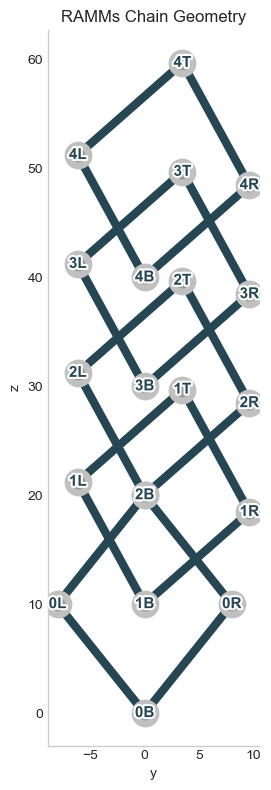


Unit 0
------------------------------
B: [  0.00,   0.00]
L: [ -8.00,  10.00]
R: [  8.00,  10.00]
T: [  0.00,  20.00]

Unit 1
------------------------------
B: [  0.00,  10.00]
L: [ -6.14,  21.24]
R: [  9.61,  18.46]
T: [  3.47,  29.70]

Unit 2
------------------------------
B: [  0.00,  20.00]
L: [ -6.14,  31.24]
R: [  9.61,  28.46]
T: [  3.47,  39.70]

Unit 3
------------------------------
B: [  0.00,  30.00]
L: [ -6.14,  41.24]
R: [  9.61,  38.46]
T: [  3.47,  49.70]

Unit 4
------------------------------
B: [  0.00,  40.00]
L: [ -6.14,  51.24]
R: [  9.61,  48.46]
T: [  3.47,  59.70]


In [182]:
plot_geometry(VALID_CONF)
print_baseline(VALID_CONF)

In [183]:
pair_gaps = get_pair_segment_segment_gaps(
    conf=VALID_CONF,
    bottom_even_unit=2,
    contact_offset=1.0
)

print(pair_gaps)

{'seg_2L_2T_vs_seg_4B_4R': 1.5221184860446089, 'seg_2R_2T_vs_seg_4B_4L': 2.4862297099063264}


In [110]:
def get_even_even_segment_gaps(
    conf,
    conf_ref=None,
    contact_offset=1.0
):
    """
    Compute segment-segment gaps for

        0 ↔ 2
        2 ↔ 4
        4 ↔ 6
        ...

    Returns
    -------
    gaps : dict
    """

    gaps = {}

    nodes = get_nodes(conf)

    n_units = get_system_dimensions(conf)["n_units"]

    for lower_even in range(0, n_units - 2, 2):

        upper_even = lower_even + 2

        lower = nodes[str(lower_even)]
        upper = nodes[str(upper_even)]

        # ----------------------------------------------------
        # Example segment pair
        # ----------------------------------------------------

        seg_lower_left = (
            lower["L"],
            lower["T"]
        )

        seg_upper_left = (
            upper["B"],
            upper["L"]
        )

        gaps[
            f"seg_{lower_even}L_{lower_even}T_vs_"
            f"{upper_even}B_{upper_even}L"
        ] = get_segment_segment_gap(
            seg_lower_left,
            seg_upper_left,
            contact_offset
        )

    return gaps

In [ ]:
def get_chain_point_segment_gaps(
    conf,
    conf_ref=None,
    contact_offset=1.0
):
    gaps = {}

    n_units = get_system_dimensions(conf)["n_units"]

    for bottom_unit in range(0, n_units - 1, 2):

        gaps.update(
            get_pair_point_segment_gaps(
                conf,
                conf_ref,
                bottom_unit,
                contact_offset
            )
        )

    return gaps

In [ ]:
def get_gaps(
    conf,
    conf_ref=None,
    contact_offset=1.0
):

    gaps = {}

    gaps.update(
        get_chain_point_segment_gaps(
            conf,
            conf_ref,
            contact_offset
        )
    )

    gaps.update(
        get_even_even_segment_gaps(
            conf,
            conf_ref,
            contact_offset
        )
    )

    return gaps

In [ ]:
def smooth_gap_functions(conf, conf_ref=None, contact_offset=1.0):  # 2 is the approx. diamenter of the nodes
    """
    Segment-to-point gap model.

    Convention:
        gap > 0  : valid / separated
        gap = 0  : active contact
        gap < 0  : invalid / crossed segment

    This only uses point-vs-finite-segment barriers.
    """

    nodes = get_nodes(conf)

    # Bottom unit nodes
    node_0B = nodes["0"]["B"]
    node_0L = nodes["0"]["L"]
    node_0R = nodes["0"]["R"]
    node_0T = nodes["0"]["T"]

    # Top unit nodes
    node_1B = nodes["1"]["B"]
    node_1L = nodes["1"]["L"]
    node_1R = nodes["1"]["R"]
    node_1T = nodes["1"]["T"]

    # If no reference is given, use current configuration to define signs.
    # For real sweeps, pass BASELINE_CONF so signs stay consistent.
    if conf_ref is None:
        conf_ref = conf

    ref_nodes = get_nodes(conf_ref)

    ref_node_0B = ref_nodes["0"]["B"]
    ref_node_0L = ref_nodes["0"]["L"]
    ref_node_0R = ref_nodes["0"]["R"]
    ref_node_0T = ref_nodes["0"]["T"]

    ref_node_1B = ref_nodes["1"]["B"]
    ref_node_1L = ref_nodes["1"]["L"]
    ref_node_1R = ref_nodes["1"]["R"]
    ref_node_1T = ref_nodes["1"]["T"]

    # ------------------------------------------------------------
    # Helper: pick segment direction so orient(A_ref, B_ref, P_ref) > 0
    # ------------------------------------------------------------
    def oriented_segment(A, B, A_ref, B_ref, P_ref):
        """
        Return the current segment points in the direction that makes
        the reference orientation positive.
        """
        if orient(A_ref, B_ref, P_ref) > 0:
            return A, B
        else:
            return B, A

    gaps = {}

    # ------------------------------------------------------------
    # 1. Top left node vs bottom-left-to-bottom-top segment
    #    P1L must stay on its valid side of segment 0L -> 0T
    # ------------------------------------------------------------
    A, B = oriented_segment(node_0L, node_0T, ref_node_0L, ref_node_0T, ref_node_1L)
    g, _ = get_distance_point_segment(node_1L, A, B)
    gaps["node_1L_vs_seg_0L_0T"] = float(g - contact_offset)
    gap1L_vs_seg0L0T = float(g - contact_offset)
    # If node 1L is below the bottom-left-to-bottom-top segment,
    # then it has crossed to the wrong side. Force this gap negative.
    if point_below_segment_by_y(node_1L, node_0L, node_0T, offset=contact_offset):
        gap1L_vs_seg0L0T = -abs(gap1L_vs_seg0L0T)
    gaps["node_1L_vs_seg_0L_0T"] = gap1L_vs_seg0L0T

    # ------------------------------------------------------------
    # 2. Top right node vs bottom-right-to-bottom-top segment
    #    P1R must stay on its valid side of segment 0R -> 0T
    # ------------------------------------------------------------
    A, B = oriented_segment(node_0R, node_0T, ref_node_0R, ref_node_0T, ref_node_1R)
    g, _ = get_distance_point_segment(node_1R, A, B)
    gap1R_vs_seg0R0T = float(g - contact_offset)
    # If node 1R is below the bottom-right-to-bottom-top segment,
    # then it has crossed to the wrong side. Force this gap negative.
    if point_below_segment_by_y(node_1R, node_0R, node_0T, offset=contact_offset):
        gap1R_vs_seg0R0T = -abs(gap1R_vs_seg0R0T)
    gaps["node_1R_vs_seg_0R_0T"] = gap1R_vs_seg0R0T

    # ------------------------------------------------------------
    # 3. Top bottom node vs bottom-bottom-to-bottom-left segment
    #    P1B comes from above segment 0B -> 0L
    # ------------------------------------------------------------
    A, B = oriented_segment(node_0B, node_0L, ref_node_0B, ref_node_0L, ref_node_1B)
    g, _ = get_distance_point_segment(node_1B, A, B)
    gap1B_vs_seg0B0L = float(g - contact_offset)
    if node_0B[1] > node_1B[1]:
        gap1B_vs_seg0B0L = -abs(gap1B_vs_seg0B0L)
    gaps["node_1B_vs_seg_0B_0L"] = gap1B_vs_seg0B0L

    # ------------------------------------------------------------
    # 4. Top bottom node vs bottom-bottom-to-bottom-right segment
    #    P1B comes from above segment 0B -> 0R
    # ------------------------------------------------------------
    A, B = oriented_segment(node_0B, node_0R, ref_node_0B, ref_node_0R, ref_node_1B)
    g, _ = get_distance_point_segment(node_1B, A, B)
    gap1B_vs_seg0B0R = float(g - contact_offset)
    
    # for 3 and 4
    if node_0B[1] > node_1B[1]:
        gap1B_vs_seg0B0L = -abs(gap1B_vs_seg0B0L)
        gap1B_vs_seg0B0R = -abs(gap1B_vs_seg0B0R)
    gaps["node_1B_vs_seg_0B_0L"] = gap1B_vs_seg0B0L
    gaps["node_1B_vs_seg_0B_0R"] = gap1B_vs_seg0B0R

    # ------------------------------------------------------------
    # 5. Top bottom node vs bottom-right-to-bottom-top segment
    #    P1B comes from below segment 0R -> 0T
    # ------------------------------------------------------------
    A, B = oriented_segment(node_0R, node_0T, ref_node_0R, ref_node_0T, ref_node_1B)
    g, _ = get_distance_point_segment(node_1B, A, B)
    gaps["node_1B_vs_seg_0R_0T"] = float(g - contact_offset)
    gap1B_vs_seg_0R0T = float(g - contact_offset)

    # ------------------------------------------------------------
    # 6. Top bottom node vs bottom-left-to-bottom-top segment
    #    P1B comes from below segment 0L -> 0T
    # ------------------------------------------------------------
    A, B = oriented_segment(node_0L, node_0T, ref_node_0L, ref_node_0T, ref_node_1B)
    g, _ = get_distance_point_segment(node_1B, A, B)
    gap1B_vs_seg_0L0T = float(g - contact_offset)
    
    # coordinates are (y,z) (so z is at pos 1)
    if node_1B[1] > node_0T[1]: # then we're on the wrong side
        gap1B_vs_seg_0R0T = -abs(gap1B_vs_seg_0R0T)
        gap1B_vs_seg_0L0T = -abs(gap1B_vs_seg_0L0T)
    gaps["node_1B_vs_seg_0R_0T"] = gap1B_vs_seg_0R0T
    gaps["node_1B_vs_seg_0L_0T"] = gap1B_vs_seg_0L0T


    # ============================================================
    # Reciprocal checks:
    # bottom-unit points vs top-unit segments
    # ============================================================

    # ------------------------------------------------------------
    # Bottom top node vs top-bottom-to-top-right segment
    # ------------------------------------------------------------
    # 7. Bottom top node must not be crossed by top segment 1B -> 1R
    A, B = oriented_segment(node_1B, node_1R, ref_node_1B, ref_node_1R, ref_node_0T)
    g, _ = get_distance_point_segment(node_0T, A, B)
    gap0T_vs_seg_1B1R = float(g - contact_offset)
    # determine gap side
        # if the y value of 0T is greater than the y value of 1R, we're on the wrong side
    if node_0T[0] > node_1R[0]:
        gap0T_vs_seg_1B1R = -abs(gap0T_vs_seg_1B1R)
    gaps["node_0T_vs_seg_1B_1R"] = gap0T_vs_seg_1B1R

    # ------------------------------------------------------------
    # Bottom top node vs top-bottom-to-top-left segment
    # ------------------------------------------------------------
    # 8. Bottom top node must not be crossed by top segment 1B -> 1L
    A, B = oriented_segment(node_1B, node_1L, ref_node_1B, ref_node_1L, ref_node_0T)
    g, _ = get_distance_point_segment(node_0T, A, B)
    gaps["node_0T_vs_seg_1B_1L"] = float(g - contact_offset)
    gap0T_vs_seg_1B1L = float(g - contact_offset)
    # determine gap side
        # if the y value of 0T is less than the y value of 1L, we're on the wrong side
    if node_0T[0] < node_1L[0]:
        gap0T_vs_seg_1B1L = -abs(gap0T_vs_seg_1B1L)
    gaps["node_0T_vs_seg_1B_1L"] = gap0T_vs_seg_1B1L

    # ------------------------------------------------------------
    # Bottom top node vs top-top-to-top-right segment
    # ------------------------------------------------------------
    # 9. Bottom top node must not be crossed by top segment 1R -> 1T
    A, B = oriented_segment(node_1R, node_1T, ref_node_1R, ref_node_1T, ref_node_0T)
    g, _ = get_distance_point_segment(node_0T, A, B)
    gap0T_vs_seg1R1T = float(g - contact_offset)
    # determine gap side
        # if the z value of 0T is above 1T, we're on the wrong side
    if node_0T[1] > node_1T[1]:
        gap0T_vs_seg1R1T = -abs(gap0T_vs_seg1R1T)
    gaps["node_0T_vs_seg_1R_1T"] = gap0T_vs_seg1R1T

    # ------------------------------------------------------------
    # Bottom top node vs top-top-to-top-left segment
    # ------------------------------------------------------------
    # 10. Bottom top node must not be crossed by top segment 1L -> 1T
    A, B = oriented_segment(node_1L, node_1T, ref_node_1L, ref_node_1T, ref_node_0T)
    g, _ = get_distance_point_segment(node_0T, A, B)
    gap0T_vs_seg1L1T = float(g - contact_offset)
    # determine gap side (can use the same as 9)
    if node_0T[1] > node_1T[1]:
        gap0T_vs_seg1L1T = -abs(gap0T_vs_seg1L1T)
    gaps["node_0T_vs_seg_1L_1T"] = gap0T_vs_seg1L1T

    # node_0B_vs_seg_1B_1L, node_0B_vs_seg_1B_1R, node_0T_vs_seg_1L_1T and node_0T_vs_seg_1R_1T

    # ------------------------------------------------------------
    # Bottom bottom node vs top-bottom-to-top-right segment
    # ------------------------------------------------------------
    # 11. Bottom bottom node must not overlap/cross top segment 1B -> 1R
    A, B = oriented_segment(node_1B, node_1R, ref_node_1B, ref_node_1R, ref_node_0B)
    g, _ = get_distance_point_segment(node_0B, A, B)
    gap0B_vs_seg1B1R = float(g - contact_offset)
    # if the z value of node 0B is above the z value of node 1B, 
        # this gap is on the wrong side (make it negative)
    if node_0B[1] > node_1B[1]:
        gap0B_vs_seg1B1R = -abs(gap0B_vs_seg1B1R)
    gaps["node_0B_vs_seg_1B_1R"] = gap0B_vs_seg1B1R

    # ------------------------------------------------------------
    # Bottom bottom node vs top-bottom-to-top-left segment
    # ------------------------------------------------------------
    # 12. Bottom bottom node must not overlap/cross top segment 1B -> 1L
    A, B = oriented_segment(node_1B, node_1L, ref_node_1B, ref_node_1L, ref_node_0B)
    g, _ = get_distance_point_segment(node_0B, A, B)
    gap0B_vs_seg1B1L = float(g - contact_offset)
    # determine gap side (we can use the same logic as 11 here)
    if node_0B[1] > node_1B[1]:
        gap0B_vs_seg1B1L = -abs(gap0B_vs_seg1B1L)
    gaps["node_0B_vs_seg_1B_1L"] = gap0B_vs_seg1B1L

    # ------------------------------------------------------------
    # Bottom right node vs top-bottom-to-top-right segment
    #    node 0R must not overlap/cross segment 1B -> 1R
    # ------------------------------------------------------------
    A, B = oriented_segment(node_1B, node_1R, ref_node_1B, ref_node_1R, ref_node_0R)
    g, _ = get_distance_point_segment(node_0R, A, B)
    gap0R_vs_seg1B1R = float(g - contact_offset)
    # If node 0R is above segment 1B -> 1R at the same y-location,
    # then segment 1B -> 1R has passed below node 0R.
    if point_above_segment_by_y(node_0R, node_1B, node_1R, offset=contact_offset):
        gap0R_vs_seg1B1R = -abs(gap0R_vs_seg1B1R)
    gaps["node_0R_vs_seg_1B_1R"] = gap0R_vs_seg1B1R

    # ------------------------------------------------------------
    # Bottom left node vs top-bottom-to-top-left segment
    #    node 0L must not overlap/cross segment 1B -> 1L
    # ------------------------------------------------------------
    A, B = oriented_segment(node_1B, node_1L, ref_node_1B, ref_node_1L, ref_node_0L)
    g, _ = get_distance_point_segment(node_0L, A, B)
    gap0L_vs_seg1B1L = float(g - contact_offset)
    # If node 0L is above segment 1B -> 1L at the same y-location,
    # then segment 1B -> 1L has passed below node 0L.
    if point_above_segment_by_y(node_0L, node_1B, node_1L, offset=contact_offset):
        gap0L_vs_seg1B1L = -abs(gap0L_vs_seg1B1L)
    gaps["node_0L_vs_seg_1B_1L"] = gap0L_vs_seg1B1L

    return gaps

def segment_point_gap_functions(conf):
    g = {}
    g.update(smooth_gap_functions(conf))
    #g.update(hard_exclusion_gaps(conf)) # should not need these
    return g

##### old contact state classification

In [19]:
def classify_contact_state_old(conf, contact_tol=1e-6):
    gaps = smooth_gap_functions(conf)

    active_gaps = []
    below_tolerance_gaps = []

    for name, g in gaps.items():
        if g < -contact_tol:
            below_tolerance_gaps.append(name)
        elif abs(g) <= contact_tol:
            active_gaps.append(name)

    n_dim = get_system_dimensions(conf)["ambient_dim"] # should be 2 for 2d (z and y)
    n_active = len(active_gaps)

    if below_tolerance_gaps:
        state = "invalid_overlap"
    else:
        # max "nullity" = dimensions (min = 0)
        nullity = n_dim - min(n_active, n_dim) # "cheat" to make sure nullity is never negative

        if nullity == n_dim: # nullity = 2
            state = "free"
        elif nullity == (n_dim - 1): # nullity = 1 in 2D
            state = "single-contact"
        elif nullity == (n_dim - 2): # nullity = 0 in 2D
            state = "double-contact"
        elif nullity == (n_dim - 3): # will never be negative in 2D...need to fix this
            state = "triple-contact"
        else:
            state = "four-or-more-contacts"
        
        for d in n_dim:
            if nullity == (n_dim - d): # for 0, this is max nullity after free
                state = "free"
                #exit loop
    return {
        "state": state,
        "active_names": active_gaps,
        "invalid_names": below_tolerance_gaps,
        "gaps": gaps,
    }

def classify_contact_state(conf, contact_tol=1e-6):
    gaps = smooth_gap_functions(conf)

    active_gaps = []
    below_tolerance_gaps = []

    for name, g in gaps.items():
        if g < -contact_tol:
            below_tolerance_gaps.append(name)
        elif abs(g) <= contact_tol:
            active_gaps.append(name)

    n_dim = get_system_dimensions(conf)["ambient_dim"] # should be 2 for 2d (z and y)
    n_active = len(active_gaps)

    if below_tolerance_gaps:
        state = "invalid_overlap"
    else:
        # first check if the number of active gaps is greater than 3 (-> over constrained)
        if n_active > 3: # in 2d, 4 or more contacts is over constrainted
            state = "four-or-more-contacts"
        elif n_active == 3:
            state = "triple-contact"
        elif n_active == 2:
            state = "double-contact"
        elif n_active == 1:
            state = "single-contact"
        else:
            state = "free"

    return {
        "state": state,
        "active_names": active_gaps,
        "invalid_names": below_tolerance_gaps,
        "gaps": gaps,
    }

##### point segment helpers

In [20]:
# cell 7
# debugging
def point_segment_contact_debug_helper(P, A, B):
    """
    Compute geometric relationship between point P and segment A->B.

    Parameters
    ----------
    P : np.array shape (2,)
        Point
    A : np.array shape (2,)
        Segment start
    B : np.array shape (2,)
        Segment end

    Returns
    -------
    data : dict
        {
            "t_raw": float,               # projection onto infinite line
            "t_clamped": float,           # projection clamped to [0,1]
            "closest_point": np.array,    # closest point on segment
            "distance": float,            # Euclidean distance point->segment
            "feature": str,               # "interior", "endpoint_A", "endpoint_B"
            "segment_vector": np.array,   # B - A
        }
    """
    AB = B - A
    AP = P - A
    denom = np.dot(AB, AB)

    if np.isclose(denom, 0.0):
        closest = A.copy()
        dist = np.linalg.norm(P - A)
        return {
            "t_raw": 0.0,
            "t_clamped": 0.0,
            "closest_point": closest,
            "distance": float(dist),
            "feature": "endpoint_A",
            "segment_vector": AB,
        }

    t_raw = np.dot(AP, AB) / denom
    t_clamped = np.clip(t_raw, 0.0, 1.0)
    closest = A + t_clamped * AB
    dist = np.linalg.norm(P - closest)

    if 0.0 < t_raw < 1.0:
        feature = "interior"
    elif t_raw <= 0.0:
        feature = "endpoint_A"
    else:
        feature = "endpoint_B"

    return {
        "t_raw": float(t_raw),
        "t_clamped": float(t_clamped),
        "closest_point": closest,
        "distance": float(dist),
        "feature": feature,
        "segment_vector": AB,
        "orientation": float(orient(A, B, P)),
    }

# Check segment distances
def point_segment_contact_debug_info(conf):
    nodes = get_nodes(conf)

    P0L = nodes["0"]["L"]
    P0R = nodes["0"]["R"]
    P1L = nodes["1"]["L"]
    P1R = nodes["1"]["R"]
    P1B = nodes["1"]["B"]

    info = {
        "node_0L_vs_seg_1L_1B": point_segment_contact_debug_helper(P0L, P1L, P1B),
        "node_0R_vs_seg_1R_1B": point_segment_contact_debug_helper(P0R, P1R, P1B),
    }

    return info


def lower_segment_barriers_debug(conf):
    nodes = get_nodes(conf)

    P0L = nodes["0"]["L"]
    P0R = nodes["0"]["R"]
    P1L = nodes["1"]["L"]
    P1R = nodes["1"]["R"]
    P1B = nodes["1"]["B"]

    gap_L, info_L = get_distance_point_segment(P0L, P1L, P1B, safe_sign=-1)
    gap_R, info_R = get_distance_point_segment(P0R, P1R, P1B, safe_sign=+1)

    print("\nLeft barrier: seg_1L_1B vs 0L")
    print(f"  gap: {gap_L:.6f}")
    print(f"  t_raw: {info_L['t_raw']:.6f}")
    print(f"  projection_interior: {info_L['projection_interior']}")
    print(f"  signed_line_distance: {info_L['signed_line_distance']}")

    print("\nRight barrier: seg_1R_1B vs 0R")
    print(f"  gap: {gap_R:.6f}")
    print(f"  t_raw: {info_R['t_raw']:.6f}")
    print(f"  projection_interior: {info_R['projection_interior']}")
    print(f"  signed_line_distance: {info_R['signed_line_distance']}")


# this maybe redundnat to pretty-print nodes and gaps below
def is_feasible_state(conf_ref, theta_deg, z, overlap_tol=1e-9):
    conf = transform_top_unit_from_reference(conf_ref, theta_deg, z)   # <-- replace
    #gaps = gap_functions(conf)
    # TODO: testing segment-only gap function
    gaps = segment_point_gap_functions(conf)
    return min(gaps.values()) >= -overlap_tol


# ------------------------------------------------------------
# Residual checking helpers
# ----------------------------------------------------------
def residual_debug_helper(conf, baseline_conf):
    """
    Constraint residuals that should be ~0 if the configuration is valid.
    """
    B0 = get_point_array(conf, y0B, z0B)
    L0 = get_point_array(conf, y0L, z0L)
    R0 = get_point_array(conf, y0R, z0R)
    T0 = get_point_array(conf, y0T, z0T)

    B1 = get_point_array(conf, y1B, z1B)
    L1 = get_point_array(conf, y1L, z1L)
    R1 = get_point_array(conf, y1R, z1R)
    T1 = get_point_array(conf, y1T, z1T)

    B0_ref = get_point_array(baseline_conf, y0B, z0B)
    L0_ref = get_point_array(baseline_conf, y0L, z0L)
    R0_ref = get_point_array(baseline_conf, y0R, z0R)
    T0_ref = get_point_array(baseline_conf, y0T, z0T)

    # bottom unit fixed
    fixed_bottom = [
        B0[0] - B0_ref[0], B0[1] - B0_ref[1],
        L0[0] - L0_ref[0], L0[1] - L0_ref[1],
        R0[0] - R0_ref[0], R0[1] - R0_ref[1],
        T0[0] - T0_ref[0], T0[1] - T0_ref[1],
    ]

    unit1_ref = get_reference_unit1_lengths_helper(baseline_conf)

    # top unit rigid
    rigid_top = [
        get_distance_points(B1, L1) - unit1_ref["BL2"],
        get_distance_points(B1, R1) - unit1_ref["BR2"],
        get_distance_points(L1, T1) - unit1_ref["LT2"],
        get_distance_points(R1, T1) - unit1_ref["RT2"],
        # optional diagonals
        get_distance_points(B1, T1) - unit1_ref["BT2"],
        get_distance_points(L1, R1) - unit1_ref["LR2"],
    ]

    # 1B moves only vertically
    vertical_slider = [
        conf[y1B] - baseline_conf[y1B]   # y1B should stay at 0 here
    ]

    return {
        "fixed_bottom": fixed_bottom,
        "rigid_top": rigid_top,
        "vertical_slider": vertical_slider,
    }

def satisfies_shape_constraints_debug(conf, tol=1e-7):
    res = residual_debug_helper(conf, BASELINE_CONF)
    vals = res["fixed_bottom"] + res["rigid_top"] + res["vertical_slider"]
    return max(abs(v) for v in vals) < tol

##### pretty print gap function methods

In [21]:
# cell 8
# pretty printers
def print_point_segment_contact_data(name, data):
    cp = data["closest_point"]
    print(f"\n{name}")
    print(f"  feature       : {data['feature']}")
    print(f"  t_raw         : {data['t_raw']:.6f}")
    print(f"  t_clamped     : {data['t_clamped']:.6f}")
    print(f"  closest_point : (y={cp[0]:.6f}, z={cp[1]:.6f})")
    print(f"  distance      : {data['distance']:.6f}")
    print("\n")

def print_contact_debug_report(conf):
    """
    Pretty-print a structured contact debugging report.

    This consolidates:
        - lower segment barrier info
        - point-segment contact diagnostics

    Useful for:
        - validating contact logic
        - debugging incorrect constraint activation
        - understanding local geometry at a configuration
    """

    def section(title):
        print("\n" + "=" * 60)
        print(f"{title:^60}")
        print("=" * 60)

    # ------------------------------------------------------------
    # LOWER SEGMENT BARRIERS
    # ------------------------------------------------------------
    section("LOWER SEGMENT BARRIER DATA")
    lower_segment_barriers_debug(conf)

    # ------------------------------------------------------------
    # POINT–SEGMENT CONTACT DATA
    # ------------------------------------------------------------
    section("POINT–SEGMENT CONTACT DATA")

    info = point_segment_contact_debug_info(conf)

    print_point_segment_contact_data(
        "node_0L_vs_seg_1L_1B",
        info["node_0L_vs_seg_1L_1B"]
    )

    print_point_segment_contact_data(
        "node_0R_vs_seg_1R_1B",
        info["node_0R_vs_seg_1R_1B"]
    )
    print("\n")

def pretty_print_nodes_and_gaps(conf, contact_tol=1e-6):
    nodes = get_nodes(conf)
    gaps = smooth_gap_functions(conf)
    result = classify_contact_state(conf, contact_tol)

    def fmt(pt):
        return f"(y={pt[0]:6.2f}, z={pt[1]:6.2f})"

    print("Nodes satisfies diamond shape constraints?:", satisfies_shape_constraints_debug(conf))

    print("\n========================================================")
    print("                    CONTACT STATE")
    print("========================================================")
    print(f"State: {result['state'].upper()}")

    print("\n========================================================")
    print("                      GAP VALUES")
    print("========================================================")

    for k, v in sorted(gaps.items()):
        if v < -contact_tol:
            status = "❌ VIOLATED"
        elif abs(v) <= contact_tol:
            status = "⚠️ CONTACT"
        else:
            status = "✅ CLEAR"

        print(f"{k:45s} {v: .6f}   {status}")

    if result["invalid_names"]:
        print("\n❌ Violated constraints:")
        for k in result["invalid_names"]:
            print(f"   - {k}")

    if result["active_names"]:
        print("\n⚠️ Active (contact) constraints:")
        for k in result["active_names"]:
            print(f"   - {k}")

    print("\n========================================================")
    print("                    NODE POSITIONS")
    print("========================================================")

    for unit in ["0", "1"]:
        print(f"\n--- Unit {unit} ---")
        print(f"        T: {fmt(nodes[unit]['T'])}")
        print(f"        L: {fmt(nodes[unit]['L'])}")
        print(f"        R: {fmt(nodes[unit]['R'])}")
        print(f"        B: {fmt(nodes[unit]['B'])}")
    print("\n")

##### gap plotters

In [22]:
# cell 10
# Plot geometry
def plot_unit(ax, geom, unit_keys, unit_name="0", show_labels=True):
    B = get_node(geom, unit_keys["B"][0], unit_keys["B"][1])
    L = get_node(geom, unit_keys["L"][0], unit_keys["L"][1])
    T = get_node(geom, unit_keys["T"][0], unit_keys["T"][1])
    R = get_node(geom, unit_keys["R"][0], unit_keys["R"][1])

    edges = [(B, L), (L, T), (T, R), (R, B)]
    for p1, p2 in edges:
        ax.plot([p1[0], p2[0]], [p1[1], p2[1]], linewidth=2)

    nodes = {"B": B, "L": L, "R": R, "T": T}
    for name, (y, z) in nodes.items():
        ax.plot(y, z, "o", markersize=8)
        if show_labels:
            ax.text(y + 0.4, z + 0.4, f"{unit_name}{name}", fontsize=10)

def plot_geometry(geom, title="RAMM Geometry"):
    fig, ax = plt.subplots(figsize=(6, 8))

    unit0_keys = {
        "B": (y0B, z0B),
        "L": (y0L, z0L),
        "R": (y0R, z0R),
        "T": (y0T, z0T),
    }

    unit1_keys = {
        "B": (y1B, z1B),
        "L": (y1L, z1L),
        "R": (y1R, z1R),
        "T": (y1T, z1T),
    }

    plot_unit(ax, geom, unit0_keys, unit_name="0")
    plot_unit(ax, geom, unit1_keys, unit_name="1")

    ax.set_xlabel("y")
    ax.set_ylabel("z")
    ax.set_title(title)
    ax.set_aspect("equal")
    ax.grid(True)
    plt.show()

# TODO: move to top
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe

def plot_geometry(conf):
    """
    Plots the geometry with:
    - thicker segments (#264653)
    - larger gray nodes
    - bold labels with white outline
    """

    def get_point(y, z):
        return float(conf[y]), float(conf[z])

    nodes = {
        "0B": get_point(y0B, z0B),
        "0L": get_point(y0L, z0L),
        "0R": get_point(y0R, z0R),
        "0T": get_point(y0T, z0T),
        "1B": get_point(y1B, z1B),
        "1L": get_point(y1L, z1L),
        "1R": get_point(y1R, z1R),
        "1T": get_point(y1T, z1T),
    }

    segments = [
        ("0B", "0L"), ("0L", "0T"), ("0T", "0R"), ("0R", "0B"),
        ("1B", "1L"), ("1L", "1T"), ("1T", "1R"), ("1R", "1B"),
    ]

    fig, ax = plt.subplots(figsize=(6, 6))

    # --- thicker segments ---
    for a, b in segments:
        y_vals = [nodes[a][0], nodes[b][0]]
        z_vals = [nodes[a][1], nodes[b][1]]
        ax.plot(
            y_vals,
            z_vals,
            color="#264653",
            linewidth=6,   # change line thickness
            zorder=1
        )

    # --- bigger nodes ---
    for name, (y, z) in nodes.items():
        ax.scatter(
            y,
            z,
            facecolor="#999999",
            edgecolor="#c0c0c0",
            linewidth=5,   # change node edge thicker edge
            s=225,         # change node size
            zorder=2
        )

        # --- labels ---
        ax.text(
            y,
            z,
            name,
            fontsize=11,
            weight='bold',
            color="#264653",
            ha='center',
            va='center',
            zorder=3,
            path_effects=[
                pe.Stroke(linewidth=3, foreground='white'),
                pe.Normal()
            ]
        )

    ax.set_aspect('equal')
    ax.set_xlabel("y")
    ax.set_ylabel("z")
    ax.set_title("RAMMs Configuration Geometry")

    ax.grid(False)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    plt.tight_layout()
    plt.show()

### Plot the baseline config
Check that everything looks as expected; the baseline config should be valid.

##### check for gaps = 0 in baseline config

Nodes satisfies diamond shape constraints?: True

                    CONTACT STATE
State: FREE

                      GAP VALUES
node_0B_vs_seg_1B_1L                           999999.000000   ✅ CLEAR
node_0B_vs_seg_1B_1R                           999999.000000   ✅ CLEAR
node_0L_vs_seg_1B_1L                           5.246950   ✅ CLEAR
node_0R_vs_seg_1B_1R                           5.246950   ✅ CLEAR
node_0T_vs_seg_1B_1L                           5.246950   ✅ CLEAR
node_0T_vs_seg_1B_1R                           5.246950   ✅ CLEAR
node_0T_vs_seg_1L_1T                           5.246950   ✅ CLEAR
node_0T_vs_seg_1R_1T                           5.246950   ✅ CLEAR
node_1B_vs_seg_0B_0L                           5.246950   ✅ CLEAR
node_1B_vs_seg_0B_0R                           5.246950   ✅ CLEAR
node_1B_vs_seg_0L_0T                           5.246950   ✅ CLEAR
node_1B_vs_seg_0R_0T                           5.246950   ✅ CLEAR
node_1L_vs_seg_0L_0T                           5.246950   ✅ CLEAR
no

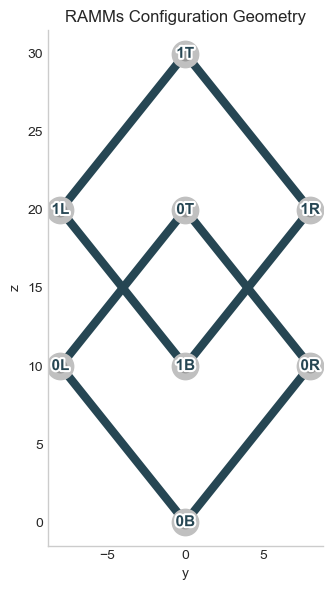

In [23]:
# cell 9
pretty_print_nodes_and_gaps(BASELINE_CONF)
plot_geometry(BASELINE_CONF)

In [116]:
def plot_geometry(conf):
    """
    Plot full RAMMs chain geometry for any number of units.
    """

    nodes_by_unit = get_nodes(conf)

    fig, ax = plt.subplots(figsize=(6, 8))

    unit_segments = [
        ("B", "L"),
        ("L", "T"),
        ("T", "R"),
        ("R", "B"),
    ]

    for unit, unit_nodes in nodes_by_unit.items():

        # --- segments ---
        for a, b in unit_segments:
            Pa = unit_nodes[a]
            Pb = unit_nodes[b]

            ax.plot(
                [Pa[0], Pb[0]],
                [Pa[1], Pb[1]],
                color="#264653",
                linewidth=6,
                zorder=1
            )

        # --- nodes + labels ---
        for label, p in unit_nodes.items():

            y, z = p

            ax.scatter(
                y,
                z,
                facecolor="#999999",
                edgecolor="#c0c0c0",
                linewidth=5,
                s=225,
                zorder=2
            )

            ax.text(
                y,
                z,
                f"{unit}{label}",
                fontsize=11,
                weight="bold",
                color="#264653",
                ha="center",
                va="center",
                zorder=3,
                path_effects=[
                    pe.Stroke(linewidth=3, foreground="white"),
                    pe.Normal()
                ]
            )

    ax.set_aspect("equal")
    ax.set_xlabel("y")
    ax.set_ylabel("z")
    ax.set_title("RAMMs Chain Geometry")

    ax.grid(False)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.tight_layout()
    plt.show()

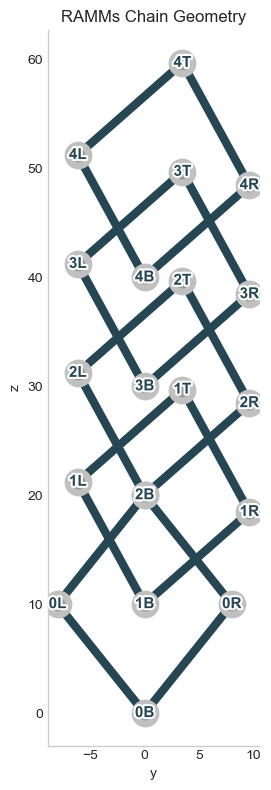

In [117]:
plot_geometry(VALID_CONF)

### Evaluate gaps in a handful of configurations
To verify our smooth_gaps_function() is working, check gaps around the max left and right rotation and min/max z.

##### Intentionally violate to see if g<0's are triggered as expected
here ae the gaps we need to violate: \
node_0B_vs_seg_1B_1L \
node_0B_vs_seg_1B_1R \
node_0T_vs_seg_1B_1L \
node_0T_vs_seg_1B_1R \
node_0T_vs_seg_1L_1T \
node_0T_vs_seg_1R_1T \
node_1B_vs_seg_0B_0L \
node_1B_vs_seg_0B_0R \
node_1B_vs_seg_0L_0T \
node_1B_vs_seg_0R_0T \
node_1L_vs_seg_0L_0T \
node_1R_vs_seg_0R_0T

###### intentionally violate node_0B_vs_seg_1B_1L, node_0B_vs_seg_1B_1R, node_0T_vs_seg_1L_1T and node_0T_vs_seg_1R_1T
put respective nodes on the other side of the segments it cannot intersect

Nodes satisfies diamond shape constraints?: True

                    CONTACT STATE
State: INVALID_OVERLAP

                      GAP VALUES
node_0B_vs_seg_1B_1L                          -0.249390   ❌ VIOLATED
node_0B_vs_seg_1B_1R                          -0.249390   ❌ VIOLATED
node_0L_vs_seg_1B_1L                          -999999.000000   ❌ VIOLATED
node_0R_vs_seg_1B_1R                          -999999.000000   ❌ VIOLATED
node_0T_vs_seg_1B_1L                           999999.000000   ✅ CLEAR
node_0T_vs_seg_1B_1R                           999999.000000   ✅ CLEAR
node_0T_vs_seg_1L_1T                          -999999.000000   ❌ VIOLATED
node_0T_vs_seg_1R_1T                          -999999.000000   ❌ VIOLATED
node_1B_vs_seg_0B_0L                          -999999.000000   ❌ VIOLATED
node_1B_vs_seg_0B_0R                          -999999.000000   ❌ VIOLATED
node_1B_vs_seg_0L_0T                           999999.000000   ✅ CLEAR
node_1B_vs_seg_0R_0T                           999999.000000   ✅

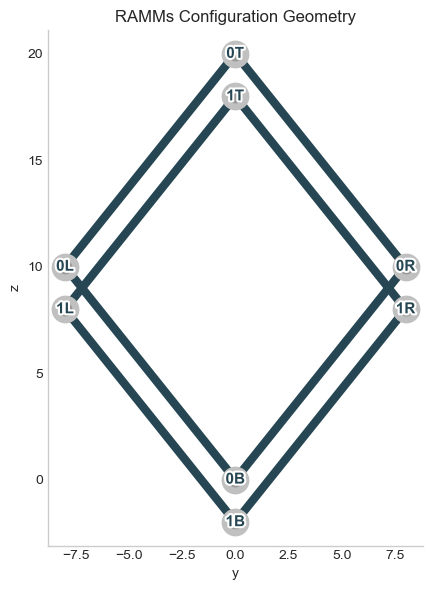

In [24]:
test1_theta=0 # used later so captured here
test1_z = -12
test1_conf = transform_top_unit_from_reference(BASELINE_CONF, theta_deg=test1_theta, z=test1_z)

# Analyze configuration
pretty_print_nodes_and_gaps(test1_conf)
# check segments
print_contact_debug_report(test1_conf)
# plot config
plot_geometry(test1_conf)

###### violate node_0T_vs_seg_1B_1R

Nodes satisfies diamond shape constraints?: True

                    CONTACT STATE
State: INVALID_OVERLAP

                      GAP VALUES
node_0B_vs_seg_1B_1L                           999999.000000   ✅ CLEAR
node_0B_vs_seg_1B_1R                           999999.000000   ✅ CLEAR
node_0L_vs_seg_1B_1L                          -0.116548   ❌ VIOLATED
node_0R_vs_seg_1B_1R                           999999.000000   ✅ CLEAR
node_0T_vs_seg_1B_1L                           8.938837   ✅ CLEAR
node_0T_vs_seg_1B_1R                          -0.104315   ❌ VIOLATED
node_0T_vs_seg_1L_1T                           12.598216   ✅ CLEAR
node_0T_vs_seg_1R_1T                           999999.000000   ✅ CLEAR
node_1B_vs_seg_0B_0L                           5.246950   ✅ CLEAR
node_1B_vs_seg_0B_0R                           5.246950   ✅ CLEAR
node_1B_vs_seg_0L_0T                           5.246950   ✅ CLEAR
node_1B_vs_seg_0R_0T                           5.246950   ✅ CLEAR
node_1L_vs_seg_0L_0T                    

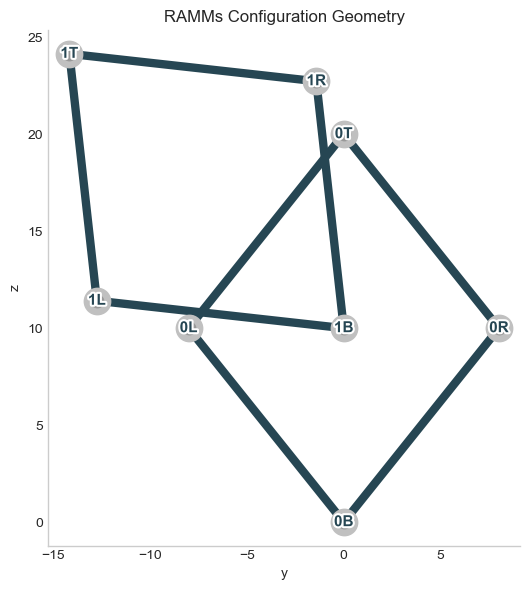

In [25]:
test2_theta = -45 # used later so captured here
test2_z = 0
test2_conf = transform_top_unit_from_reference(BASELINE_CONF, theta_deg=test2_theta, z=test2_z)

# Analyze configuration
pretty_print_nodes_and_gaps(test2_conf)
# check segments
print_contact_debug_report(test2_conf)
# plot config
plot_geometry(test2_conf)

###### violate node_0T_vs_seg_1L_1T

Nodes satisfies diamond shape constraints?: True

                    CONTACT STATE
State: INVALID_OVERLAP

                      GAP VALUES
node_0B_vs_seg_1B_1L                           999999.000000   ✅ CLEAR
node_0B_vs_seg_1B_1R                           999999.000000   ✅ CLEAR
node_0L_vs_seg_1B_1L                           1.224659   ✅ CLEAR
node_0R_vs_seg_1B_1R                          -0.735388   ❌ VIOLATED
node_0T_vs_seg_1B_1L                           999999.000000   ✅ CLEAR
node_0T_vs_seg_1B_1R                           999999.000000   ✅ CLEAR
node_0T_vs_seg_1L_1T                          -0.932851   ❌ VIOLATED
node_0T_vs_seg_1R_1T                           1.517208   ✅ CLEAR
node_1B_vs_seg_0B_0L                           0.249390   ✅ CLEAR
node_1B_vs_seg_0B_0R                           0.249390   ✅ CLEAR
node_1B_vs_seg_0L_0T                           999999.000000   ✅ CLEAR
node_1B_vs_seg_0R_0T                           999999.000000   ✅ CLEAR
node_1L_vs_seg_0L_0T           

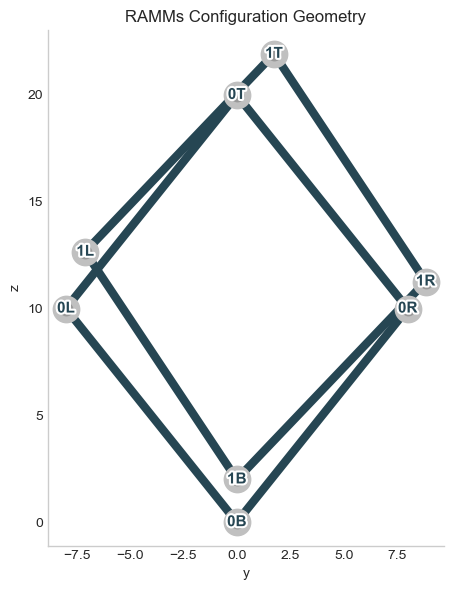

In [26]:
test3_theta = 5 # used later so captured here
test3_z = -8
test3_conf = transform_top_unit_from_reference(BASELINE_CONF, theta_deg=test3_theta, z=test3_z)

# Analyze configuration
pretty_print_nodes_and_gaps(test3_conf)
# check segments
print_contact_debug_report(test3_conf)
# plot config
plot_geometry(test3_conf)

###### violate node_0T_vs_seg_1R_1T

Nodes satisfies diamond shape constraints?: True

                    CONTACT STATE
State: INVALID_OVERLAP

                      GAP VALUES
node_0B_vs_seg_1B_1L                           999999.000000   ✅ CLEAR
node_0B_vs_seg_1B_1R                           999999.000000   ✅ CLEAR
node_0L_vs_seg_1B_1L                          -0.735388   ❌ VIOLATED
node_0R_vs_seg_1B_1R                           1.224659   ✅ CLEAR
node_0T_vs_seg_1B_1L                           999999.000000   ✅ CLEAR
node_0T_vs_seg_1B_1R                           999999.000000   ✅ CLEAR
node_0T_vs_seg_1L_1T                           1.517208   ✅ CLEAR
node_0T_vs_seg_1R_1T                          -0.932851   ❌ VIOLATED
node_1B_vs_seg_0B_0L                           0.249390   ✅ CLEAR
node_1B_vs_seg_0B_0R                           0.249390   ✅ CLEAR
node_1B_vs_seg_0L_0T                           999999.000000   ✅ CLEAR
node_1B_vs_seg_0R_0T                           999999.000000   ✅ CLEAR
node_1L_vs_seg_0L_0T           

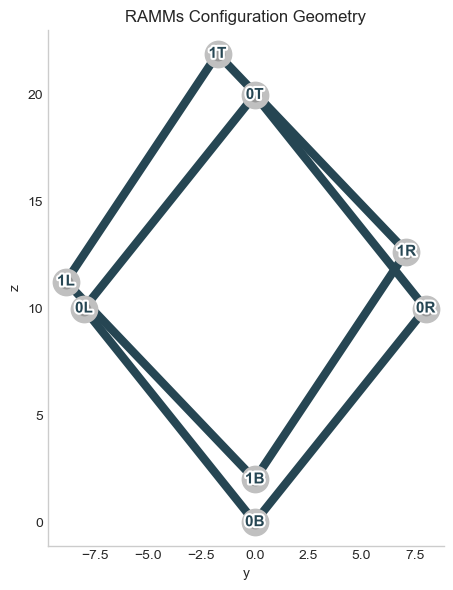

In [27]:
test5_theta = -5 # used later so captured here
test5_z = -8
test5_conf = transform_top_unit_from_reference(BASELINE_CONF, theta_deg=test5_theta, z=test5_z)

# Analyze configuration
pretty_print_nodes_and_gaps(test5_conf)
# check segments
print_contact_debug_report(test5_conf)
# plot config
plot_geometry(test5_conf)

###### node_1B_vs_seg_0B_0R and node_1B_vs_seg_0B_OL
same as test 1

Nodes satisfies diamond shape constraints?: True

                    CONTACT STATE
State: INVALID_OVERLAP

                      GAP VALUES
node_0B_vs_seg_1B_1L                          -0.249390   ❌ VIOLATED
node_0B_vs_seg_1B_1R                          -0.249390   ❌ VIOLATED
node_0L_vs_seg_1B_1L                          -999999.000000   ❌ VIOLATED
node_0R_vs_seg_1B_1R                          -999999.000000   ❌ VIOLATED
node_0T_vs_seg_1B_1L                           999999.000000   ✅ CLEAR
node_0T_vs_seg_1B_1R                           999999.000000   ✅ CLEAR
node_0T_vs_seg_1L_1T                          -999999.000000   ❌ VIOLATED
node_0T_vs_seg_1R_1T                          -999999.000000   ❌ VIOLATED
node_1B_vs_seg_0B_0L                          -999999.000000   ❌ VIOLATED
node_1B_vs_seg_0B_0R                          -999999.000000   ❌ VIOLATED
node_1B_vs_seg_0L_0T                           999999.000000   ✅ CLEAR
node_1B_vs_seg_0R_0T                           999999.000000   ✅

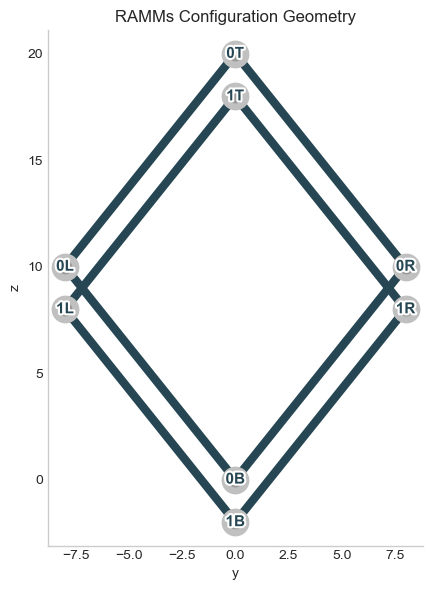

In [28]:
# Analyze configuration
pretty_print_nodes_and_gaps(test1_conf)
# check segments
print_contact_debug_report(test1_conf)
# plot config
plot_geometry(test1_conf)

###### node_1B_vs_seg_0L_0T and node_1B_vs_seg_0R_0T

Nodes satisfies diamond shape constraints?: True

                    CONTACT STATE
State: INVALID_OVERLAP

                      GAP VALUES
node_0B_vs_seg_1B_1L                           999999.000000   ✅ CLEAR
node_0B_vs_seg_1B_1R                           999999.000000   ✅ CLEAR
node_0L_vs_seg_1B_1L                           999999.000000   ✅ CLEAR
node_0R_vs_seg_1B_1R                           999999.000000   ✅ CLEAR
node_0T_vs_seg_1B_1L                           999999.000000   ✅ CLEAR
node_0T_vs_seg_1B_1R                           999999.000000   ✅ CLEAR
node_0T_vs_seg_1L_1T                           999999.000000   ✅ CLEAR
node_0T_vs_seg_1R_1T                           999999.000000   ✅ CLEAR
node_1B_vs_seg_0B_0L                           999999.000000   ✅ CLEAR
node_1B_vs_seg_0B_0R                           999999.000000   ✅ CLEAR
node_1B_vs_seg_0L_0T                          -999999.000000   ❌ VIOLATED
node_1B_vs_seg_0R_0T                          -999999.000000   ❌ VIOLATED
n

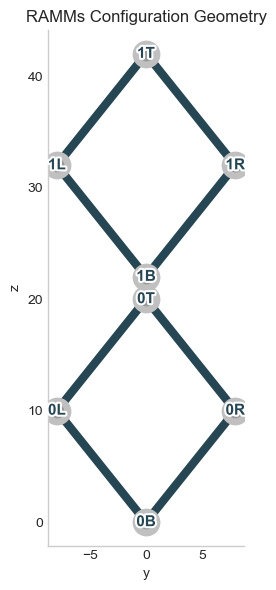

In [29]:
test6_theta = 0 # used later so captured here
test6_z = 12
test6_conf = transform_top_unit_from_reference(BASELINE_CONF, theta_deg=test6_theta, z=test6_z)

# Analyze configuration
pretty_print_nodes_and_gaps(test6_conf)
# check segments
print_contact_debug_report(test6_conf)
# plot config
plot_geometry(test6_conf)

###### node_1L_vs_seg_0L_0T

Nodes satisfies diamond shape constraints?: True

                    CONTACT STATE
State: INVALID_OVERLAP

                      GAP VALUES
node_0B_vs_seg_1B_1L                           999999.000000   ✅ CLEAR
node_0B_vs_seg_1B_1R                           999999.000000   ✅ CLEAR
node_0L_vs_seg_1B_1L                           4.884468   ✅ CLEAR
node_0R_vs_seg_1B_1R                          -2.619804   ❌ VIOLATED
node_0T_vs_seg_1B_1L                           999999.000000   ✅ CLEAR
node_0T_vs_seg_1B_1R                           15.131157   ✅ CLEAR
node_0T_vs_seg_1L_1T                           2.637256   ✅ CLEAR
node_0T_vs_seg_1R_1T                           999999.000000   ✅ CLEAR
node_1B_vs_seg_0B_0L                           0.249390   ✅ CLEAR
node_1B_vs_seg_0B_0R                           0.249390   ✅ CLEAR
node_1B_vs_seg_0L_0T                           999999.000000   ✅ CLEAR
node_1B_vs_seg_0R_0T                           999999.000000   ✅ CLEAR
node_1L_vs_seg_0L_0T             

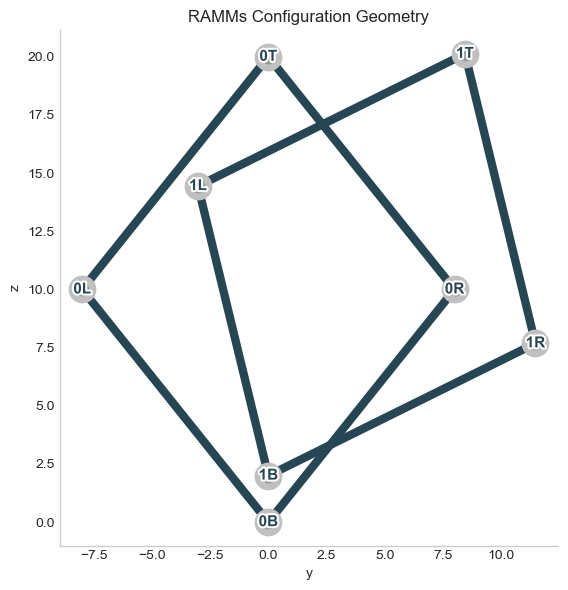

In [30]:
test7_theta = 25 # used later so captured here
test7_z = -8
test7_conf = transform_top_unit_from_reference(BASELINE_CONF, theta_deg=test7_theta, z=test7_z)

# Analyze configuration
pretty_print_nodes_and_gaps(test7_conf)
# check segments
print_contact_debug_report(test7_conf)
# plot config
plot_geometry(test7_conf)

###### node_1R_vs_seg_0R_0T

Nodes satisfies diamond shape constraints?: True

                    CONTACT STATE
State: INVALID_OVERLAP

                      GAP VALUES
node_0B_vs_seg_1B_1L                           999999.000000   ✅ CLEAR
node_0B_vs_seg_1B_1R                           999999.000000   ✅ CLEAR
node_0L_vs_seg_1B_1L                          -2.619804   ❌ VIOLATED
node_0R_vs_seg_1B_1R                           4.884468   ✅ CLEAR
node_0T_vs_seg_1B_1L                           15.131157   ✅ CLEAR
node_0T_vs_seg_1B_1R                           999999.000000   ✅ CLEAR
node_0T_vs_seg_1L_1T                           999999.000000   ✅ CLEAR
node_0T_vs_seg_1R_1T                           2.637256   ✅ CLEAR
node_1B_vs_seg_0B_0L                           0.249390   ✅ CLEAR
node_1B_vs_seg_0B_0R                           0.249390   ✅ CLEAR
node_1B_vs_seg_0L_0T                           999999.000000   ✅ CLEAR
node_1B_vs_seg_0R_0T                           999999.000000   ✅ CLEAR
node_1L_vs_seg_0L_0T             

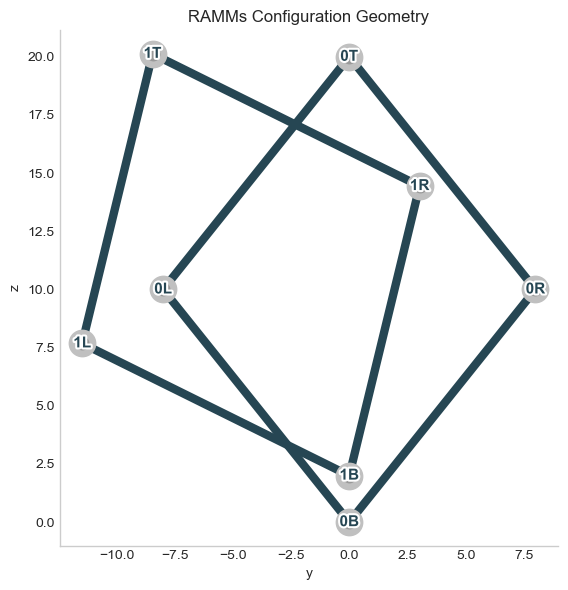

In [31]:
test8_theta = -25 # used later so captured here
test8_z = -8
test8_conf = transform_top_unit_from_reference(BASELINE_CONF, theta_deg=test8_theta, z=test8_z)

# Analyze configuration
pretty_print_nodes_and_gaps(test8_conf)
# check segments
print_contact_debug_report(test8_conf)
# plot config
plot_geometry(test8_conf)

##### Main tests

###### check for gaps = 0 in baseline config rotated to the right

Nodes satisfies diamond shape constraints?: True

                    CONTACT STATE
State: INVALID_OVERLAP

                      GAP VALUES
node_0B_vs_seg_1B_1L                           999999.000000   ✅ CLEAR
node_0B_vs_seg_1B_1R                           999999.000000   ✅ CLEAR
node_0L_vs_seg_1B_1L                           6.851698   ✅ CLEAR
node_0R_vs_seg_1B_1R                          -0.047472   ❌ VIOLATED
node_0T_vs_seg_1B_1L                          -0.065747   ❌ VIOLATED
node_0T_vs_seg_1B_1R                           9.977348   ✅ CLEAR
node_0T_vs_seg_1L_1T                           0.516553   ✅ CLEAR
node_0T_vs_seg_1R_1T                           10.559648   ✅ CLEAR
node_1B_vs_seg_0B_0L                           4.309908   ✅ CLEAR
node_1B_vs_seg_0B_0R                           4.309908   ✅ CLEAR
node_1B_vs_seg_0L_0T                           6.183993   ✅ CLEAR
node_1B_vs_seg_0R_0T                           6.183993   ✅ CLEAR
node_1L_vs_seg_0L_0T                           999

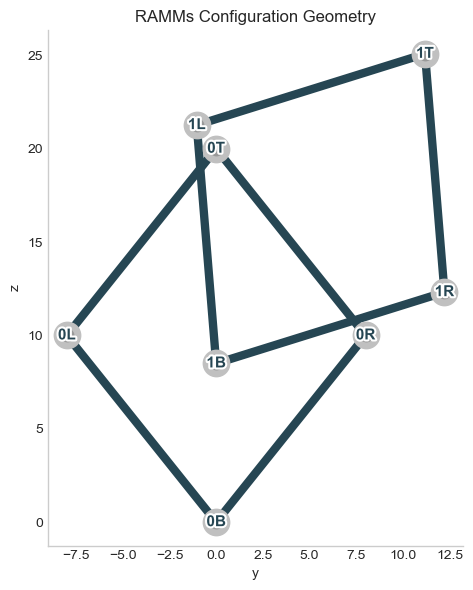

In [32]:
# ------------------------------------------------------------
# Right Rotation Test
# ------------------------------------------------------------

# moves
#right_rotation_test_theta=27.58 # used later so captured here
right_rotation_test_theta=34
right_rotation_test_z=-1.5

# gen new config
right_rotation_test_conf = transform_top_unit_from_reference(BASELINE_CONF, theta_deg=right_rotation_test_theta, z=right_rotation_test_z)

# Analyze configuration
pretty_print_nodes_and_gaps(right_rotation_test_conf)
# check segments
print_contact_debug_report(right_rotation_test_conf)
# plot config
plot_geometry(right_rotation_test_conf)

###### check for gaps = 0 in baseline config rotated to the left

Nodes satisfies diamond shape constraints?: True

                    CONTACT STATE
State: FREE

                      GAP VALUES
node_0B_vs_seg_1B_1L                           999999.000000   ✅ CLEAR
node_0B_vs_seg_1B_1R                           999999.000000   ✅ CLEAR
node_0L_vs_seg_1B_1L                           4.119457   ✅ CLEAR
node_0R_vs_seg_1B_1R                           999999.000000   ✅ CLEAR
node_0T_vs_seg_1B_1L                           6.288915   ✅ CLEAR
node_0T_vs_seg_1B_1R                           0.616803   ✅ CLEAR
node_0T_vs_seg_1L_1T                           9.877098   ✅ CLEAR
node_0T_vs_seg_1R_1T                           4.204986   ✅ CLEAR
node_1B_vs_seg_0B_0L                           6.496341   ✅ CLEAR
node_1B_vs_seg_0B_0R                           6.496341   ✅ CLEAR
node_1B_vs_seg_0L_0T                           3.997560   ✅ CLEAR
node_1B_vs_seg_0R_0T                           3.997560   ✅ CLEAR
node_1L_vs_seg_0L_0T                           6.410812   ✅ CLE

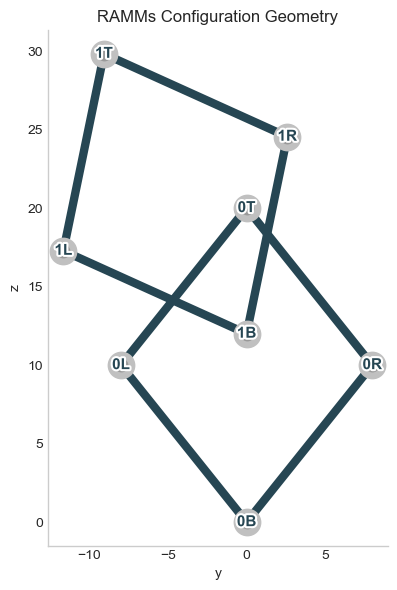

In [33]:
# ------------------------------------------------------------
# Left Rotation Test
# ------------------------------------------------------------

# moves
left_rotation_test_theta=-27 # used later so captured heree
left_rotation_test_z=2

# gen new config
left_rotation_test_conf = transform_top_unit_from_reference(
    BASELINE_CONF, theta_deg=left_rotation_test_theta, z=left_rotation_test_z)

# Analyze configuration
pretty_print_nodes_and_gaps(left_rotation_test_conf)
# check segments
print_contact_debug_report(left_rotation_test_conf)
# plot config
plot_geometry(left_rotation_test_conf)

###### check for gaps = 0 in baseline config -> min z

5.21
Nodes satisfies diamond shape constraints?: True

                    CONTACT STATE
State: INVALID_OVERLAP

                      GAP VALUES
node_0B_vs_seg_1B_1L                           999999.000000   ✅ CLEAR
node_0B_vs_seg_1B_1R                           999999.000000   ✅ CLEAR
node_0L_vs_seg_1B_1L                          -0.375305   ❌ VIOLATED
node_0R_vs_seg_1B_1R                          -0.375305   ❌ VIOLATED
node_0T_vs_seg_1B_1L                           999999.000000   ✅ CLEAR
node_0T_vs_seg_1B_1R                           999999.000000   ✅ CLEAR
node_0T_vs_seg_1L_1T                          -0.375305   ❌ VIOLATED
node_0T_vs_seg_1R_1T                          -0.375305   ❌ VIOLATED
node_1B_vs_seg_0B_0L                          -0.375305   ❌ VIOLATED
node_1B_vs_seg_0B_0R                          -0.375305   ❌ VIOLATED
node_1B_vs_seg_0L_0T                           999999.000000   ✅ CLEAR
node_1B_vs_seg_0R_0T                           999999.000000   ✅ CLEAR
node_1L_vs_seg

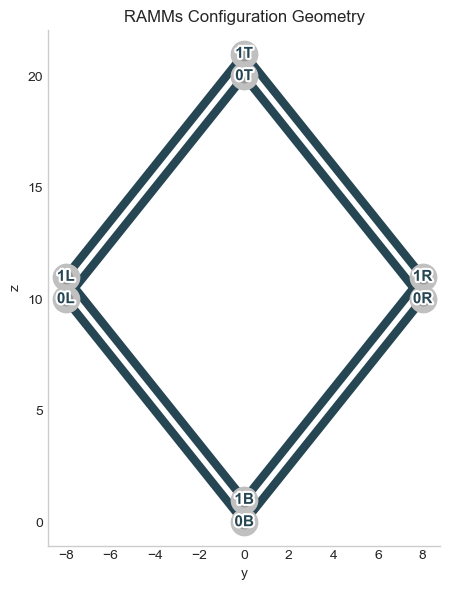

In [34]:
# ------------------------------------------------------------
# Min z test
# ------------------------------------------------------------

# see PIN_DIAMETER_CONTACT_TOL and LEFT_RIGHT_CONTACT_TOL in smooth_gap_function
min_z_theta=0 # used later so captured here
offset = 10-PIN_DIAMETER_CONTACT_TOL-LEFT_RIGHT_CONTACT_TOL
print(10-offset)
min_z = -5.6 # value is ~10 - PIN TOLERANCE - LEFT RIGHT CONTACT TOLERANCE
min_z = -9
min_z_conf = transform_top_unit_from_reference(BASELINE_CONF, theta_deg=min_z_theta, z=min_z)

# Analyze configuration
pretty_print_nodes_and_gaps(min_z_conf)
# check segments
print_contact_debug_report(min_z_conf)
# plot config
plot_geometry(min_z_conf)

###### check for gaps = 0 in baseline config -> z max

7.54
Nodes satisfies diamond shape constraints?: True

                    CONTACT STATE
State: FREE

                      GAP VALUES
node_0B_vs_seg_1B_1L                           999999.000000   ✅ CLEAR
node_0B_vs_seg_1B_1R                           999999.000000   ✅ CLEAR
node_0L_vs_seg_1B_1L                           999999.000000   ✅ CLEAR
node_0R_vs_seg_1B_1R                           999999.000000   ✅ CLEAR
node_0T_vs_seg_1B_1L                           0.499268   ✅ CLEAR
node_0T_vs_seg_1B_1R                           0.499268   ✅ CLEAR
node_0T_vs_seg_1L_1T                           999999.000000   ✅ CLEAR
node_0T_vs_seg_1R_1T                           999999.000000   ✅ CLEAR
node_1B_vs_seg_0B_0L                           999999.000000   ✅ CLEAR
node_1B_vs_seg_0B_0R                           999999.000000   ✅ CLEAR
node_1B_vs_seg_0L_0T                           0.499268   ✅ CLEAR
node_1B_vs_seg_0R_0T                           0.499268   ✅ CLEAR
node_1L_vs_seg_0L_0T             

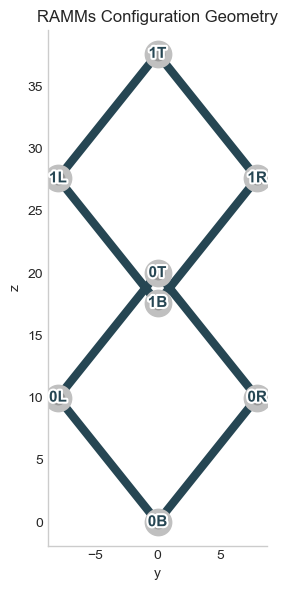

In [35]:
# ------------------------------------------------------------
# Max z Test
# ------------------------------------------------------------
print(10-PIN_DIAMETER_CONTACT_TOL)
max_z_theta=0 # used later so captured here
max_z=7.6
max_z_conf = transform_top_unit_from_reference(BASELINE_CONF, theta_deg=max_z_theta, z=max_z)

# Analyze configuration
pretty_print_nodes_and_gaps(max_z_conf)
# check segments
print_contact_debug_report(max_z_conf)
# plot config
plot_geometry(max_z_conf)

## Plot the Workspace

### Plot a subset of the Workspace
Use a sweep function to plot a small subset of the workspace.

<font color="#E76F51">NOTE: This method isn't great; but just showing first steps because they lead to a better approach.</font>

In [36]:
# --------------------------------------------
# PLOTTING HELPERS
# --------------------------------------------

def state_to_int_helper(s):
    return {
        "invalid_overlap": 0,
        "four-or-more-contacts": 1,
        "triple-contact": 2,
        "double-contact": 3,
        "single-contact": 4,
        "free": 5
    }[s]

def state_to_color(state):
    return palette.get(state, "#999999")  # fallback for unknown states

In [37]:
# --------------------------------------------
# SWEEP FUNCTION
# --------------------------------------------

def sweep_workspace(conf_ref, theta_vals, z_vals, contact_tol=1e-6):
    """
    Sweep a grid of (theta, z) configurations and classify each one.

    For each sampled configuration, this function:
        1. builds the transformed geometry,
        2. evaluates all gap constraints,
        3. classifies the coarse contact state

    Returns a list of records that map configuration space
    (theta, z) to contact state.
    """
    results = []

    for theta in theta_vals:
        for z in z_vals:
            conf = transform_top_unit_from_reference(
                conf_ref,
                theta_deg=theta,
                z=z
            )

            gaps = segment_point_gap_functions(conf)
            min_gap = min(gaps.values())

            contact_state = classify_contact_state(conf, contact_tol)["state"]

            results.append({
                "theta": theta,
                "z": z,
                "contact_state": contact_state,
                "min_gap": min_gap,
            })

    return results

In [38]:
# cell 21
# workspace plotters for simple classifier
def plot_workspace_2d_map(results):
    theta = np.array([r["theta"] for r in results])
    z    = np.array([r["z"] for r in results])
    colors = [state_to_color(r["contact_state"]) for r in results]

    plt.figure(figsize=(8,6))
    plt.scatter(theta, z, c=colors, s=10)

    plt.xlabel("theta_deg")
    plt.ylabel("z")
    plt.title("Workspace State Map")
    plt.grid(True)

    # build legend directly from palette
    for label, color in palette.items():
        plt.scatter([], [], c=color, label=label)

    plt.legend(loc="center left", bbox_to_anchor=(1, 0.5))
    plt.tight_layout() # so it doesnt get cut off
    plt.show()

#### Results

See how contact changes over sweep.

In [39]:
theta_vals = np.linspace(-45, 45, 120)
z_vals = np.linspace(8.5, -12, 120)

results = sweep_workspace(
    BASELINE_CONF,
    theta_vals,
    z_vals
)

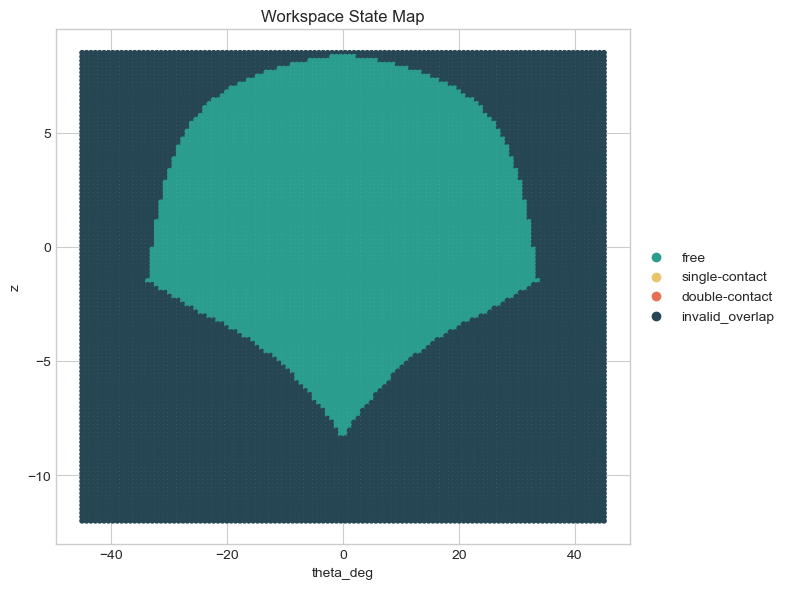

In [40]:
# cell 23
plot_workspace_2d_map(results)

We're only seeing free or invalid_overlap: this classification may be too coarse to capture the RAMMs contact structure.

#### Examine a single point from the workspace sweep

{'theta': -45.0, 'z': -8.72689075630252, 'contact_state': 'invalid_overlap', 'min_gap': -999999.0}
Nodes satisfies diamond shape constraints?: True

                    CONTACT STATE
State: INVALID_OVERLAP

                      GAP VALUES
node_0B_vs_seg_1B_1L                           999999.000000   ✅ CLEAR
node_0B_vs_seg_1B_1R                           999999.000000   ✅ CLEAR
node_0L_vs_seg_1B_1L                          -6.790063   ❌ VIOLATED
node_0R_vs_seg_1B_1R                           7.914794   ✅ CLEAR
node_0T_vs_seg_1B_1L                           17.612352   ✅ CLEAR
node_0T_vs_seg_1B_1R                          -999999.000000   ❌ VIOLATED
node_0T_vs_seg_1L_1T                          -999999.000000   ❌ VIOLATED
node_0T_vs_seg_1R_1T                          -999999.000000   ❌ VIOLATED
node_1B_vs_seg_0B_0L                          -0.204695   ❌ VIOLATED
node_1B_vs_seg_0B_0R                          -0.204695   ❌ VIOLATED
node_1B_vs_seg_0L_0T                           999999.00

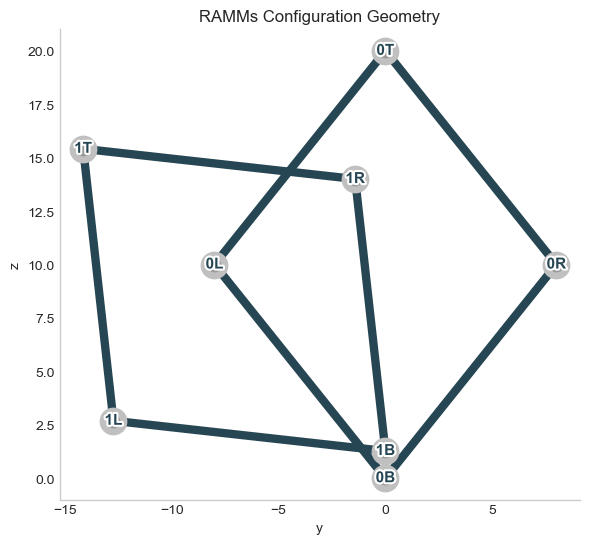

In [41]:
# cell 25
# check random point
r = results[100]
print(r)

# make sure classification matches geometry
config = transform_top_unit_from_reference(
    BASELINE_CONF,
    theta_deg=r["theta"],
    z=r["z"]
)

pretty_print_nodes_and_gaps(config)
plot_geometry(config)

Conclusion: random sweeping for a small subset does not produce very meaningful plots for our system. We need to plot the full reachable workspace, or the contact layer for a single "violation".

## Examine the Contact Layer
The contact layer is the set of configurations where one or more gap functions are exactly zero.

- Mathematically: g_i(q)=0
- Geometrically: Configurations where features are *just starting to* touch

While the initial classification treats all contact uniformly, analyzing the contact layer in detail reveals which configurations still allow motion and which are truly jammed. By linearizing the active constraints, we convert contact geometry into a constraint system whose nullspace determines local mobility.

In [42]:
def get_closest_active_constraint_helper(conf):
    """
    Get the smallest smooth gap and the constraint that produced it.
    This keeps the boundary finder consistent with classify_contact_state().
    """
    gaps = smooth_gap_functions(conf)
    key = min(gaps, key=gaps.get)
    return float(gaps[key]), key

def evaluate_config_helper(conf_ref, theta_deg, z, contact_tol=1e-6):
    """
    Evaluate contact behavior at a single (theta, z) configuration.

    This function builds the configuration, classifies its coarse contact state,
    and extracts a single representative contact value for visualization or
    slice analysis.

    Purpose:
        Reduce the full set of gap constraints to a single scalar field
        that can be plotted over (theta, z).

    Returns:
        dict containing:
            - conf           : full configuration (node positions)
            - contact_state  : coarse classification (free/contacting/invalid)
            - contact_value  : scalar contact measure (e.g., most critical gap)
            - contact_key    : which constraint produced that value
    """

    # ------------------------------------------------------------
    # Build configuration from reduced coordinates (theta, z)
    # ------------------------------------------------------------
    conf = transform_top_unit_from_reference(
        conf_ref,
        theta_deg=theta_deg,
        z=z
    )

    # ------------------------------------------------------------
    # Classify coarse contact state
    # (free, contacting, invalid_overlap)
    # ------------------------------------------------------------
    contact_result = classify_contact_state(conf, contact_tol=contact_tol)

    # ------------------------------------------------------------
    # Extract a single representative contact value
    #
    # This typically selects the "most critical" gap function
    # (e.g., minimum gap) and returns both its value and identity.
    # ------------------------------------------------------------
    contact_value, contact_key = get_closest_active_constraint_helper(conf)

    # ------------------------------------------------------------
    # Return structured result for plotting / analysis
    # ------------------------------------------------------------
    return {
        "conf": conf,
        "contact_state": contact_result["state"],
        "contact_value": contact_value,
        "contact_key": contact_key,
    }

Once we've identified a contact transition, we can use bisection to find the change in z where the contact function =0.

In [43]:
# This function takes a coarse interval where a contact transition occurs and refines
# it into a precise estimate of the contact boundary using 1D bisection
def refine_contact_zero_bisection(
    conf_ref,
    theta_deg,
    z_lo,
    z_hi,
    contact_tol=1e-6,
    z_tol=1e-5,
    max_iter=60,
):
    """
    Refine a contact boundary point along a fixed-theta slice using bisection.

    Given an interval [z_lo, z_hi] at fixed theta_deg, this function looks for
    a zero of the chosen scalar contact function:
        contact_value(theta_deg, z) = 0

    It assumes the interval brackets a sign change in the contact function,
    and repeatedly halves the interval until:
        - the midpoint is close enough to zero, or
        - the z interval becomes sufficiently small.

    Purpose:
        Improve a coarse transition interval into a more precise estimate of
        where the contact layer intersects the slice.

    Returns:
        dict with:
            - theta_deg
            - candidate_z              : refined z location of contact
            - candidate_conf            : configuration at that point
            - candidate_contact_value   : scalar contact value there
            - contact_key               : which constraint defined the value
            - left_state / right_state  : coarse states at final bracketing ends

        Returns None if the initial interval does not bracket a zero.
    """

    # ------------------------------------------------------------
    # Evaluate the scalar contact function at the interval endpoints
    # ------------------------------------------------------------
    out_lo = evaluate_config_helper(conf_ref, theta_deg, z_lo, contact_tol)
    out_hi = evaluate_config_helper(conf_ref, theta_deg, z_hi, contact_tol)

    g_lo = out_lo["contact_value"]
    g_hi = out_hi["contact_value"]

    # ------------------------------------------------------------
    # If either endpoint is already sufficiently close to contact,
    # return it immediately.
    # ------------------------------------------------------------
    if abs(g_lo) <= contact_tol:
        return {
            "theta_deg": theta_deg,
            "candidate_z": z_lo,
            "candidate_conf": out_lo["conf"],
            "candidate_contact_value": g_lo,
            "contact_key": out_lo["contact_key"],
            "left_state": out_lo["contact_state"],
            "right_state": out_hi["contact_state"],
        }

    if abs(g_hi) <= contact_tol:
        return {
            "theta_deg": theta_deg,
            "candidate_z": z_hi,
            "candidate_conf": out_hi["conf"],
            "candidate_contact_value": g_hi,
            "contact_key": out_hi["contact_key"],
            "left_state": out_lo["contact_state"],
            "right_state": out_hi["contact_state"],
        }

    # ------------------------------------------------------------
    # Bisection requires a sign change across the initial interval.
    # If not, we cannot guarantee a root inside.
    # ------------------------------------------------------------
    if g_lo * g_hi > 0:
        return None

    # ------------------------------------------------------------
    # Repeatedly halve the interval to localize the zero of the
    # contact function more precisely.
    # ------------------------------------------------------------
    for _ in range(max_iter):
        # Stop if the interval is already narrow enough
        if abs(z_hi - z_lo) < z_tol:
            break

        # Midpoint of current interval
        z_mid = 0.5 * (z_lo + z_hi)

        # Evaluate contact function at midpoint
        out_mid = evaluate_config_helper(conf_ref, theta_deg, z_mid, contact_tol)
        g_mid = out_mid["contact_value"]

        # If midpoint is already close enough to zero, return it
        if abs(g_mid) <= contact_tol:
            return {
                "theta_deg": theta_deg,
                "candidate_z": z_mid,
                "candidate_conf": out_mid["conf"],
                "candidate_contact_value": g_mid,
                "contact_key": out_mid["contact_key"],
                "left_state": out_lo["contact_state"],
                "right_state": out_hi["contact_state"],
            }

        # Keep the half-interval that still brackets the zero
        if g_lo * g_mid < 0:
            z_hi = z_mid
            out_hi = out_mid
            g_hi = g_mid
        else:
            z_lo = z_mid
            out_lo = out_mid
            g_lo = g_mid

    # ------------------------------------------------------------
    # If we exit without hitting the zero directly, return the final
    # midpoint as the best available estimate.
    # ------------------------------------------------------------
    z_star = 0.5 * (z_lo + z_hi)
    out_star = evaluate_config_helper(conf_ref, theta_deg, z_star, contact_tol)

    return {
        "theta_deg": theta_deg,
        "candidate_z": z_star,
        "candidate_conf": out_star["conf"],
        "candidate_contact_value": out_star["contact_value"],
        "contact_key": out_star["contact_key"],
        "left_state": out_lo["contact_state"],
        "right_state": out_hi["contact_state"],
    }

For a chosen angle theta_deg, scan through z values, look for the first place where the scalar contact function reaches zero, and refine that location with bisection.

In [44]:
# cell 31
def find_first_contact_z_for_theta(
    conf_ref,
    theta_deg,
    z_min=-12,
    z_max=2,
    n_scan=500,
    contact_tol=1e-6,
    z_tol=1e-5,
):
    """
    Find the first contact point along a fixed-theta slice in z.

    For a chosen angle theta_deg, this function scans z over [z_min, z_max],
    evaluates the scalar contact function at each sampled point, and looks for
    the first place where:
        - the contact value is already near zero, or
        - the contact value changes sign between neighboring samples.

    If a sign change is detected, the contact location is refined using
    bisection.

    Purpose:
        Locate where the contact layer intersects a fixed-theta slice.

    Returns:
        dict containing a refined candidate contact point, or None if no
        contact is found in the scanned z range.

    Notes:
        "First" means first in the scan order from z_min -> z_max.
    """

    # ------------------------------------------------------------
    # Sample z values along a 1D slice at fixed theta
    # ------------------------------------------------------------
    z_vals = np.linspace(z_min, z_max, n_scan)

    # ------------------------------------------------------------
    # Evaluate the configuration and scalar contact function at
    # each sampled z point
    # ------------------------------------------------------------
    records = [
        {
            "z": z,
            **evaluate_config_helper(conf_ref, theta_deg, z, contact_tol)
        }
        for z in z_vals
    ]

    # ------------------------------------------------------------
    # Check neighboring sample points for:
    #   1. direct contact at a sample point
    #   2. a sign change indicating a zero crossing between samples
    # ------------------------------------------------------------
    for a, b in zip(records[:-1], records[1:]):
        g_a = a["contact_value"]
        g_b = b["contact_value"]

        # If left endpoint is already at contact, return it
        if abs(g_a) <= contact_tol:
            return {
                "theta_deg": theta_deg,
                "candidate_z": a["z"],
                "candidate_conf": a["conf"],
                "candidate_contact_value": g_a,
                "contact_key": a["contact_key"],
                "left_state": a["contact_state"],
                "right_state": a["contact_state"],
            }

        # If right endpoint is already at contact, return it
        if abs(g_b) <= contact_tol:
            return {
                "theta_deg": theta_deg,
                "candidate_z": b["z"],
                "candidate_conf": b["conf"],
                "candidate_contact_value": g_b,
                "contact_key": b["contact_key"],
                "left_state": b["contact_state"],
                "right_state": b["contact_state"],
            }

        # If the contact function changes sign, a zero lies between a and b
        # Refine that candidate with bisection
        if g_a * g_b < 0:
            return refine_contact_zero_bisection(
                conf_ref=conf_ref,
                theta_deg=theta_deg,
                z_lo=a["z"],
                z_hi=b["z"],
                contact_tol=contact_tol,
                z_tol=z_tol,
            )

    # No contact crossing found in this z range
    return None

# cell 32
def trace_contact_boundary_single_side(
    conf_ref,
    theta_vals,
    z_min=-12,
    z_max=2,
    n_scan=800,
    contact_tol=1e-6,
    z_tol=1e-5,
):
    boundary = []

    for theta_deg in theta_vals:
        hit = find_first_contact_z_for_theta(
            conf_ref=conf_ref,
            theta_deg=theta_deg,
            z_min=z_min,
            z_max=z_max,
            n_scan=n_scan,
            contact_tol=contact_tol,
            z_tol=z_tol,
        )

        if hit is None:
            continue

        # always keep the normal boundary point
        boundary.append(hit)

        z_val = hit["candidate_z"]

        conf = transform_top_unit_from_reference(
            conf_ref,
            theta_deg,
            z_val,
        )

        gaps = smooth_gap_functions(conf)

        # count how many contacts are near zero
        near_zero = [
            name for name, val in gaps.items()
            if abs(val) < 1e-3   # <-- IMPORTANT: loose tolerance
        ]

        if len(near_zero) >= 2:
            # mark this as a special contact point
            hit_multi = hit.copy()
            hit_multi["multi_contact"] = True
            hit_multi["active_contacts"] = near_zero

            boundary.append(hit_multi)

    return boundary

def trace_contact_boundary_full(
    conf_ref,
    theta_vals,
    z_min=-12,
    z_max=12,
    n_scan=500,
    contact_tol=1e-6,
    z_tol=1e-5,
):
    # lower branch: scan bottom -> top, finds first lower contact
    lower_boundary = trace_contact_boundary_single_side(
        conf_ref=conf_ref,
        theta_vals=theta_vals,
        z_min=z_min,
        z_max=z_max,
        n_scan=n_scan,
        contact_tol=contact_tol,
        z_tol=z_tol,
    )

    # upper branch: scan top -> bottom, finds first upper contact
    upper_boundary = trace_contact_boundary_single_side(
        conf_ref=conf_ref,
        theta_vals=theta_vals,
        z_min=z_max,
        z_max=z_min,
        n_scan=n_scan,
        contact_tol=contact_tol,
        z_tol=z_tol,
    )

    # tag branches so plotting/animation can separate them later if needed
    for pt in lower_boundary:
        pt["boundary_branch"] = "lower"

    for pt in upper_boundary:
        pt["boundary_branch"] = "upper"

    # reverse upper so curve continues from same side
    upper_boundary = list(reversed(upper_boundary))

    return lower_boundary + upper_boundary

In [45]:
# cell 33
def plot_contact_boundary(boundary):
    theta = [b["theta_deg"] for b in boundary]
    z     = [b["candidate_z"] for b in boundary]

    plt.figure(figsize=(8, 6))
    plt.plot(theta, z, linewidth=2)
    plt.xlabel("theta_deg")
    plt.ylabel("contact boundary z")
    plt.title("Contact Boundary Curve")
    plt.grid(True)
    plt.show()

In [46]:
def debug_contact_boundary_scan(
    conf_ref,
    theta_deg=0,
    z_vals=None,
    print_header=True,
    highlight_transitions=True,
):
    """
    Scan along z for a fixed theta and print contact state evolution.

    Useful for:
    - Debugging contact boundary behavior
    - Identifying where contact activates (g ≈ 0)
    - Detecting constraint switching (key changes)

    Parameters
    ----------
    conf_ref : baseline configuration
    theta_deg : float
        Fixed rotation angle
    z_vals : iterable of floats
        Values of z to scan
    print_header : bool
        Whether to print table header
    highlight_transitions : bool
        Mark when contact state or key changes

    Returns
    -------
    results : list of dict
        Raw outputs for further analysis
    """
    if z_vals is None:
        z_vals = np.linspace(2, -8, 30)

    results = []
    prev_state = None
    prev_key = None

    if print_header:
        print(f"\n=== Contact Scan @ theta = {theta_deg:.2f} deg ===")
        print(f"{'z':>8} | {'state':>15} | {'value':>12} | {'key'}")
        print("-" * 60)

    for z in z_vals:
        out = evaluate_config_helper(conf_ref, theta_deg, z)

        state = out["contact_state"]
        val = out["contact_value"]
        key = out["contact_key"]

        # detect transitions
        transition_flag = ""
        if highlight_transitions:
            if prev_state is not None and state != prev_state:
                transition_flag += "  <-- STATE CHANGE"
            if prev_key is not None and key != prev_key:
                transition_flag += "  <-- KEY CHANGE"

        print(f"{z:8.3f} | {state:15s} | {val:12.6e} | {key}{transition_flag}")

        results.append({
            "z": z,
            "state": state,
            "value": val,
            "key": key,
        })

        prev_state = state
        prev_key = key

    return results

In [47]:
results = debug_contact_boundary_scan(
    BASELINE_CONF,
    theta_deg=0,     # try also 38
    z_vals=np.linspace(2, -8, 30),
)


=== Contact Scan @ theta = 0.00 deg ===
       z |           state |        value | key
------------------------------------------------------------
   2.000 | free            | 3.997560e+00 | node_1B_vs_seg_0R_0T
   1.655 | free            | 4.212972e+00 | node_1B_vs_seg_0R_0T
   1.310 | free            | 4.428385e+00 | node_1B_vs_seg_0R_0T
   0.966 | free            | 4.643797e+00 | node_1B_vs_seg_0R_0T
   0.621 | free            | 4.859209e+00 | node_1B_vs_seg_0R_0T
   0.276 | free            | 5.074621e+00 | node_1B_vs_seg_0R_0T
  -0.069 | free            | 5.203868e+00 | node_1L_vs_seg_0L_0T  <-- KEY CHANGE
  -0.414 | free            | 4.988456e+00 | node_1L_vs_seg_0L_0T
  -0.759 | free            | 4.773044e+00 | node_1L_vs_seg_0L_0T
  -1.103 | free            | 4.557632e+00 | node_1L_vs_seg_0L_0T
  -1.448 | free            | 4.342220e+00 | node_1L_vs_seg_0L_0T
  -1.793 | free            | 4.126808e+00 | node_1L_vs_seg_0L_0T
  -2.138 | free            | 3.911396e+00 | node_1B_vs

Number of boundary hits: 180


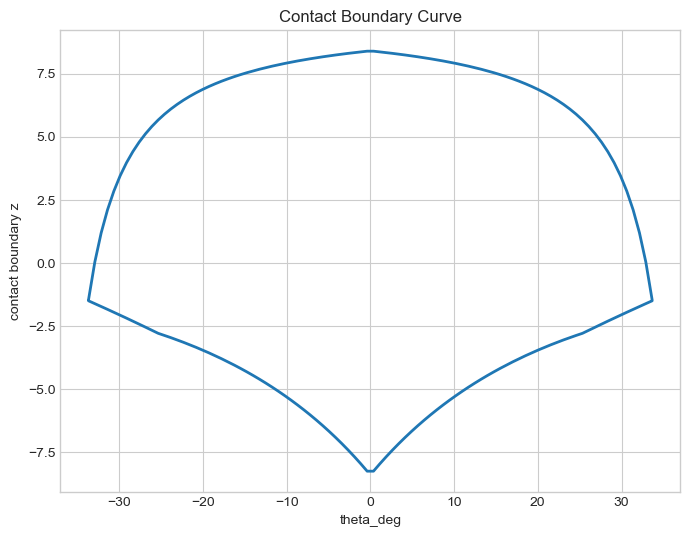

In [48]:
"""
boundary = trace_contact_boundary_single_side(
    conf_ref=BASELINE_CONF,
    theta_vals=theta_vals,
    z_min=-12,
    z_max=12,
    n_scan=500,
    z_tol=1e-5,
)
"""
boundary = trace_contact_boundary_full(
    conf_ref=BASELINE_CONF,
    theta_vals=theta_vals,
    z_min=-12,
    z_max=12,
    n_scan=500,
    z_tol=1e-5,
)

print("Number of boundary hits:", len(boundary))
plot_contact_boundary(boundary)

The gap on the left exists because the upper and lower traces do not share the exact same endpoint on that side.

In [49]:
def classify_boundary_points(boundary, conf_ref, contact_tol=1e-6):
    boundary_results = []

    for b in boundary:
        conf = b["candidate_conf"]
        gaps = smooth_gap_functions(conf)

        active_contacts = b.get("active_contacts", [b["contact_key"]])

        contact_info = [
            {
                "active_gap": name,
                "gap_value": gaps.get(name, None),
            }
            for name in active_contacts
        ]

        contact_result = classify_contact_state(
            conf,
            contact_tol=contact_tol,
        )

        contact_state = contact_result["state"]

        if abs(b["candidate_contact_value"]) > contact_tol and contact_state == "free":
            contact_state = "midpoint_off_boundary"

        boundary_results.append({
            "theta_deg": b["theta_deg"],
            "z": b["candidate_z"],
            "boundary_branch": b.get("boundary_branch", "missing"),
            "contact_state": contact_state,
            "contact_info": contact_info,
        })

    return boundary_results

Classify the boundary points by their contact state

In [50]:
boundary_results = classify_boundary_points(boundary, BASELINE_CONF)

Draw the boundary curve again with color-coded contact states

In [51]:
# interactive version of cell 39 using Plotly
def _safe_get(b, key, default=""):
    return b[key] if key in b else default

def _fmt_array(arr, precision=4):
    if arr is None:
        return "None"
    arr = np.array(arr)
    return np.array2string(arr, precision=precision, suppress_small=True)

def plot_boundary_by_jam_state_interactive(boundary_results):
    # pull data
    theta = [_safe_get(b, "theta_deg", np.nan) for b in boundary_results]
    z = [_safe_get(b, "z", np.nan) for b in boundary_results]
    states = [_safe_get(b, "contact_state", "unknown") for b in boundary_results]

    counts = Counter(states)

    fig = go.Figure()

    unique_states = sorted(set(states))

    for state in unique_states:
        idx = [i for i, s in enumerate(states) if s == state]
        if not idx:
            continue

        x = [theta[i] for i in idx]
        y = [z[i] for i in idx]

        color = palette.get(state, "#999999")

        hover_text = []
        for i in idx:
            b = boundary_results[i]

            contact_key = _safe_get(b, "contact_key", None)
            if isinstance(contact_key, (list, tuple)):
                contact_key_str = "<br>".join(map(str, contact_key)) if contact_key else "None"
            else:
                contact_key_str = str(contact_key) if contact_key is not None else "None"

            contact_value = _safe_get(b, "contact_value", np.nan)

            hover_text.append(
                f"<b>theta_deg</b>: {theta[i]:.4f}<br>"
                f"<b>z</b>: {z[i]:.6f}<br>"
                f"<b>state</b>: {state}<br>"
                f"<b>contact value</b>: {contact_value:.6e}<br>"
                f"<b>boundary gap</b>: {contact_key_str}<br>"
            )

        # ------------------------------------------------------------
        # SPECIAL STYLE for off-boundary points
        # ------------------------------------------------------------
        if state == "midpoint_off_boundary":
            marker_style = dict(
                color="#B0B0B0",      # soft gray fill
                size=7,
                opacity=0.35,        # lighter interior
                line=dict(
                    color="#2F2F2F", # dark border
                    width=1.5,
                ),
            )
        else:
            marker_style = dict(
                color=color,
                size=7,
            )

        fig.add_trace(
            go.Scatter(
                x=x,
                y=y,
                mode="markers",
                name=f"{state} (n={counts[state]})",
                marker=marker_style,
                text=hover_text,
                hovertemplate="%{text}<extra></extra>",
            )
        )

    fig.update_layout(
        title="Contact Boundary Colored by Jamming State",
        xaxis_title="theta_deg",
        yaxis_title="contact boundary z",
        template="plotly_white",
        width=900,
        height=600,
        legend=dict(x=1.02, y=0.5, xanchor="left", yanchor="middle"),
    )

    fig.show()

In [52]:
plot_boundary_by_jam_state_interactive(boundary_results)

### Why do some traced boundary points appear as "midpoint_off_boundary"?

The boundary curve is found numerically by scanning in $z$ and then refining a zero of the chosen gap function with a bisection-style procedure. In an ideal case, the returned point would lie exactly on the contact set, meaning the gap value would satisfy

$|g(\theta, z)| \leq \text{contact\_tol}$

In practice, the refinement can terminate because the final bracket in $z$ becomes small, even if the midpoint of that bracket is not exactly on the zero level set. When that happens, the returned point is still *near* the contact boundary, but it may classify as `"free"` when re-evaluated by the contact-state classifier.

These points are not interpreted as physically meaningful free points on the true contact layer. Instead, they are numerical artifacts of the boundary extraction step: they come from a valid contact bracket, but the final stored midpoint lands slightly off the boundary.

To make this explicit in the plots, these points are labeled `"midpoint_off_boundary"` rather than being mixed in with true free-space points. This makes the visualization more honest: the point belongs to the boundary-finding pipeline, but not to the final physical contact set.

In [53]:
# remove invalid overlap and midpoint off boundary points
def plot_boundary_clean_with_smooth_line(boundary_results):
    """
    Plot boundary points by contact state, excluding midpoint_off_boundary,
    and draw a smooth spline-like line under the physical boundary points.
    """

    # ------------------------------------------------------------
    # keep only physical boundary points for plotting
    # ------------------------------------------------------------
    kept = [
        b for b in boundary_results
        if _safe_get(b, "contact_state", "unknown") not in ["midpoint_off_boundary", "invalid_overlap"]
    ]

    if not kept:
        print("No boundary points to plot after filtering.")
        return

    # sort by theta so the line draws correctly
    kept = sorted(kept, key=lambda b: _safe_get(b, "theta_deg", np.nan))

    theta_all = [_safe_get(b, "theta_deg", np.nan) for b in kept]
    z_all = [_safe_get(b, "z", np.nan) for b in kept]
    states_all = [_safe_get(b, "contact_state", "unknown") for b in kept]

    counts = Counter(states_all)

    fig = go.Figure()

    print(Counter([_safe_get(b, "boundary_branch", "missing") for b in kept]))
    
    # ------------------------------------------------------------
    # draw boundary curve separately by branch
    # ------------------------------------------------------------
    for branch in ["lower", "upper"]:
        pts = [
            b for b in kept
            if _safe_get(b, "boundary_branch", "unknown") == branch
        ]

        if len(pts) < 2:
            continue

        pts = sorted(pts, key=lambda b: _safe_get(b, "theta_deg", np.nan))

        fig.add_trace(
            go.Scatter(
                x=[_safe_get(p, "theta_deg", np.nan) for p in pts],
                y=[_safe_get(p, "z", np.nan) for p in pts],
                mode="lines",
                name=f"boundary curve ({branch})",
                line=dict(color="rgba(80,80,80,0.45)", width=3),
                hoverinfo="skip",
            )
        )
    # ------------------------------------------------------------
    # colored markers by state
    # ------------------------------------------------------------
    unique_states = sorted(set(states_all))

    for state in unique_states:
        idx = [i for i, s in enumerate(states_all) if s == state]
        if not idx:
            continue

        x = [theta_all[i] for i in idx]
        y = [z_all[i] for i in idx]
        color = palette.get(state, "#999999")

        hover_text = []
        for i in idx:
            b = kept[i]

            contact_key = _safe_get(b, "contact_key", None)
            if isinstance(contact_key, (list, tuple)):
                contact_key_str = "<br>".join(map(str, contact_key)) if contact_key else "None"
            else:
                contact_key_str = str(contact_key) if contact_key is not None else "None"

            contact_value = _safe_get(b, "contact_value", np.nan)

            hover_text.append(
                f"<b>theta_deg</b>: {theta_all[i]:.4f}<br>"
                f"<b>z</b>: {z_all[i]:.6f}<br>"
                f"<b>state</b>: {state}<br>"
                f"<b>contact value</b>: {contact_value:.6e}<br>"
                f"<b>boundary gap</b>: {contact_key_str}<br>"
            )

        fig.add_trace(
            go.Scatter(
                x=x,
                y=y,
                mode="markers",
                name=f"{state} (n={counts[state]})",
                marker=dict(
                    color=color,
                    size=7,
                ),
                text=hover_text,
                hovertemplate="%{text}<extra></extra>",
            )
        )

    fig.update_layout(
        title='Contact Boundary (Filtered) with Smooth Interpolated Curve',
        xaxis_title='theta_deg',
        yaxis_title='contact boundary z',
        template='plotly_white',
        width=900,
        height=600,
        legend=dict(x=1.02, y=0.5, xanchor='left', yanchor='middle'),
    )

    fig.show()

In [54]:
plot_boundary_clean_with_smooth_line(boundary_results)

Counter({'upper': 90, 'lower': 78})


### Turn the boundary tracing plot an ineractive plotly movie!

In [55]:
def plot_boundary_with_geometry_movie(
    boundary_results,
    conf_ref=BASELINE_CONF,
    n_frames=5,
    frame_duration=800,
):
    """
    Plotly figure with:
      - left: filtered boundary curve + highlighted selected point
      - right: RAMM geometry for that selected boundary point
      - animation: lower branch, then upper branch
    """

    # ------------------------------------------------------------
    # 1) keep only physical boundary points
    # ------------------------------------------------------------
    kept = [
        b for b in boundary_results
        if _safe_get(b, "contact_state", "unknown")
        not in ["midpoint_off_boundary", "invalid_overlap"]
    ]

    if not kept:
        print("No boundary points to plot after filtering.")
        return

    def boundary_animation_order(points):
        lower = [
            b for b in points
            if _safe_get(b, "boundary_branch", "missing") == "lower"
        ]

        upper = [
            b for b in points
            if _safe_get(b, "boundary_branch", "missing") == "upper"
        ]

        other = [
            b for b in points
            if _safe_get(b, "boundary_branch", "missing")
            not in ["lower", "upper"]
        ]

        lower = sorted(lower, key=lambda b: _safe_get(b, "theta_deg", np.nan))
        upper = sorted(upper, key=lambda b: _safe_get(b, "theta_deg", np.nan))
        other = sorted(other, key=lambda b: _safe_get(b, "theta_deg", np.nan))

        # smooth loop-like order:
        # lower left → right, then upper right → left
        return lower + upper[::-1] + other

    # use branch-aware order for animation
    animation_pts = boundary_animation_order(kept)

    # use theta-sorted order only for marker arrays/counts
    kept_for_markers = sorted(
        kept,
        key=lambda b: _safe_get(b, "theta_deg", np.nan)
    )

    theta_all = np.array(
        [_safe_get(b, "theta_deg", np.nan) for b in kept_for_markers],
        dtype=float,
    )
    z_all = np.array(
        [_safe_get(b, "z", np.nan) for b in kept_for_markers],
        dtype=float,
    )
    states_all = [
        _safe_get(b, "contact_state", "unknown")
        for b in kept_for_markers
    ]

    counts = Counter(states_all)

    # ------------------------------------------------------------
    # 2) line points
    # ------------------------------------------------------------
    line_pts = [
        b for b in kept
        if _safe_get(b, "contact_state", "unknown") in [
            "free",
            "single-contact",
            "double-contact",
            "triple-contact",
            "four-or-more-contacts",
        ]
    ]

    # ------------------------------------------------------------
    # 3) pick animation points branch-by-branch
    # ALWAYS include double-contact points
    # ------------------------------------------------------------

    def sample_branch(points, n):
        if not points or n <= 0:
            return []

        n = max(1, min(n, len(points)))

        idx = np.linspace(
            0,
            len(points) - 1,
            n,
        ).round().astype(int)

        idx = np.unique(idx)

        return [points[i] for i in idx]


    # ------------------------------------------------------------
    # separate by branch
    # ------------------------------------------------------------
    lower_pts = [
        b for b in kept
        if _safe_get(b, "boundary_branch", "missing") == "lower"
    ]

    upper_pts = [
        b for b in kept
        if _safe_get(b, "boundary_branch", "missing") == "upper"
    ]

    # ------------------------------------------------------------
    # separate out double-contact points
    # ------------------------------------------------------------
    lower_double = [
        b for b in lower_pts
        if _safe_get(b, "contact_state", "") == "double-contact"
    ]

    upper_double = [
        b for b in upper_pts
        if _safe_get(b, "contact_state", "") == "double-contact"
    ]

    lower_regular = [
        b for b in lower_pts
        if _safe_get(b, "contact_state", "") != "double-contact"
    ]

    upper_regular = [
        b for b in upper_pts
        if _safe_get(b, "contact_state", "") != "double-contact"
    ]

    # ------------------------------------------------------------
    # sort by theta
    # ------------------------------------------------------------
    lower_regular = sorted(
        lower_regular,
        key=lambda b: _safe_get(b, "theta_deg", np.nan)
    )

    upper_regular = sorted(
        upper_regular,
        key=lambda b: _safe_get(b, "theta_deg", np.nan)
    )

    lower_double = sorted(
        lower_double,
        key=lambda b: _safe_get(b, "theta_deg", np.nan)
    )

    upper_double = sorted(
        upper_double,
        key=lambda b: _safe_get(b, "theta_deg", np.nan)
    )

    # ------------------------------------------------------------
    # reserve frames for double-contact points
    # ------------------------------------------------------------
    n_reserved = len(lower_double) + len(upper_double)

    remaining_frames = max(0, n_frames - n_reserved)

    n_lower_regular = max(1, remaining_frames // 2)
    n_upper_regular = max(1, remaining_frames - n_lower_regular)

    # ------------------------------------------------------------
    # sample regular points
    # ------------------------------------------------------------
    selected_lower_regular = sample_branch(
        lower_regular,
        n_lower_regular,
    )

    selected_upper_regular = sample_branch(
        upper_regular,
        n_upper_regular,
    )

    # ------------------------------------------------------------
    # combine:
    # lower left→right
    # upper right→left
    # ------------------------------------------------------------
    selected_lower = sorted(
        selected_lower_regular + lower_double,
        key=lambda b: _safe_get(b, "theta_deg", np.nan)
    )

    selected_upper = sorted(
        selected_upper_regular + upper_double,
        key=lambda b: _safe_get(b, "theta_deg", np.nan)
    )

    selected_pts = (
        selected_lower +
        selected_upper[::-1]
    )

    # ------------------------------------------------------------
    # helpers for geometry traces
    # ------------------------------------------------------------
    def get_point(conf, y_sym, z_sym):
        return float(conf[y_sym]), float(conf[z_sym])

    def build_geometry_arrays(conf):
        nodes = {
            "0B": get_point(conf, y0B, z0B),
            "0L": get_point(conf, y0L, z0L),
            "0R": get_point(conf, y0R, z0R),
            "0T": get_point(conf, y0T, z0T),
            "1B": get_point(conf, y1B, z1B),
            "1L": get_point(conf, y1L, z1L),
            "1R": get_point(conf, y1R, z1R),
            "1T": get_point(conf, y1T, z1T),
        }

        segments = [
            ("0B", "0L"), ("0L", "0T"), ("0T", "0R"), ("0R", "0B"),
            ("1B", "1L"), ("1L", "1T"), ("1T", "1R"), ("1R", "1B"),
        ]

        seg_x = []
        seg_y = []

        for a, b in segments:
            seg_x += [nodes[a][0], nodes[b][0], None]
            seg_y += [nodes[a][1], nodes[b][1], None]

        node_x = [nodes[k][0] for k in nodes]
        node_y = [nodes[k][1] for k in nodes]
        node_labels = list(nodes.keys())

        return seg_x, seg_y, node_x, node_y, node_labels

    def geometry_traces_for_point(theta_deg, z):
        conf = transform_top_unit_from_reference(
            conf_ref,
            theta_deg=theta_deg,
            z=z,
        )

        seg_x, seg_y, node_x, node_y, node_labels = build_geometry_arrays(conf)

        seg_trace = go.Scatter(
            x=seg_x,
            y=seg_y,
            mode="lines",
            line=dict(color="#264653", width=4),
            name="geometry",
            hoverinfo="skip",
            showlegend=False,
        )

        node_trace = go.Scatter(
            x=node_x,
            y=node_y,
            mode="markers+text",
            text=node_labels,
            textposition="top center",
            textfont=dict(
                size=13,
                color="#264653",
                family="Arial Black",
            ),
            marker=dict(
                size=16,
                color="#999999",
                line=dict(color="#264653", width=2),
            ),
            name="nodes",
            hovertemplate=(
                "<b>%{text}</b><br>"
                "y: %{x:.3f}<br>"
                "z: %{y:.3f}<extra></extra>"
            ),
            showlegend=False,
        )

        return seg_trace, node_trace

    # ------------------------------------------------------------
    # 4) initial frame point
    # ------------------------------------------------------------
    first_pt = selected_pts[0]
    theta0 = float(_safe_get(first_pt, "theta_deg", np.nan))
    z0 = float(_safe_get(first_pt, "z", np.nan))
    state0 = _safe_get(first_pt, "contact_state", "unknown")

    seg_trace0, node_trace0 = geometry_traces_for_point(theta0, z0)

    # ------------------------------------------------------------
    # 5) create subplot figure
    # ------------------------------------------------------------
    fig = make_subplots(
        rows=1,
        cols=2,
        column_widths=[0.55, 0.45],
        subplot_titles=("Boundary Curve", "Geometry"),
        horizontal_spacing=0.12,
    )

    # ------------------------------------------------------------
    # smooth boundary lines, separated by branch
    # ------------------------------------------------------------
    branch_values = sorted(set(
        _safe_get(b, "boundary_branch", "missing")
        for b in line_pts
    ))

    for branch in branch_values:
        branch_pts = [
            b for b in line_pts
            if _safe_get(b, "boundary_branch", "missing") == branch
        ]

        if len(branch_pts) < 2:
            continue

        branch_pts = sorted(
            branch_pts,
            key=lambda b: _safe_get(b, "theta_deg", np.nan)
        )

        fig.add_trace(
            go.Scatter(
                x=[_safe_get(b, "theta_deg", np.nan) for b in branch_pts],
                y=[_safe_get(b, "z", np.nan) for b in branch_pts],
                mode="lines",
                name=f"boundary curve ({branch})",
                line=dict(
                    color="rgba(80,80,80,0.45)",
                    width=3,
                    shape="spline",
                    smoothing=1.0,
                ),
                hoverinfo="skip",
            ),
            row=1,
            col=1,
        )

    # ------------------------------------------------------------
    # colored boundary markers by state
    # ------------------------------------------------------------
    unique_states = sorted(set(states_all))

    for state in unique_states:
        idx = [i for i, s in enumerate(states_all) if s == state]

        if not idx:
            continue

        x = [theta_all[i] for i in idx]
        y = [z_all[i] for i in idx]
        color = palette.get(state, "#999999")

        hover_text = []

        for i in idx:
            b = kept_for_markers[i]

            contact_info = _safe_get(b, "contact_info", [])

            if contact_info:
                contact_str = "<br>".join(
                    [
                        f"{c.get('active_gap', 'unknown')}: "
                        f"{c.get('gap_value', np.nan):.6e}"
                        for c in contact_info
                    ]
                )
            else:
                contact_str = "None"

            branch = _safe_get(b, "boundary_branch", "missing")

            hover_text.append(
                f"<b>theta_deg</b>: {theta_all[i]:.4f}<br>"
                f"<b>z</b>: {z_all[i]:.6f}<br>"
                f"<b>state</b>: {state}<br>"
                f"<b>branch</b>: {branch}<br>"
                f"<b>contacts</b>:<br>{contact_str}<br>"
            )

        fig.add_trace(
            go.Scatter(
                x=x,
                y=y,
                mode="markers",
                name=f"{state} (n={counts[state]})",
                marker=dict(color=color, size=7),
                text=hover_text,
                hovertemplate="%{text}<extra></extra>",
            ),
            row=1,
            col=1,
        )

    # ------------------------------------------------------------
    # highlighted animated point on boundary
    # ------------------------------------------------------------
    fig.add_trace(
        go.Scatter(
            x=[theta0],
            y=[z0],
            mode="markers",
            marker=dict(
                size=15,
                color="white",
                line=dict(color="#264653", width=3),
                symbol="circle",
            ),
            name="selected point",
            hovertemplate=(
                f"<b>selected point</b><br>"
                f"theta: {theta0:.4f}<br>"
                f"z: {z0:.6f}<br>"
                f"state: {state0}<extra></extra>"
            ),
            showlegend=False,
        ),
        row=1,
        col=1,
    )

    selected_point_trace_idx = len(fig.data) - 1

    # initial geometry traces
    fig.add_trace(seg_trace0, row=1, col=2)
    geometry_trace_idx = len(fig.data) - 1

    fig.add_trace(node_trace0, row=1, col=2)
    node_trace_idx = len(fig.data) - 1

    # ------------------------------------------------------------
    # 6) set axis ranges for geometry panel
    # ------------------------------------------------------------
    all_geom_x = []
    all_geom_y = []

    for pt in selected_pts:
        th = float(_safe_get(pt, "theta_deg", np.nan))
        z = float(_safe_get(pt, "z", np.nan))

        conf = transform_top_unit_from_reference(
            conf_ref,
            theta_deg=th,
            z=z,
        )

        _, _, node_x, node_y, _ = build_geometry_arrays(conf)

        all_geom_x.extend(node_x)
        all_geom_y.extend(node_y)

    x_pad = 2.0
    y_pad = 2.0

    fig.update_xaxes(title_text="theta_deg", row=1, col=1)
    fig.update_yaxes(title_text="contact boundary z", row=1, col=1)

    fig.update_xaxes(
        title_text="y",
        range=[min(all_geom_x) - x_pad, max(all_geom_x) + x_pad],
        scaleanchor="y2",
        row=1,
        col=2,
    )

    fig.update_yaxes(
        title_text="z",
        range=[min(all_geom_y) - y_pad, max(all_geom_y) + y_pad],
        row=1,
        col=2,
    )

    # ------------------------------------------------------------
    # 7) animation frames
    # ------------------------------------------------------------
    frames = []

    for k, pt in enumerate(selected_pts):
        th = float(_safe_get(pt, "theta_deg", np.nan))
        z = float(_safe_get(pt, "z", np.nan))
        st = _safe_get(pt, "contact_state", "unknown")
        branch = _safe_get(pt, "boundary_branch", "missing")

        seg_trace_k, node_trace_k = geometry_traces_for_point(th, z)

        frame = go.Frame(
            name=f"frame_{k}",
            data=[
                go.Scatter(
                    x=[th],
                    y=[z],
                    mode="markers",
                    marker=dict(
                        size=15,
                        color="white",
                        line=dict(color="#264653", width=3),
                        symbol="circle",
                    ),
                    hovertemplate=(
                        f"<b>selected point</b><br>"
                        f"theta: {th:.4f}<br>"
                        f"z: {z:.6f}<br>"
                        f"state: {st}<br>"
                        f"branch: {branch}<extra></extra>"
                    ),
                    showlegend=False,
                ),
                seg_trace_k,
                node_trace_k,
            ],
            traces=[
                selected_point_trace_idx,
                geometry_trace_idx,
                node_trace_idx,
            ],
        )

        frames.append(frame)

    fig.frames = frames

    # ------------------------------------------------------------
    # 8) slider labels
    # ------------------------------------------------------------
    slider_steps = []

    for k, pt in enumerate(selected_pts):
        th = float(_safe_get(pt, "theta_deg", np.nan))
        z = float(_safe_get(pt, "z", np.nan))
        branch = _safe_get(pt, "boundary_branch", "missing")

        slider_steps.append(
            dict(
                method="animate",
                label=f"{k + 1}: {branch}, θ={th:.2f}, z={z:.2f}",
                args=[
                    [f"frame_{k}"],
                    dict(
                        mode="immediate",
                        frame=dict(duration=frame_duration, redraw=True),
                        transition=dict(duration=200),
                    ),
                ],
            )
        )

    # ------------------------------------------------------------
    # 9) layout / controls
    # ------------------------------------------------------------
    fig.update_layout(
        title="Boundary Curve with Geometry Animation",
        template="plotly_white",
        width=1300,
        height=650,

        legend=dict(
            x=0.02,
            y=0.98,
            xanchor="left",
            yanchor="top",
            bgcolor="rgba(255,255,255,0.7)",
        ),

        # uncomment to remove legend
        showlegend=False,
        
        updatemenus=[
            dict(
                type="buttons",
                showactive=False,

                x=0.42,
                y=1.12,
                xanchor="center",
                yanchor="top",

                direction="left",

                buttons=[

                    # ------------------------------------------------
                    # PLAY
                    # ------------------------------------------------
                    dict(
                        label="▶ Play",
                        method="animate",

                        args=[
                            None,

                            dict(
                                frame=dict(
                                    duration=frame_duration,
                                    redraw=True,
                                ),

                                transition=dict(
                                    duration=250,
                                ),

                                fromcurrent=True,
                                mode="immediate",
                            ),
                        ],
                    ),

                    # ------------------------------------------------
                    # PAUSE
                    # ------------------------------------------------
                    dict(
                        label="⏸ Pause",
                        method="animate",

                        args=[
                            [None],

                            dict(
                                frame=dict(
                                    duration=0,
                                    redraw=False,
                                ),

                                transition=dict(
                                    duration=0,
                                ),

                                mode="immediate",
                            ),
                        ],
                    ),
                ],
            )
        ],

        sliders=[
            dict(
                active=0,

                x=0.12,
                y=-0.08,
                len=0.76,

                currentvalue=dict(
                    prefix="Frame: "
                ),

                pad=dict(
                    t=30
                ),

                steps=slider_steps,
            )
        ],
    )

    fig.show()
    return fig


In [56]:
fig = plot_boundary_with_geometry_movie(boundary_results, n_frames=30)

In [57]:
fig.write_html("boundary_geometry_movie.html")

In [58]:
import imageio #TODO: move these
import os

def export_plotly_animation(fig, filename="animation.mp4", fps=2):
    temp_dir = "temp_frames"
    os.makedirs(temp_dir, exist_ok=True)

    images = []

    for i, frame in enumerate(fig.frames):
        fig.update(data=frame.data)

        path = f"{temp_dir}/frame_{i:03d}.png"
        fig.write_image(path, scale=2)
        images.append(imageio.imread(path))

    imageio.mimsave(filename, images, fps=fps)

    print(f"Saved to {filename}")

In [59]:
# TODO: get this working or remove
#export_plotly_animation(fig, "ramm_boundary.gif", fps=2) # we know this isnt working rn...gotta hack it

## Solving the Eigenvalue Problem (also Rank & Nullity Stuff)

Once a configuration is classified as *contacting*, we move from geometry to
local kinematic analysis by linearizing the active contact constraints.

Each active smooth gap function defines a one-sided constraint of the form:
    g_i(q) ≥ 0

At contact (g_i ≈ 0), we compute the gradient of each active constraint with
respect to the configuration variables q = [θ, z]. These gradients form the
rows of the contact Jacobian C.

This Jacobian captures how infinitesimal changes in configuration affect the
active contacts. By analyzing its nullspace, we determine whether any feasible
tangent motion exists that preserves contact.

This leads to a local classification:
- **single-contact**: tangent motion exists (nullspace non-empty)
- **single-contact**: no feasible motion remains (nullspace empty)

In short:
    configuration → active constraints → Jacobian C → nullspace → jamming state

#### Rank & Nullity Helpers

In [60]:
# ------------------------------------------------------------
# Helper: get set of active constraints
# ------------------------------------------------------------

def get_active_smooth_constraints(conf, contact_tol=1e-6):
    g = smooth_gap_functions(conf)
    active = {k: v for k, v in g.items() if abs(v) <= contact_tol}
    return active, g

# ------------------------------------------------------------
# Helper: find numerical gradient of each active gap
# ------------------------------------------------------------

def eval_gap_by_name_helper(conf_ref, theta_deg, z_mm, gap_name):
    conf = transform_top_unit_from_reference(conf_ref, theta_deg, z_mm)   # <-- replace with your actual config builder
    gaps = segment_point_gap_functions(conf)
    return gaps[gap_name]

# ------------------------------------------------------------
# Helper: get numerical gradient of gap
# ------------------------------------------------------------

def numerical_gap_gradient_helper(conf_ref, theta_deg, z_mm, gap_name,
                                  h_theta=1e-5, h_z=1e-6):
    """
    Numerical gradient of one *smooth* gap with respect to [theta, z].
    """
    conf_p = transform_top_unit_from_reference(conf_ref, theta_deg + h_theta, z_mm)
    conf_m = transform_top_unit_from_reference(conf_ref, theta_deg - h_theta, z_mm)
    dgdtheta = (
        smooth_gap_functions(conf_p)[gap_name] - smooth_gap_functions(conf_m)[gap_name]
    ) / (2 * h_theta)

    conf_p = transform_top_unit_from_reference(conf_ref, theta_deg, z_mm + h_z)
    conf_m = transform_top_unit_from_reference(conf_ref, theta_deg, z_mm - h_z)
    dgz = (
        smooth_gap_functions(conf_p)[gap_name] - smooth_gap_functions(conf_m)[gap_name]
    ) / (2 * h_z)

    return np.array([dgdtheta, dgz], dtype=float)

### Rank & Nullity

In [61]:
# contact linearization methods

# ------------------------------------------------------------
# Build the Jacobian
# ------------------------------------------------------------

def build_contact_jacobian(
    conf_ref,
    theta_deg,
    z,
    contact_tol=1e-6,
    h_theta=1e-5,
    h_z=1e-6,
    include_only=None,
):
    """
    Build contact Jacobian C for active smooth constraints.

    By default, uses all smooth constraints active at the point.
    Optionally restrict to a provided list of gap names via include_only.

    Returns
    -------
    C : (m x 2) array
    active_names : list[str]
    gaps : dict
    """
    conf = transform_top_unit_from_reference(conf_ref, theta_deg, z)
    gaps = smooth_gap_functions(conf)

    if include_only is None:
        active_names = [k for k, v in gaps.items() if abs(v) <= contact_tol]
    else:
        active_names = [
            k for k in include_only
            if k in gaps and abs(gaps[k]) <= contact_tol
        ]

    if len(active_names) == 0:
        return np.zeros((0, 2)), active_names, gaps

    rows = []
    for name in active_names:
        grad = numerical_gap_gradient_helper(
            conf_ref,
            theta_deg,
            z,
            name,
            h_theta=h_theta,
            h_z=h_z
        )
        rows.append(grad)

    C = np.vstack(rows)
    return C, active_names, gaps


def build_named_contact_jacobian(
    conf_ref,
    theta_deg,
    z,
    gap_name,
    h_theta=1e-5,
    h_z=1e-6,
):
    """
    Build a 1-row Jacobian for one chosen smooth contact constraint.

    This is the Jacobian of the traced contact branch g(theta, z) = 0.

    Returns
    -------
    C : (1 x 2) array
        Row = gradient of the chosen gap wrt q = [theta, z]

    gap_value : float
        Value of the chosen gap at the query point

    gaps : dict
        Full smooth gap dictionary at the point
    """
    conf = transform_top_unit_from_reference(conf_ref, theta_deg, z)
    gaps = smooth_gap_functions(conf)

    if gap_name not in gaps:
        raise KeyError(
            f"Gap '{gap_name}' not found in smooth_gap_functions(conf). "
            f"Available keys: {list(gaps.keys())}"
        )

    grad = numerical_gap_gradient_helper(
        conf_ref,
        theta_deg,
        z,
        gap_name,
        h_theta=h_theta,
        h_z=h_z,
    )

    C = grad.reshape(1, -1)
    return C, float(gaps[gap_name]), gaps

# ------------------------------------------------------------
# Compute the nullspace
# ------------------------------------------------------------

def nullspace(A, tol=1e-10):
    """
    Numerical nullspace of A via SVD.
    Returns basis vectors as columns of N.
    """
    U, S, Vt = np.linalg.svd(A, full_matrices=True)

    rank = np.sum(S > tol)
    N = Vt[rank:].T   # columns span nullspace
    return N, rank, S

In [62]:
def pretty_print_named_contact_jacobian_result(
    C,
    gap_value,
    gaps,
    gap_name,
    tol_gap=1e-8,
    var_names=None,
    show_all_gaps=False,
):
    """
    Pretty print the output of build_named_contact_jacobian(...).

    Parameters
    ----------
    C : (1, n) array
        Jacobian row of the chosen gap wrt q
    gap_value : float
        Value of the chosen gap at the query point
    gaps : dict
        Full smooth gap dictionary at the point
    gap_name : str
        Name of the chosen gap
    tol_gap : float
        Tolerance for deciding whether gap_value is "on the boundary"
    var_names : list[str] or None
        Optional variable names, e.g. ["theta", "z"]
    show_all_gaps : bool
        If True, print all gap values in the dictionary
    """
    import numpy as np

    C = np.asarray(C)

    if C.ndim != 2 or C.shape[0] != 1:
        raise ValueError(f"C must have shape (1, n). Got {C.shape}.")

    n = C.shape[1]
    grad = C[0]

    if var_names is None:
        var_names = [f"q{i}" for i in range(n)]

    if len(var_names) != n:
        raise ValueError(
            f"len(var_names) must match number of columns in C ({n}). "
            f"Got {len(var_names)} names."
        )

    print("=" * 70)
    print("NAMED CONTACT JACOBIAN ANALYSIS")
    print("=" * 70)

    print(f"Chosen gap: {gap_name}")
    print(f"Gap value at query point: {gap_value:+.6e}")

    if abs(gap_value) <= tol_gap:
        gap_status = "ON the contact boundary (approximately g(q)=0)"
    elif gap_value > 0:
        gap_status = "ON the feasible / open side of the boundary (positive gap)"
    else:
        gap_status = "ON the violated / penetrated side of the boundary (negative gap)"

    print(f"Interpretation: {gap_status}")
    print()

    print("Jacobian row C = ∇g(q)^T:")
    print(C)
    print()

    print("Component-wise meaning:")
    for name, val in zip(var_names, grad):
        direction = "increases" if val > 0 else "decreases" if val < 0 else "does not change"
        print(f"  ∂g/∂{name} = {val:+.6e}   --> increasing {name} locally {direction} the gap")

    print()

    grad_norm = np.linalg.norm(grad)
    print(f"||∇g|| = {grad_norm:.6e}")

    if grad_norm < 1e-14:
        print("Warning: gradient is near zero.")
        print("This means the contact branch may be locally degenerate or numerically unstable here.")
    else:
        print("Interpretation:")
        print("  - The gradient is normal to the level set g(q)=0.")
        print("  - So this row points perpendicular to the traced contact branch in (theta, z) space.")
        print("  - Motions tangent to the branch satisfy C @ dq ≈ 0.")
    print()

    if n == 2:
        theta_comp, z_comp = grad
        print("2D branch interpretation:")
        print(f"  Normal vector to the branch: [{theta_comp:+.6f}, {z_comp:+.6f}]")

        if abs(z_comp) > 1e-12:
            slope = -theta_comp / z_comp
            print(f"  Tangent relation from dg = 0:")
            print(f"     d(z)/d(theta) ≈ {slope:+.6f}")
            print("  This is the local slope of the contact branch in (theta, z) coordinates.")
        elif abs(theta_comp) > 1e-12:
            print("  Tangent relation from dg = 0:")
            print("     z is the natural free tangent direction here (branch is approximately vertical).")
        else:
            print("  Tangent relation cannot be resolved because the gradient is approximately zero.")

        # Tangent vector example
        tangent = np.array([-z_comp, theta_comp], dtype=float)
        tangent_norm = np.linalg.norm(tangent)
        if tangent_norm > 1e-14:
            tangent_unit = tangent / tangent_norm
            print(f"  One tangent direction satisfying C @ t = 0 is:")
            print(f"     t = {tangent_unit}")
        print()

    if show_all_gaps:
        print("All smooth gap values at this point:")
        for k, v in gaps.items():
            marker = " <-- chosen gap" if k == gap_name else ""
            print(f"  {k}: {float(v):+.6e}{marker}")
        print()

    print("Key idea:")
    print("  g(theta, z) = 0 defines the traced contact branch.")
    print("  C = [∂g/∂theta, ∂g/∂z] is the local normal to that branch.")
    print("  Tangent motions along the branch satisfy C @ dq = 0.")
    print("=" * 70)

def pretty_print_contact_jacobian_result(
    C,
    active_names,
    theta_deg=None,
    z=None,
    tol=1e-9,
):
    """
    Pretty-print analysis of a full contact Jacobian C(q).

    Handles arbitrary size C (k x 2 for your system).

    Parameters
    ----------
    C : ndarray
        Contact Jacobian (k x 2)
    active_names : list[str]
        Names of active constraints
    theta_deg : float (optional)
    z : float (optional)
    tol : float
        SVD tolerance for rank
    """

    print("\n" + "="*60)
    print("CONTACT JACOBIAN ANALYSIS")
    print("="*60)

    if theta_deg is not None and z is not None:
        print(f"(theta, z) = ({theta_deg:.6f}, {z:.6f})")

    print(f"\nActive constraints ({len(active_names)}):")
    for name in active_names:
        print(f"  - {name}")

    print("\nC matrix:")
    print(C)

    # Handle empty case
    if C.size == 0:
        print("\nNo active constraints → FREE configuration")
        print("Rank = 0, Nullity = 2 (full motion allowed)")
        return

    # SVD
    U, S, Vt = np.linalg.svd(C)

    rank = np.sum(S > tol)
    n_vars = C.shape[1]  # should be 2
    nullity = n_vars - rank

    print("\nSingular values:")
    print(S)

    print(f"\nRank     = {rank}")
    print(f"Nullity  = {nullity}")

    # Nullspace basis
    nullspace = Vt.T[:, rank:] if rank < n_vars else np.zeros((n_vars, 0))

    print("\nNullspace basis (columns = allowed motions δq):")
    if nullspace.shape[1] == 0:
        print("  None (no allowed motion)")
    else:
        print(nullspace)

    # Mechanical interpretation
    print("\nMechanical interpretation:")

    if rank == 0:
        print("  → No active constraints")
        print("  → System is FREE (2 DOF motion)")

    elif rank == 1:
        print("  → One independent constraint")
        print("  → System is PARTIALLY CONSTRAINED")
        print("  → 1 DOF motion allowed (sliding along contact)")

    elif rank == 2:
        print("  → Two independent constraints")
        print("  → System is JAMMED (no motion allowed)")

    else:
        print("  → Unexpected rank (check constraints)")

    print("="*60 + "\n")

def pretty_print_nullspace_result(N, rank, S, tol=1e-10, var_names=None):
    """
    Pretty print the result of nullspace(A).

    Inputs:
        N         : nullspace basis (columns)
        rank      : rank of A
        S         : singular values
        tol       : threshold used for rank
        var_names : optional names for variables (e.g., ["theta", "z"])
    """

    n = N.shape[0] if N.size > 0 else len(S)

    if var_names is None:
        var_names = [f"q{i}" for i in range(n)]

    print("="*60)
    print("NULLSPACE ANALYSIS")
    print("="*60)

    print(f"Rank: {rank}")
    print(f"Nullity (dimension of nullspace): {n - rank}")
    print()

    print("Singular Values (constraint strength):")
    for i, s in enumerate(S):
        status = "ACTIVE (constraining)" if s > tol else "ZERO (free direction)"
        print(f"  σ[{i}] = {s:.6e}  --> {status}")
    print()

    if N.size == 0 or N.shape[1] == 0:
        print("Nullspace is empty → no allowable motion (fully constrained / jammed).")
        print("="*60)
        return

    print("Nullspace Basis Vectors:")
    print("Each vector = allowable motion direction that preserves constraints.\n")

    for i in range(N.shape[1]):
        vec = N[:, i]

        print(f"--- Basis Vector {i+1} ---")
        for name, val in zip(var_names, vec):
            print(f"  {name}: {val:+.6f}")

        # Interpretation (pairwise for intuition)
        print("Interpretation:")

        nonzero = np.abs(vec) > 1e-6
        active_vars = [name for name, nz in zip(var_names, nonzero) if nz]

        if len(active_vars) == 0:
            print("  → Zero vector (unexpected)")
        elif len(active_vars) == 1:
            print(f"  → Pure motion in {active_vars[0]}")
        else:
            base_idx = np.argmax(np.abs(vec))
            base_name = var_names[base_idx]
            base_val = vec[base_idx]

            print(f"  → Coupled motion relative to {base_name}:")
            for j, (name, val) in enumerate(zip(var_names, vec)):
                if j != base_idx and abs(val) > 1e-6:
                    ratio = val / base_val
                    print(f"     {name} ≈ {ratio:+.4f} * {base_name}")

        print()

    print("="*60)
    print("Key Insight:")
    print("Nullspace = motions that do NOT violate active constraints.")
    print("Rank      = number of independent constraints.")
    print("="*60)

In [63]:
def plot_C_matrix(C):
    C = np.array(C)

    plt.figure(figsize=(5,5))

    # origin
    plt.scatter(0, 0)
    plt.text(0, 0, " q")

    if C.size == 0:
        plt.text(0, 0.2, "C is empty")
    else:
        for i, row in enumerate(C):
            # normalize so you can see direction clearly
            v = row / np.linalg.norm(row)

            plt.quiver(
                0, 0,
                v[0], v[1],
                angles="xy", scale_units="xy", scale=1
            )

            plt.text(v[0], v[1], f"row {i+1}")

    plt.axhline(0)
    plt.axvline(0)
    plt.gca().set_aspect("equal", adjustable="box")
    plt.xlim(-1, 1)
    plt.ylim(-1, 1)
    plt.xlabel("theta")
    plt.ylabel("z")
    plt.title("C matrix rows (gradients)")
    plt.grid()
    plt.show()

In [64]:
def plot_C_matrix_pretty(C):
    C = np.array(C, dtype=float)

    fig, ax = plt.subplots(figsize=(6,6))

    # clean background
    ax.set_facecolor("#f8f9fb")

    # origin
    ax.scatter(0, 0, s=80, color="black", zorder=3)
    ax.text(0.02, 0.02, "q", fontsize=12, weight="bold")

    if C.size == 0:
        ax.text(0, 0.2, "No active constraints", ha="center", fontsize=12, color="gray")
    else:
        for i, row in enumerate(C):
            norm = np.linalg.norm(row)
            if norm < 1e-12:
                continue

            v = row / norm  # normalize

            # draw arrow
            ax.quiver(
                0, 0,
                v[0], v[1],
                angles="xy",
                scale_units="xy",
                scale=1,
                width=0.008,
                color="#1f77b4",  # nice blue
                zorder=2
            )

            # label
            ax.text(
                v[0]*1.1, v[1]*1.1,
                f"g{i+1}",
                fontsize=11,
                weight="bold",
                color="#1f77b4"
            )

    # axes lines (clean)
    ax.axhline(0, linewidth=1.2, color="black", alpha=0.6)
    ax.axvline(0, linewidth=1.2, color="black", alpha=0.6)

    # limits
    ax.set_xlim(-1.2, 1.2)
    ax.set_ylim(-1.2, 1.2)

    # labels
    ax.set_xlabel("θ (rotation)", fontsize=12)
    ax.set_ylabel("z (translation)", fontsize=12)

    # remove top/right spines
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    # grid (light, subtle)
    ax.grid(True, linestyle="--", alpha=0.2)

    ax.set_aspect("equal", adjustable="box")
    ax.set_title("Constraint Gradients (C matrix)", fontsize=14, weight="bold")

    plt.show()

### Analyze the C matrix
Get the C matrix of the baseline for comparison (this should be empty/[0]); then look at the C matrix for one of the gap functions (i.e. try one of the segment boundaries traced above).

In [65]:
C_baseline, active_gaps, gaps_full = build_contact_jacobian(
        BASELINE_CONF,
        right_rotation_test_theta,
        right_rotation_test_z,
        contact_tol=1e-6,
        h_theta=1e-5,
        h_z=1e-10,
    )

C_baseline # we expect C to be empty for a free baseline config

array([], shape=(0, 2), dtype=float64)

### Double-Contact Points
Let's take a closer look at all the double contact points in our system

#### Finding Double-Contact Points Setup

First, print all the gap names here for convenience

In [66]:
print_all_gaps()

node_0B_vs_seg_1B_1L                          --> 0B vs (1B-1L)
node_0B_vs_seg_1B_1R                          --> 0B vs (1B-1R)
node_0L_vs_seg_1B_1L                          --> 0L vs (1B-1L)
node_0R_vs_seg_1B_1R                          --> 0R vs (1B-1R)
node_0T_vs_seg_1B_1L                          --> 0T vs (1B-1L)
node_0T_vs_seg_1B_1R                          --> 0T vs (1B-1R)
node_0T_vs_seg_1L_1T                          --> 0T vs (1L-1T)
node_0T_vs_seg_1R_1T                          --> 0T vs (1R-1T)
node_1B_vs_seg_0B_0L                          --> 1B vs (0B-0L)
node_1B_vs_seg_0B_0R                          --> 1B vs (0B-0R)
node_1B_vs_seg_0L_0T                          --> 1B vs (0L-0T)
node_1B_vs_seg_0R_0T                          --> 1B vs (0R-0T)
node_1L_vs_seg_0L_0T                          --> 1L vs (0L-0T)
node_1R_vs_seg_0R_0T                          --> 1R vs (0R-0T)
node_1B_min_clearance_above_0T_z              --> 1B above 0T
node_1L_min_clearance_above_0L_z          

There are four double contact positions in our 2-unit RAMMs. Here they are:

    gap_a="node_0R_vs_seg_1B_1R", # max theta (max right rotation)
    gap_b="node_0T_vs_seg_1B_1L",

    gap_a="node_0L_vs_seg_1B_1L", # min theta (max left rotation)
    gap_b="node_0T_vs_seg_1B_1R",

    gap_a="node_0T_vs_seg_1B_1R", # max z
    gap_b="node_0T_vs_seg_1B_1L",

    gap_a="node_0B_vs_seg_1B_1L", # min z
    gap_b="node_0B_vs_seg_1B_1R",

Define some methods we'll use multiple times while finding each double contact point.

Function to find the contact point:

In [67]:
def find_double_contact_by_gap_pair(
    conf_ref,
    gap_a,
    gap_b,
    theta_guess,
    z_guess,
    tol=1e-9,
    verbose=True,
):
    """
    Solve for a double-contact point where two named gaps are both zero.

    Returns a result dictionary.
    If the solve fails, it prints a warning and returns success=False
    instead of raising an error.
    """

    def F(x):
        theta_deg, z = x

        conf = transform_top_unit_from_reference(
            conf_ref,
            theta_deg=theta_deg,
            z=z,
        )

        gaps = smooth_gap_functions(conf)

        return np.array([
            gaps[gap_a],
            gaps[gap_b],
        ], dtype=float)

    sol = root(F, x0=np.array([theta_guess, z_guess], dtype=float))

    theta_star, z_star = sol.x

    conf_star = transform_top_unit_from_reference(
        conf_ref,
        theta_deg=theta_star,
        z=z_star,
    )

    gaps_star = smooth_gap_functions(conf_star)

    residual = np.linalg.norm(F(sol.x))

    active_names = [
        name for name, val in gaps_star.items()
        if abs(val) <= tol
    ]

    result = {
        "success": bool(sol.success and residual <= tol),
        "message": sol.message,
        "theta_deg": theta_star,
        "z": z_star,
        "gap_a": gap_a,
        "gap_b": gap_b,
        "gap_a_value": gaps_star[gap_a],
        "gap_b_value": gaps_star[gap_b],
        "active_names": active_names,
        "all_gaps": gaps_star,
        "residual_norm": residual,
        "solution": sol,
    }

    if verbose:
        if result["success"]:
            print("\n" + "="*80)
            print("DOUBLE CONTACT SOLVE SUCCEEDED")
            print("="*80)
        else:
            print("\n" + "="*80)
            print("DOUBLE CONTACT SOLVE FAILED")
            print("="*80)

        print("theta_deg:", result["theta_deg"])
        print("z:", result["z"])
        print("gap_a:", gap_a, "=", result["gap_a_value"])
        print("gap_b:", gap_b, "=", result["gap_b_value"])
        print("residual norm:", result["residual_norm"])
        print("solver message:", result["message"])
        print("active names:", result["active_names"])
        print("="*80 + "\n")

    return result

Pretty print functions:

In [68]:
def pretty_print_contact_analysis(
    C,
    active_gaps,
    gaps_full,
    theta_deg=None,
    z=None,
    var_names=("theta", "z"),
):
    """
    Pretty print contact Jacobian analysis.
    """

    N, rank, S = nullspace(C)

    print("\n" + "=" * 100)
    print("CONTACT ANALYSIS")
    print("=" * 100)

    # --------------------------------------------------------
    # configuration
    # --------------------------------------------------------

    if theta_deg is not None and z is not None:
        print(f"\nconfiguration:")
        print(f"  theta = {theta_deg:.6f} deg")
        print(f"  z    = {z:.6f}")

    # --------------------------------------------------------
    # active gaps
    # --------------------------------------------------------

    print("\nactive gaps:")
    print("-" * 100)

    if len(active_gaps) == 0:
        print("  none")

    for i, name in enumerate(active_gaps):

        val = gaps_full[name]

        if name in GAP_INFO:
            short = GAP_INFO[name]["short"]
        else:
            short = "(unknown)"

        print(f"[{i}] {name}")
        print(f"     short: {short}")
        print(f"     value: {val:+.3e}")

    # --------------------------------------------------------
    # C matrix
    # --------------------------------------------------------

    print("\ncontact Jacobian C:")
    print("-" * 100)

    print(C)

    # --------------------------------------------------------
    # rows interpreted
    # --------------------------------------------------------

    print("\nconstraint gradients:")
    print("-" * 100)

    for i, row in enumerate(C):

        print(f"gap {i}: ", end="")

        pieces = []

        for coeff, var in zip(row, var_names):

            sign = "+" if coeff >= 0 else "-"
            pieces.append(f"{sign} {abs(coeff):.4f}*d{var}")

        expr = " ".join(pieces)

        print(expr)

    # --------------------------------------------------------
    # rank/nullity
    # --------------------------------------------------------

    print("\nlinear analysis:")
    print("-" * 100)

    print(f"rank(C)      = {rank}")
    print(f"nullity(C)   = {N.shape[1]}")
    print(f"shape(C)     = {C.shape}")

    # --------------------------------------------------------
    # singular values
    # --------------------------------------------------------

    print("\nsingular values:")
    print("-" * 100)

    print(S)

    # --------------------------------------------------------
    # nullspace
    # --------------------------------------------------------

    print("\nnullspace basis:")
    print("-" * 100)

    if N.size == 0:
        print("  none (full rank)")
    else:
        print(N)

    print("\n" + "=" * 100)

def pretty_print_motion_blocking(
    C,
    active_gaps,
    test_motions,
    tol=1e-10,
):
    """
    Pretty print how each active gap responds
    to candidate generalized motions.
    """

    print("\n" + "=" * 100)
    print("MOTION BLOCKING ANALYSIS")
    print("=" * 100)

    for i, (gap_name, grad) in enumerate(zip(active_gaps, C)):

        print("\n" + "-" * 100)

        # ----------------------------------------------------
        # gap metadata
        # ----------------------------------------------------

        print(f"[gap {i}]")

        if gap_name in GAP_INFO:

            info = GAP_INFO[gap_name]

            print(f"name:        {gap_name}")
            print(f"short:       {info['short']}")
            print(f"category:    {info['category']}")
            print(f"description: {info['description']}")

        else:
            print(f"name: {gap_name}")

        # ----------------------------------------------------
        # gradient
        # ----------------------------------------------------

        print("\ngradient:")
        print(grad)

        # ----------------------------------------------------
        # motion tests
        # ----------------------------------------------------

        print("\nmotion tests:")
        print("-" * 100)

        for motion_name, dq in test_motions.items():

            dg = grad @ dq

            if dg > tol:
                meaning = "opens gap / allowed"
            elif dg < -tol:
                meaning = "closes gap / blocked"
            else:
                meaning = "tangent"

            print(
                f"{motion_name:15s} "
                f"dg = {dg:+.3e}    -->    {meaning}"
            )

    print("\n" + "=" * 100)

#### Now Let's Find Those Double-Contact Points...

##### Max theta right double contact point

In [69]:
max_theta_double_contact_pt = find_double_contact_by_gap_pair(
    BASELINE_CONF,
    # seg 1R-1B hits 0R, seg 1L-1B hits 0T
    gap_a="node_0R_vs_seg_1B_1R",
    gap_b="node_0T_vs_seg_1B_1L",
    theta_guess=38.6,
    z_guess=-1.8,
    tol=1e-6,
)


DOUBLE CONTACT SOLVE SUCCEEDED
theta_deg: 33.67079081994755
z: -1.4989068086818245
gap_a: node_0R_vs_seg_1B_1R = -3.4406921756158226e-12
gap_b: node_0T_vs_seg_1B_1L = -1.2794654224990154e-11
residual norm: 1.3249209009763652e-11
solver message: The solution converged.
active names: ['node_0T_vs_seg_1B_1L', 'node_0R_vs_seg_1B_1R']



Nodes satisfies diamond shape constraints?: True

                    CONTACT STATE
State: DOUBLE-CONTACT

                      GAP VALUES
node_0B_vs_seg_1B_1L                           999999.000000   ✅ CLEAR
node_0B_vs_seg_1B_1R                           999999.000000   ✅ CLEAR
node_0L_vs_seg_1B_1L                           6.839339   ✅ CLEAR
node_0R_vs_seg_1B_1R                          -0.000000   ⚠️ CONTACT
node_0T_vs_seg_1B_1L                          -0.000000   ⚠️ CONTACT
node_0T_vs_seg_1B_1R                           9.956431   ✅ CLEAR
node_0T_vs_seg_1L_1T                           0.537470   ✅ CLEAR
node_0T_vs_seg_1R_1T                           10.493901   ✅ CLEAR
node_1B_vs_seg_0B_0L                           4.310591   ✅ CLEAR
node_1B_vs_seg_0B_0R                           4.310591   ✅ CLEAR
node_1B_vs_seg_0L_0T                           6.183310   ✅ CLEAR
node_1B_vs_seg_0R_0T                           6.183310   ✅ CLEAR
node_1L_vs_seg_0L_0T                           9999

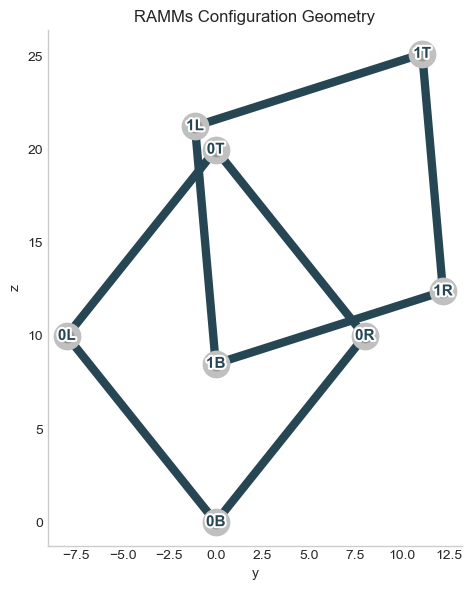

In [70]:
# print double contact point

# gen new config
max_theta_double_contact_conf = transform_top_unit_from_reference(BASELINE_CONF, 
                                                           theta_deg=max_theta_double_contact_pt["theta_deg"], 
                                                           z=max_theta_double_contact_pt["z"])

# Analyze configuration
pretty_print_nodes_and_gaps(max_theta_double_contact_conf)
# check segments
print_contact_debug_report(max_theta_double_contact_conf)
# plot config
plot_geometry(max_theta_double_contact_conf)

In [71]:
C_max_theta, max_theta_active_gaps, all_gaps = build_contact_jacobian(
    BASELINE_CONF,
    max_theta_double_contact_pt["theta_deg"],
    max_theta_double_contact_pt["z"],
    contact_tol=1e-6,
    h_theta=1e-5,
    h_z=1e-6,
)

pretty_print_contact_analysis(
    C_max_theta,
    max_theta_active_gaps,
    all_gaps,
    theta_deg=max_theta_double_contact_pt["theta_deg"],
    z=max_theta_double_contact_pt["z"],
)



CONTACT ANALYSIS

configuration:
  theta = 33.670791 deg
  z    = -1.498907

active gaps:
----------------------------------------------------------------------------------------------------
[0] node_0T_vs_seg_1B_1L
     short: 0T vs (1B-1L)
     value: -1.279e-11
[1] node_0R_vs_seg_1B_1R
     short: 0R vs (1B-1R)
     value: -3.441e-12

contact Jacobian C:
----------------------------------------------------------------------------------------------------
[[-0.19993343 -0.08696479]
 [-0.14097974  0.95282372]]

constraint gradients:
----------------------------------------------------------------------------------------------------
gap 0: - 0.1999*dtheta - 0.0870*dz
gap 1: - 0.1410*dtheta + 0.9528*dz

linear analysis:
----------------------------------------------------------------------------------------------------
rank(C)      = 2
nullity(C)   = 0
shape(C)     = (2, 2)

singular values:
------------------------------------------------------------------------------------------------

In [72]:
test_motions = {
    "+theta": np.array([+1.0, 0.0]),
    "-theta": np.array([-1.0, 0.0]),
    "+z":     np.array([0.0, +1.0]),
    "-z":     np.array([0.0, -1.0]),
}

pretty_print_motion_blocking(
    C_max_theta,
    max_theta_active_gaps,
    test_motions,
)


MOTION BLOCKING ANALYSIS

----------------------------------------------------------------------------------------------------
[gap 0]
name:        node_0T_vs_seg_1B_1L
short:       0T vs (1B-1L)
category:    segment_barrier
description: Top node of unit 0 against lower-left edge of unit 1

gradient:
[-0.19993343 -0.08696479]

motion tests:
----------------------------------------------------------------------------------------------------
+theta          dg = -1.999e-01    -->    closes gap / blocked
-theta          dg = +1.999e-01    -->    opens gap / allowed
+z              dg = -8.696e-02    -->    closes gap / blocked
-z              dg = +8.696e-02    -->    opens gap / allowed

----------------------------------------------------------------------------------------------------
[gap 1]
name:        node_0R_vs_seg_1B_1R
short:       0R vs (1B-1R)
category:    segment_barrier
description: Right node of unit 0 against lower-right edge of unit 1

gradient:
[-0.14097974  0.95282372]

##### Min theta (rotate left) double contact point

In [73]:
min_theta_double_contact_pt = find_double_contact_by_gap_pair(
    BASELINE_CONF,
    # seg 1R-1B hits 0R, seg 1L-1B hits 0T
    gap_a="node_0L_vs_seg_1B_1L",
    gap_b="node_0T_vs_seg_1B_1R",
    theta_guess=-38.6,
    z_guess=-1.8,
    tol=1e-6,
)


DOUBLE CONTACT SOLVE SUCCEEDED
theta_deg: -33.670790819947555
z: -1.4989068086818247
gap_a: node_0L_vs_seg_1B_1L = -3.443356710874923e-12
gap_b: node_0T_vs_seg_1B_1R = -1.2795542403409854e-11
residual norm: 1.3250758877731758e-11
solver message: The solution converged.
active names: ['node_0T_vs_seg_1B_1R', 'node_0L_vs_seg_1B_1L']



Nodes satisfies diamond shape constraints?: True

                    CONTACT STATE
State: DOUBLE-CONTACT

                      GAP VALUES
node_0B_vs_seg_1B_1L                           999999.000000   ✅ CLEAR
node_0B_vs_seg_1B_1R                           999999.000000   ✅ CLEAR
node_0L_vs_seg_1B_1L                          -0.000000   ⚠️ CONTACT
node_0R_vs_seg_1B_1R                           6.839339   ✅ CLEAR
node_0T_vs_seg_1B_1L                           9.956431   ✅ CLEAR
node_0T_vs_seg_1B_1R                          -0.000000   ⚠️ CONTACT
node_0T_vs_seg_1L_1T                           10.493901   ✅ CLEAR
node_0T_vs_seg_1R_1T                           0.537470   ✅ CLEAR
node_1B_vs_seg_0B_0L                           4.310591   ✅ CLEAR
node_1B_vs_seg_0B_0R                           4.310591   ✅ CLEAR
node_1B_vs_seg_0L_0T                           6.183310   ✅ CLEAR
node_1B_vs_seg_0R_0T                           6.183310   ✅ CLEAR
node_1L_vs_seg_0L_0T                           9999

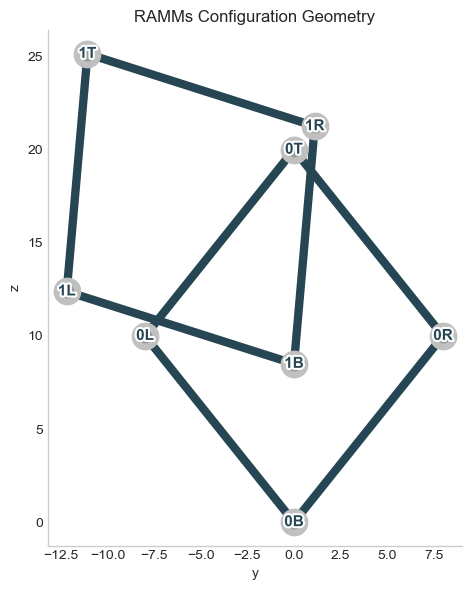

In [74]:
# print double contact point

# gen new config
min_theta_double_contact_conf = transform_top_unit_from_reference(BASELINE_CONF, 
                                                           theta_deg=min_theta_double_contact_pt["theta_deg"], 
                                                           z=min_theta_double_contact_pt["z"])

# Analyze configuration
pretty_print_nodes_and_gaps(min_theta_double_contact_conf)
# check segments
print_contact_debug_report(min_theta_double_contact_conf)
# plot config
plot_geometry(min_theta_double_contact_conf)

In [75]:
C_min_theta, min_theta_active_gaps, all_gaps = build_contact_jacobian(
    BASELINE_CONF,
    min_theta_double_contact_pt["theta_deg"],
    min_theta_double_contact_pt["z"],
    contact_tol=1e-6,
    h_theta=1e-5,
    h_z=1e-6,
)

pretty_print_contact_analysis(
    C_min_theta,
    min_theta_active_gaps,
    all_gaps,
    theta_deg=min_theta_double_contact_pt["theta_deg"],
    z=min_theta_double_contact_pt["z"],
)


CONTACT ANALYSIS

configuration:
  theta = -33.670791 deg
  z    = -1.498907

active gaps:
----------------------------------------------------------------------------------------------------
[0] node_0T_vs_seg_1B_1R
     short: 0T vs (1B-1R)
     value: -1.280e-11
[1] node_0L_vs_seg_1B_1L
     short: 0L vs (1B-1L)
     value: -3.443e-12

contact Jacobian C:
----------------------------------------------------------------------------------------------------
[[ 0.19993343 -0.08696479]
 [ 0.14097974  0.95282372]]

constraint gradients:
----------------------------------------------------------------------------------------------------
gap 0: + 0.1999*dtheta - 0.0870*dz
gap 1: + 0.1410*dtheta + 0.9528*dz

linear analysis:
----------------------------------------------------------------------------------------------------
rank(C)      = 2
nullity(C)   = 0
shape(C)     = (2, 2)

singular values:
-----------------------------------------------------------------------------------------------

In [76]:
pretty_print_motion_blocking(
    C_min_theta,
    min_theta_active_gaps,
    test_motions,
)


MOTION BLOCKING ANALYSIS

----------------------------------------------------------------------------------------------------
[gap 0]
name:        node_0T_vs_seg_1B_1R
short:       0T vs (1B-1R)
category:    segment_barrier
description: Top node of unit 0 against lower-right edge of unit 1

gradient:
[ 0.19993343 -0.08696479]

motion tests:
----------------------------------------------------------------------------------------------------
+theta          dg = +1.999e-01    -->    opens gap / allowed
-theta          dg = -1.999e-01    -->    closes gap / blocked
+z              dg = -8.696e-02    -->    closes gap / blocked
-z              dg = +8.696e-02    -->    opens gap / allowed

----------------------------------------------------------------------------------------------------
[gap 1]
name:        node_0L_vs_seg_1B_1L
short:       0L vs (1B-1L)
category:    segment_barrier
description: Left node of unit 0 against lower-left edge of unit 1

gradient:
[0.14097974 0.95282372]

m

##### Min z double contact point

In [77]:
min_z_double_contact_pt = find_double_contact_by_gap_pair(
    BASELINE_CONF,
    gap_a="node_0B_vs_seg_1B_1L",
    gap_b="node_0B_vs_seg_1B_1R",
    theta_guess=0,
    z_guess=-10,
    tol=1e-6,
)


DOUBLE CONTACT SOLVE FAILED
theta_deg: 0.0
z: -10.0
gap_a: node_0B_vs_seg_1B_1L = -1.0
gap_b: node_0B_vs_seg_1B_1R = -1.0
residual norm: 1.4142135623730951
solver message: The solution converged.
active names: []



The solver fails for the z-limited cases. The θ-limited contacts are found by intersecting two independent contact boundaries in (θ,z)-space. The z-limited contacts occur along a symmetry line where the two active gaps are redundant, so a two-equation root solve is poorly conditioned. A path-based bisection in z is the correct numerical method because the physical motion is one-dimensional.

so we need to try something else

**Path-Based Bisection Method**

The path-based bisection method follows a known physical motion path (here, varying only $z$) at fixed $\theta$ and searches for the first sign change in the limiting gap function.

It works in two stages:

1. **Path scan**  
   Move incrementally along the motion path and monitor the minimum gap:
   
   - $g > 0$: clear  
   - $g < 0$: overlap  

   The first sign change brackets the contact point.

2. **Bisection refinement**  
   Repeatedly split the bracket interval in half until the gap converges to: $g \approx 0$

This avoids solving a poorly conditioned multi-gap root problem and instead directly tracks the first physical contact event along the actual motion trajectory.

In [78]:
def scan_for_first_z_contact_point(
    conf_ref,
    theta_deg,
    z_start,
    z_end,
    n_scan=500,
    verbose=True,
):
    z_values = np.linspace(z_start, z_end, n_scan)

    prev_z = None
    prev_min_gap = None
    prev_gap_name = None

    history = []

    for z in z_values:

        conf = transform_top_unit_from_reference(
            conf_ref,
            theta_deg=theta_deg,
            z=z,
        )

        gaps = smooth_gap_functions(conf)

        min_gap_name = min(gaps, key=gaps.get)
        min_gap_val = gaps[min_gap_name]

        history.append({
            "z": z,
            "min_gap_name": min_gap_name,
            "min_gap_val": min_gap_val,
        })

        if verbose:
            print(
                f"z = {z:+8.4f} | "
                f"min gap = {min_gap_name:40s} | "
                f"value = {min_gap_val:+.6e}"
            )

        if prev_min_gap is not None:

            crossed_contact = (
                prev_min_gap > 0 and min_gap_val <= 0
            )

            if crossed_contact:

                print("\n" + "="*90)
                print("FIRST CONTACT BRACKET DETECTED")
                print("="*90)

                print(f"theta_deg = {theta_deg}")

                print("\nprevious clear point:")
                print(f"  z        = {prev_z:+.8f}")
                print(f"  gap name  = {prev_gap_name}")
                print(f"  gap value = {prev_min_gap:+.6e}")

                print("\ncurrent violated point:")
                print(f"  z        = {z:+.8f}")
                print(f"  gap name  = {min_gap_name}")
                print(f"  gap value = {min_gap_val:+.6e}")

                print("="*90 + "\n")

                return {
                    "success": True,
                    "theta_deg": theta_deg,

                    # bracket values for bisection
                    "prev_z": prev_z,
                    "curr_z": z,
                    "z_lo": prev_z,
                    "z_hi": z,

                    # contact info
                    "contact_gap": min_gap_name,
                    "prev_gap_name": prev_gap_name,
                    "curr_gap_name": min_gap_name,
                    "prev_gap_value": prev_min_gap,
                    "curr_gap_value": min_gap_val,

                    # current coarse point
                    "z": z,
                    "gap_value": min_gap_val,
                    "all_gaps": gaps,
                    "history": history,
                }

        prev_z = z
        prev_min_gap = min_gap_val
        prev_gap_name = min_gap_name

    print("\nNo contact found.\n")

    return {
        "success": False,
        "theta_deg": theta_deg,
        "z": None,
        "contact_gap": None,
        "history": history,
    }

In [79]:
min_z_contact = scan_for_first_z_contact_point(
    BASELINE_CONF,
    theta_deg=0,
    z_start=0,
    z_end=-12,
    n_scan=100,
)

z =  +0.0000 | min gap = node_1L_vs_seg_0L_0T                     | value = +5.246950e+00
z =  -0.1212 | min gap = node_1L_vs_seg_0L_0T                     | value = +5.171230e+00
z =  -0.2424 | min gap = node_1L_vs_seg_0L_0T                     | value = +5.095509e+00
z =  -0.3636 | min gap = node_1L_vs_seg_0L_0T                     | value = +5.019789e+00
z =  -0.4848 | min gap = node_1L_vs_seg_0L_0T                     | value = +4.944068e+00
z =  -0.6061 | min gap = node_1L_vs_seg_0L_0T                     | value = +4.868347e+00
z =  -0.7273 | min gap = node_1L_vs_seg_0L_0T                     | value = +4.792627e+00
z =  -0.8485 | min gap = node_1L_vs_seg_0L_0T                     | value = +4.716906e+00
z =  -0.9697 | min gap = node_1L_vs_seg_0L_0T                     | value = +4.641186e+00
z =  -1.0909 | min gap = node_1L_vs_seg_0L_0T                     | value = +4.565465e+00
z =  -1.2121 | min gap = node_1B_vs_seg_0B_0L                     | value = +4.489744e+00
z =  -1.33

Now that the first-contact bracket has been identified, the contact point can be refined using bisection. This repeatedly halves the interval surrounding the sign change until the limiting gap converges as close to zero as possible.

In [80]:
def refine_first_contact_along_z(
    conf_ref,
    theta_deg,
    z_lo,
    z_hi,
    gap_name,
    tol=1e-8,
    max_iter=100,
):
    """
    Refine z where one gap crosses zero.

    z_lo should be clear:    gap > 0
    z_hi should be violated: gap <= 0
    """

    for _ in range(max_iter):
        z_mid = 0.5 * (z_lo + z_hi)

        conf_mid = transform_top_unit_from_reference(
            conf_ref,
            theta_deg=theta_deg,
            z=z_mid,
        )

        gaps_mid = smooth_gap_functions(conf_mid)
        g_mid = gaps_mid[gap_name]

        if abs(g_mid) <= tol:
            return {
                "theta_deg": theta_deg,
                "z": z_mid,
                "contact_gap": gap_name,
                "gap_value": g_mid,
                "all_gaps": gaps_mid,
            }

        if g_mid > 0:
            z_lo = z_mid
        else:
            z_hi = z_mid

    return {
        "theta_deg": theta_deg,
        "z": z_mid,
        "contact_gap": gap_name,
        "gap_value": g_mid,
        "all_gaps": gaps_mid,
    }

In [81]:
min_z_contact_refined = refine_first_contact_along_z(
    BASELINE_CONF,
    theta_deg=min_z_contact["theta_deg"],
    z_lo=min_z_contact["prev_z"],
    z_hi=min_z_contact["curr_z"],
    gap_name=min_z_contact["contact_gap"],
    tol=1e-8,
)

In [82]:
print(min_z_contact_refined["z"])
print(min_z_contact_refined["contact_gap"])
print(min_z_contact_refined["gap_value"])

-8.399218934955016
node_1L_vs_seg_0L_0T
3.5524982955337236e-09


We have the contact point thats close enough to zero! We can now proceed with the rest of the analysis.

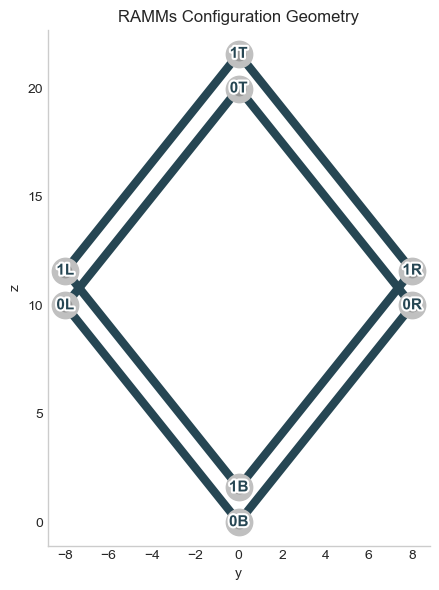


                 LOWER SEGMENT BARRIER DATA                 

Left barrier: seg_1L_1B vs 0L
  gap: 1.000000
  t_raw: 0.097609
  projection_interior: True
  signed_line_distance: 1.0000000035524983

Right barrier: seg_1R_1B vs 0R
  gap: 1.000000
  t_raw: 0.097609
  projection_interior: True
  signed_line_distance: 1.0000000035524983

                 POINT–SEGMENT CONTACT DATA                 

node_0L_vs_seg_1L_1B
  feature       : interior
  t_raw         : 0.097609
  t_clamped     : 0.097609
  closest_point : (y=-7.219131, z=10.624695)
  distance      : 1.000000



node_0R_vs_seg_1R_1B
  feature       : interior
  t_raw         : 0.097609
  t_clamped     : 0.097609
  closest_point : (y=7.219131, z=10.624695)
  distance      : 1.000000






In [83]:
min_z_contact_conf = transform_top_unit_from_reference(
    BASELINE_CONF,
    theta_deg=min_z_contact_refined["theta_deg"],
    z=min_z_contact_refined["z"],
)

plot_geometry(min_z_contact_conf)
print_contact_debug_report(min_z_contact_conf)

In [84]:
C_min_z, min_z_active_gaps, all_gaps = build_contact_jacobian(
    BASELINE_CONF,
    min_z_contact_refined["theta_deg"],
    min_z_contact_refined["z"],
    contact_tol=1e-6,
    h_theta=1e-5,
    h_z=1e-6,
)

pretty_print_contact_analysis(
    C_min_z,
    min_z_active_gaps,
    all_gaps,
    theta_deg=0,
    z=min_z_double_contact_pt["z"],
)


CONTACT ANALYSIS

configuration:
  theta = 0.000000 deg
  z    = -10.000000

active gaps:
----------------------------------------------------------------------------------------------------
[0] node_1L_vs_seg_0L_0T
     short: 1L vs (0L-0T)
     value: +3.552e-09
[1] node_1R_vs_seg_0R_0T
     short: 1R vs (0R-0T)
     value: +3.552e-09
[2] node_1B_vs_seg_0B_0L
     short: 1B vs (0B-0L)
     value: +3.552e-09
[3] node_1B_vs_seg_0B_0R
     short: 1B vs (0B-0R)
     value: +3.552e-09
[4] node_0T_vs_seg_1R_1T
     short: 0T vs (1R-1T)
     value: +3.552e-09
[5] node_0T_vs_seg_1L_1T
     short: 0T vs (1L-1T)
     value: +3.552e-09
[6] node_0R_vs_seg_1B_1R
     short: 0R vs (1B-1R)
     value: +3.552e-09
[7] node_0L_vs_seg_1B_1L
     short: 0L vs (1B-1L)
     value: +3.552e-09

contact Jacobian C:
----------------------------------------------------------------------------------------------------
[[-0.04906343  0.62469505]
 [ 0.04906343  0.62469505]
 [ 0.          0.62469505]
 [ 0.        

The contact Jacobian \(C\) is formed by stacking the gradients of the active gap functions:

$$
C(q)=
\begin{bmatrix}
\nabla g_1(q) \\
\nabla g_2(q) \\
\vdots
\end{bmatrix}
$$

For the reduced RAMMs system:

$$
q=[\theta,z]^T
$$

each row of \(C\) has two components, so:

$$
\operatorname{rank}(C)\le\min(m,n)
$$

where:
- \(m\) = number of active gaps (rows)
- \(n\) = number of generalized coordinates (columns)

In this case:

$$
C\in\mathbb{R}^{8\times2}
$$

so:

$$
\operatorname{rank}(C)\le2
$$

Although many active gaps are detected simultaneously, most are geometrically redundant. Only two independent constraint directions remain, giving:

$$
\operatorname{rank}(C)=2
$$

and therefore:

$$
\operatorname{nullity}(C)=0
$$

meaning no instantaneous motion directions remain available.

**Independence Test**

We'll conduct a formal analysis to prove there are only two independent rows. This independence test checks whether each new contact gradient adds a new constraint direction to the row space of $C$ (does it add a new column to $C$). If adding a row increases the rank of $C$, the constraint is independent; otherwise, it is redundant and already represented by the existing active gaps.

In [85]:
def print_constraint_independence_test(C, active_gaps, tol=1e-10):
    C = np.asarray(C, dtype=float)

    kept_rows = []
    kept_names = []
    current_rank = 0

    print("\n" + "="*100)
    print("CONSTRAINT INDEPENDENCE TEST")
    print("="*100)

    for i, (gap_name, row) in enumerate(zip(active_gaps, C)):

        trial_rows = kept_rows + [row]
        C_trial = np.vstack(trial_rows)

        new_rank = np.linalg.matrix_rank(C_trial, tol=tol) # check linear depenence of new row

        if new_rank > current_rank:
            status = "INDEPENDENT — adds new constraint direction"
            kept_rows.append(row)
            kept_names.append(gap_name)
            current_rank = new_rank
        else:
            status = "REDUNDANT — does not increase rank"

        print(f"\n[{i}] {gap_name}")
        print(f"    row: {row}")
        print(f"    rank before: {current_rank if status.startswith('REDUNDANT') else current_rank-1}")
        print(f"    rank after:  {new_rank}")
        print(f"    status: {status}")

    print("\n" + "-"*100)
    print("independent gaps kept:")
    for name in kept_names:
        print(" ", name)

    print(f"\nfinal rank = {current_rank}")
    print("="*100)

In [86]:
print_constraint_independence_test(
    C_min_z,
    min_z_active_gaps,
)


CONSTRAINT INDEPENDENCE TEST

[0] node_1L_vs_seg_0L_0T
    row: [-0.04906343  0.62469505]
    rank before: 0
    rank after:  1
    status: INDEPENDENT — adds new constraint direction

[1] node_1R_vs_seg_0R_0T
    row: [0.04906343 0.62469505]
    rank before: 1
    rank after:  2
    status: INDEPENDENT — adds new constraint direction

[2] node_1B_vs_seg_0B_0L
    row: [0.         0.62469505]
    rank before: 2
    rank after:  2
    status: REDUNDANT — does not increase rank

[3] node_1B_vs_seg_0B_0R
    row: [0.         0.62469505]
    rank before: 2
    rank after:  2
    status: REDUNDANT — does not increase rank

[4] node_0T_vs_seg_1R_1T
    row: [0.25075802 0.62469505]
    rank before: 2
    rank after:  2
    status: REDUNDANT — does not increase rank

[5] node_0T_vs_seg_1L_1T
    row: [-0.25075802  0.62469505]
    rank before: 2
    rank after:  2
    status: REDUNDANT — does not increase rank

[6] node_0R_vs_seg_1B_1R
    row: [-0.20169459  0.62469505]
    rank before: 2
    

In [87]:
pretty_print_motion_blocking(
    C_min_z,
    min_z_active_gaps,
    test_motions,
)


MOTION BLOCKING ANALYSIS

----------------------------------------------------------------------------------------------------
[gap 0]
name:        node_1L_vs_seg_0L_0T
short:       1L vs (0L-0T)
category:    segment_barrier
description: Left node of unit 1 against upper-left edge of unit 0

gradient:
[-0.04906343  0.62469505]

motion tests:
----------------------------------------------------------------------------------------------------
+theta          dg = -4.906e-02    -->    closes gap / blocked
-theta          dg = +4.906e-02    -->    opens gap / allowed
+z              dg = +6.247e-01    -->    opens gap / allowed
-z              dg = -6.247e-01    -->    closes gap / blocked

----------------------------------------------------------------------------------------------------
[gap 1]
name:        node_1R_vs_seg_0R_0T
short:       1R vs (0R-0T)
category:    segment_barrier
description: Right node of unit 1 against upper-right edge of unit 0

gradient:
[0.04906343 0.62469505]


##### Max z double contact point

For max z we have the same problem

In [88]:
max_z_double_contact_pt = find_double_contact_by_gap_pair(
    BASELINE_CONF,
    gap_a="node_0T_vs_seg_1B_1R",
    gap_b="node_0T_vs_seg_1B_1L",
    theta_guess=0,
    z_guess=10,
    tol=1e-6,
)


DOUBLE CONTACT SOLVE FAILED
theta_deg: 0.0
z: 10.0
gap_a: node_0T_vs_seg_1B_1R = -1.0
gap_b: node_0T_vs_seg_1B_1L = -1.0
residual norm: 1.4142135623730951
solver message: The solution converged.
active names: []



In [89]:
max_z_contact = scan_for_first_z_contact_point(
    BASELINE_CONF,
    theta_deg=0,
    z_start=0,
    z_end=12,
    n_scan=100,
)

z =  +0.0000 | min gap = node_1L_vs_seg_0L_0T                     | value = +5.246950e+00
z =  +0.1212 | min gap = node_1B_vs_seg_0R_0T                     | value = +5.171230e+00
z =  +0.2424 | min gap = node_1B_vs_seg_0R_0T                     | value = +5.095509e+00
z =  +0.3636 | min gap = node_1B_vs_seg_0R_0T                     | value = +5.019789e+00
z =  +0.4848 | min gap = node_1B_vs_seg_0R_0T                     | value = +4.944068e+00
z =  +0.6061 | min gap = node_1B_vs_seg_0R_0T                     | value = +4.868347e+00
z =  +0.7273 | min gap = node_1B_vs_seg_0R_0T                     | value = +4.792627e+00
z =  +0.8485 | min gap = node_1B_vs_seg_0R_0T                     | value = +4.716906e+00
z =  +0.9697 | min gap = node_1B_vs_seg_0R_0T                     | value = +4.641186e+00
z =  +1.0909 | min gap = node_1B_vs_seg_0R_0T                     | value = +4.565465e+00
z =  +1.2121 | min gap = node_1B_vs_seg_0R_0T                     | value = +4.489744e+00
z =  +1.33

In [90]:
max_z_contact_refined = refine_first_contact_along_z(
    BASELINE_CONF,
    theta_deg=max_z_contact["theta_deg"],
    z_lo=max_z_contact["prev_z"],
    z_hi=max_z_contact["curr_z"],
    gap_name=max_z_contact["contact_gap"],
    tol=1e-8,
)

In [91]:
print(max_z_contact_refined["z"])
print(max_z_contact_refined["contact_gap"])
print(max_z_contact_refined["gap_value"])

8.399218934955016
node_1B_vs_seg_0R_0T
3.5524982955337236e-09


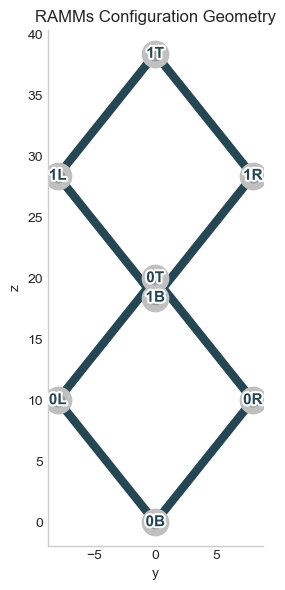


                 LOWER SEGMENT BARRIER DATA                 

Left barrier: seg_1L_1B vs 0L
  gap: 1000000.000000
  t_raw: 1.121904
  projection_interior: False
  signed_line_distance: 11.493900947535987

Right barrier: seg_1R_1B vs 0R
  gap: 1000000.000000
  t_raw: 1.121904
  projection_interior: False
  signed_line_distance: 11.493900947535987

                 POINT–SEGMENT CONTACT DATA                 

node_0L_vs_seg_1L_1B
  feature       : endpoint_B
  t_raw         : 1.121904
  t_clamped     : 1.000000
  closest_point : (y=0.000000, z=18.399219)
  distance      : 11.599434



node_0R_vs_seg_1R_1B
  feature       : endpoint_B
  t_raw         : 1.121904
  t_clamped     : 1.000000
  closest_point : (y=0.000000, z=18.399219)
  distance      : 11.599434






In [92]:
max_z_contact_conf = transform_top_unit_from_reference(
    BASELINE_CONF,
    theta_deg=max_z_contact_refined["theta_deg"],
    z=max_z_contact_refined["z"],
)

plot_geometry(max_z_contact_conf)
print_contact_debug_report(max_z_contact_conf)

In [93]:
C_max_z, max_z_active_gaps, all_gaps = build_contact_jacobian(
    BASELINE_CONF,
    max_z_contact_refined["theta_deg"],
    max_z_contact_refined["z"],
    contact_tol=1e-6,
    h_theta=1e-5,
    h_z=1e-6,
)

pretty_print_contact_analysis(
    C_max_z,
    max_z_active_gaps,
    all_gaps,
    theta_deg=0,
    z=max_z_double_contact_pt["z"],
)


CONTACT ANALYSIS

configuration:
  theta = 0.000000 deg
  z    = 10.000000

active gaps:
----------------------------------------------------------------------------------------------------
[0] node_1B_vs_seg_0R_0T
     short: 1B vs (0R-0T)
     value: +3.552e-09
[1] node_1B_vs_seg_0L_0T
     short: 1B vs (0L-0T)
     value: +3.552e-09
[2] node_0T_vs_seg_1B_1R
     short: 0T vs (1B-1R)
     value: +3.552e-09
[3] node_0T_vs_seg_1B_1L
     short: 0T vs (1B-1L)
     value: +3.552e-09

contact Jacobian C:
----------------------------------------------------------------------------------------------------
[[ 0.         -0.62469505]
 [ 0.         -0.62469505]
 [ 0.02181662 -0.62469505]
 [-0.02181662 -0.62469505]]

constraint gradients:
----------------------------------------------------------------------------------------------------
gap 0: + 0.0000*dtheta - 0.6247*dz
gap 1: + 0.0000*dtheta - 0.6247*dz
gap 2: + 0.0218*dtheta - 0.6247*dz
gap 3: - 0.0218*dtheta - 0.6247*dz

linear analysis:


In [94]:
print_constraint_independence_test(
    C_max_z,
    max_z_active_gaps,
)


CONSTRAINT INDEPENDENCE TEST

[0] node_1B_vs_seg_0R_0T
    row: [ 0.         -0.62469505]
    rank before: 0
    rank after:  1
    status: INDEPENDENT — adds new constraint direction

[1] node_1B_vs_seg_0L_0T
    row: [ 0.         -0.62469505]
    rank before: 1
    rank after:  1
    status: REDUNDANT — does not increase rank

[2] node_0T_vs_seg_1B_1R
    row: [ 0.02181662 -0.62469505]
    rank before: 1
    rank after:  2
    status: INDEPENDENT — adds new constraint direction

[3] node_0T_vs_seg_1B_1L
    row: [-0.02181662 -0.62469505]
    rank before: 2
    rank after:  2
    status: REDUNDANT — does not increase rank

----------------------------------------------------------------------------------------------------
independent gaps kept:
  node_1B_vs_seg_0R_0T
  node_0T_vs_seg_1B_1R

final rank = 2


In [95]:
pretty_print_motion_blocking(
    C_max_z,
    max_z_active_gaps,
    test_motions,
)


MOTION BLOCKING ANALYSIS

----------------------------------------------------------------------------------------------------
[gap 0]
name:        node_1B_vs_seg_0R_0T
short:       1B vs (0R-0T)
category:    segment_barrier
description: Bottom node of unit 1 against upper-right edge of unit 0

gradient:
[ 0.         -0.62469505]

motion tests:
----------------------------------------------------------------------------------------------------
+theta          dg = +0.000e+00    -->    tangent
-theta          dg = +0.000e+00    -->    tangent
+z              dg = -6.247e-01    -->    closes gap / blocked
-z              dg = +6.247e-01    -->    opens gap / allowed

----------------------------------------------------------------------------------------------------
[gap 1]
name:        node_1B_vs_seg_0L_0T
short:       1B vs (0L-0T)
category:    segment_barrier
description: Bottom node of unit 1 against upper-left edge of unit 0

gradient:
[ 0.         -0.62469505]

motion tests:
-----

#### Boundary Curve Analysis (Tracing) with Double-Contact Points
We do this because the boundary tracing method just randomly selects a predetermined amount of points to draw the contact boundary. You can set the number of points it samples, but there's no guarentee it will hit all four of these double-contact points (and is extremely unlikely unless you pick A LOT of points...with 800 points sampling takes ~2min, so...I wouldn't pick too many more.)

In [96]:
# print all the keys of boundary_result so we know what we need to fill in
pprint.pp(boundary_results[0])

{'theta_deg': -33.655462184873954,
 'z': -1.5011742234468939,
 'boundary_branch': 'lower',
 'contact_state': 'single-contact',
 'contact_info': [{'active_gap': 'node_0L_vs_seg_1B_1L',
                   'gap_value': 7.288571337582539e-07}]}


Create a helper to help us format our double-contact points like all the other points in boundary_results.

In [97]:
def make_boundary_result_from_contact_point(
    pt,
    conf_ref,
    contact_tol=1e-6,
    boundary_branch="manual_double_contact",
):
    """
    Convert a manually found contact point into the
    canonical boundary_result format.
    """

    conf = transform_top_unit_from_reference(
        conf_ref,
        pt["theta_deg"],
        pt["z"],
    )

    gaps = smooth_gap_functions(conf)

    active_contacts = [
        {
            "active_gap": name,
            "gap_value": value,
        }
        for name, value in gaps.items()
        if abs(value) <= contact_tol
    ]

    return {
        "theta_deg": pt["theta_deg"],
        "z": pt["z"],
        "boundary_branch": boundary_branch,

        "contact_state": (
            "double-contact"
            if len(active_contacts) >= 2
            else "single-contact"
        ),

        "contact_info": active_contacts,
    }

In [98]:
boundary_results_with_double_contacts = boundary_results.copy()

manual_points_with_branches = [
    (min_z_contact_refined, "lower"),
    (max_z_contact_refined, "upper"),
    (min_theta_double_contact_pt, "lower"),
    (max_theta_double_contact_pt, "lower"),
]

for pt, branch in manual_points_with_branches:
    if pt is not None and pt.get("success", True):
        boundary_results_with_double_contacts.append(
            make_boundary_result_from_contact_point(
                pt,
                BASELINE_CONF,
                boundary_branch=branch,
            )
        )

In [99]:
# make the boundary curve animation again with double contact points
fig2 = plot_boundary_with_geometry_movie(
    boundary_results_with_double_contacts,
    n_frames=30,
)

#### Examine the Eivengalues and Eigenvectors for Each Double-Contact Point

In [100]:
def get_C_from_contact_jacobian_output(out):
    """
    Handle build_contact_jacobian outputs like:
      C
      (C, active_contacts)
      (C, active_contacts, ...)
    """
    if isinstance(out, tuple):
        return out[0]
    return out

In [101]:
# TODO: print C^TC
def print_CtC_for_point(
    boundary_point,
    conf_ref=BASELINE_CONF,
    contact_tol=1e-6,
    h_theta=1e-5,
    h_z=1e-6,
):
    """
    Print C, C.T @ C, eigenvalues, and eigenvectors
    for one boundary point.
    """

    theta_deg = _safe_get(boundary_point, "theta_deg", np.nan)
    z = _safe_get(boundary_point, "z", np.nan)

    C_out = build_contact_jacobian(
        conf_ref,
        theta_deg,
        z,
        contact_tol=contact_tol,
        h_theta=h_theta,
        h_z=h_z,
    )

    C = get_C_from_contact_jacobian_output(C_out)

    CtC = C.T @ C

    eigvals, eigvecs = np.linalg.eigh(CtC)
    order = np.argsort(eigvals)

    eigvals = eigvals[order]
    eigvecs = eigvecs[:, order]

    print("=" * 70)
    print(f"theta_deg = {theta_deg:.6f}")
    print(f"z        = {z:.6f}")
    print()
    print("C =")
    print(C)
    print()
    print("C.T @ C =")
    print(CtC)
    print()
    print("eigenvalues =")
    print(eigvals)
    print()
    print("eigenvectors =")
    print(eigvecs)
    print()
    print("Interpretation:")
    print("  column 0 = eigenvector associated with eigenvalue 0")
    print("  column 1 = eigenvector associated with eigenvalue 1")
    print("=" * 70)

    return {
        "theta_deg": theta_deg,
        "z": z,
        "C": C,
        "CtC": CtC,
        "eigenvalues": eigvals,
        "eigenvectors": eigvecs,
    }

In [102]:
def print_CtC_for_double_contact_points(
    boundary_results,
    conf_ref=BASELINE_CONF,
    contact_tol=1e-6,
    h_theta=1e-5,
    h_z=1e-6,
):
    double_pts = [
        b for b in boundary_results
        if _safe_get(b, "contact_state", "unknown") == "double-contact"
    ]

    if not double_pts:
        print("No double-contact points found.")
        return []

    results = []

    for i, pt in enumerate(double_pts):
        print(f"\nDOUBLE CONTACT POINT {i + 1} / {len(double_pts)}")
        result = print_CtC_for_point(
            pt,
            conf_ref=conf_ref,
            contact_tol=contact_tol,
            h_theta=h_theta,
            h_z=h_z,
        )
        results.append(result)

    return results

In [103]:
CtC_results = print_CtC_for_double_contact_points(
    boundary_results_with_double_contacts,
    conf_ref=BASELINE_CONF,
)


DOUBLE CONTACT POINT 1 / 4
theta_deg = 0.000000
z        = -8.399219

C =
[[-0.04906343  0.62469505]
 [ 0.04906343  0.62469505]
 [ 0.          0.62469505]
 [ 0.          0.62469505]
 [ 0.25075802  0.62469505]
 [-0.25075802  0.62469505]
 [-0.20169459  0.62469505]
 [ 0.20169459  0.62469505]]

C.T @ C =
[[ 2.11935021e-01 -3.81452877e-11]
 [-3.81452877e-11  3.12195121e+00]]

eigenvalues =
[0.21193502 3.12195121]

eigenvectors =
[[-1.00000000e+00 -1.31082733e-11]
 [-1.31082733e-11  1.00000000e+00]]

Interpretation:
  column 0 = eigenvector associated with eigenvalue 0
  column 1 = eigenvector associated with eigenvalue 1

DOUBLE CONTACT POINT 2 / 4
theta_deg = 0.000000
z        = 8.399219

C =
[[ 0.         -0.62469505]
 [ 0.         -0.62469505]
 [ 0.02181662 -0.62469505]
 [-0.02181662 -0.62469505]]

C.T @ C =
[[9.51929444e-04 6.93550813e-12]
 [6.93550813e-12 1.56097560e+00]]

eigenvalues =
[9.51929444e-04 1.56097560e+00]

eigenvectors =
[[-1.00000000e+00  4.44577108e-12]
 [ 4.44577108e-1

In [104]:
def get_contact_eigenpairs_for_point(
    boundary_point,
    conf_ref,
    contact_tol=1e-6,
    h_theta=1e-5,
    h_z=1e-6,
):
    theta_deg = _safe_get(boundary_point, "theta_deg", np.nan)
    z = _safe_get(boundary_point, "z", np.nan)

    C_out = build_contact_jacobian(
        conf_ref,
        theta_deg,
        z,
        contact_tol=contact_tol,
        h_theta=h_theta,
        h_z=h_z,
    )

    C = get_C_from_contact_jacobian_output(C_out)

    CtC = C.T @ C

    eigvals, eigvecs = np.linalg.eigh(CtC)
    order = np.argsort(eigvals)

    eigvals = eigvals[order]
    eigvecs = eigvecs[:, order]

    return {
        "theta_deg": theta_deg,
        "z": z,
        "C": C,
        "CtC": CtC,
        "eigenvalues": eigvals,
        "eigenvectors": eigvecs,
    }

In [105]:
def get_double_contact_eigenpairs(
    boundary_results,
    conf_ref,
    contact_tol=1e-6,
    h_theta=1e-5,
    h_z=1e-6,
):
    """
    Compute eigenpairs for every double-contact point.
    """

    double_pts = [
        b for b in boundary_results
        if _safe_get(b, "contact_state", "unknown") == "double-contact"
    ]

    results = []

    for b in double_pts:
        eig_result = get_contact_eigenpairs_for_point(
            b,
            conf_ref,
            contact_tol=contact_tol,
            h_theta=h_theta,
            h_z=h_z,
        )

        eig_result["boundary_point"] = b
        eig_result["boundary_branch"] = _safe_get(b, "boundary_branch", "missing")
        eig_result["contact_info"] = _safe_get(b, "contact_info", [])

        results.append(eig_result)

    return results

In [106]:
def plot_boundary_select_contact_eigenvectors_two_dropdowns(
    boundary_results,
    conf_ref=BASELINE_CONF,
    contact_tol=1e-6,
    h_theta=1e-5,
    h_z=1e-6,
    vector_scale=2.0,
    zero_tol=1e-8,
):
    """
    Interactive boundary plot with two dropdowns:
      - one dropdown for double-contact points
      - one dropdown for single-contact points

    Selecting a point shows:
      - selected point marker
      - eigenvector arrows of C.T @ C
      - C.T @ C matrix
      - eigenvalues/eigenvectors in an annotation panel

    Color convention:
      - green = near-zero eigenvalue direction
      - state color = positive eigenvalue direction

    Uses z as the vertical generalized coordinate.
    Falls back to z for older boundary_result dictionaries.
    """

    def get_z(point, default=np.nan):
        return _safe_get(point, "z", _safe_get(point, "z", default))

    # ------------------------------------------------------------
    # 1) keep physical points
    # ------------------------------------------------------------
    kept = [
        b for b in boundary_results
        if _safe_get(b, "contact_state", "unknown")
        not in ["midpoint_off_boundary", "invalid_overlap"]
    ]

    if not kept:
        print("No valid boundary points found.")
        return

    contact_pts = [
        b for b in kept
        if _safe_get(b, "contact_state", "unknown")
        in ["single-contact", "double-contact"]
    ]

    if not contact_pts:
        print("No single- or double-contact points found.")
        return

    # useful ordering in dropdowns
    contact_pts = sorted(
        contact_pts,
        key=lambda b: (
            _safe_get(b, "contact_state", "unknown"),
            _safe_get(b, "boundary_branch", "missing"),
            _safe_get(b, "theta_deg", np.nan),
            get_z(b),
        )
    )

    fig = go.Figure()

    # ------------------------------------------------------------
    # 2) draw boundary curves
    # ------------------------------------------------------------
    for branch in ["lower", "upper"]:
        pts = [
            b for b in kept
            if _safe_get(b, "boundary_branch", "missing") == branch
        ]

        if len(pts) < 2:
            continue

        pts = sorted(
            pts,
            key=lambda b: _safe_get(b, "theta_deg", np.nan)
        )

        fig.add_trace(
            go.Scatter(
                x=[_safe_get(p, "theta_deg", np.nan) for p in pts],
                y=[get_z(p) for p in pts],
                mode="lines",
                name=f"boundary curve ({branch})",
                line=dict(
                    color="rgba(80,80,80,0.35)",
                    width=3,
                ),
                hoverinfo="skip",
            )
        )

    # ------------------------------------------------------------
    # 3) draw markers by contact state
    # ------------------------------------------------------------
    for state in ["single-contact", "double-contact"]:
        pts = [
            b for b in contact_pts
            if _safe_get(b, "contact_state", "unknown") == state
        ]

        if not pts:
            continue

        fig.add_trace(
            go.Scatter(
                x=[_safe_get(p, "theta_deg", np.nan) for p in pts],
                y=[get_z(p) for p in pts],
                mode="markers",
                name=f"{state} (n={len(pts)})",
                marker=dict(
                    size=7 if state == "single-contact" else 12,
                    color=palette.get(state, "#999999"),
                    line=dict(
                        color="black",
                        width=1 if state == "double-contact" else 0,
                    ),
                ),
                text=[
                    (
                        f"<b>{state}</b><br>"
                        f"theta: {_safe_get(p, 'theta_deg', np.nan):.4f}<br>"
                        f"z: {get_z(p):.6f}<br>"
                        f"branch: {_safe_get(p, 'boundary_branch', 'missing')}"
                    )
                    for p in pts
                ],
                hovertemplate="%{text}<extra></extra>",
            )
        )

    base_trace_count = len(fig.data)

    # ------------------------------------------------------------
    # 4) hidden selected-point traces + annotation groups
    # ------------------------------------------------------------
    eig_trace_groups = []
    eig_annotations = []

    for i, pt in enumerate(contact_pts):

        state = _safe_get(pt, "contact_state", "unknown")
        branch = _safe_get(pt, "boundary_branch", "missing")

        state_color = palette.get(state, "#999999")

        theta = _safe_get(pt, "theta_deg", np.nan)
        z = get_z(pt)

        # --------------------------------------------------------
        # compute eigensystem
        # --------------------------------------------------------
        C_out = build_contact_jacobian(
            conf_ref,
            theta,
            z,
            contact_tol=contact_tol,
            h_theta=h_theta,
            h_z=h_z,
        )

        C = get_C_from_contact_jacobian_output(C_out)

        CtC = C.T @ C

        eigvals, eigvecs = np.linalg.eigh(CtC)

        order = np.argsort(eigvals)

        eigvals = eigvals[order]
        eigvecs = eigvecs[:, order]

        group_indices = []

        # --------------------------------------------------------
        # selected point marker
        # --------------------------------------------------------
        fig.add_trace(
            go.Scatter(
                x=[theta],
                y=[z],

                mode="markers",

                name="selected point",

                marker=dict(
                    size=17,
                    color="white",
                    line=dict(
                        color="black",
                        width=3,
                    ),
                ),

                visible=False,
                hoverinfo="skip",
                showlegend=False,
            )
        )

        group_indices.append(len(fig.data) - 1)

        # --------------------------------------------------------
        # eigenvector arrows
        # --------------------------------------------------------
        arrow_annotations = []

        for j in range(2):

            lam = eigvals[j]
            v = eigvecs[:, j]

            norm = np.linalg.norm(v)

            if norm == 0:
                continue

            v = v / norm

            dtheta = vector_scale * v[0]
            z_vec = vector_scale * v[1]

            color = (
                "#2A9D8F"
                if abs(lam) <= zero_tol
                else state_color
            )

            # ----------------------------------------------------
            # positive direction arrow
            # ----------------------------------------------------
            arrow_annotations.append(
                dict(
                    x=theta + dtheta,
                    y=z + z_vec,

                    ax=theta,
                    ay=z,

                    xref="x",
                    yref="y",

                    axref="x",
                    ayref="y",

                    showarrow=True,

                    arrowhead=2,
                    arrowsize=0.8,
                    arrowwidth=2.5,

                    arrowcolor=color,

                    opacity=0.95,

                    text=f"λ{j+1}",

                    font=dict(
                        color=color,
                        size=12,
                    ),
                )
            )

            # ----------------------------------------------------
            # opposite direction arrow
            # ----------------------------------------------------
            arrow_annotations.append(
                dict(
                    x=theta - dtheta,
                    y=z - z_vec,

                    ax=theta,
                    ay=z,

                    xref="x",
                    yref="y",

                    axref="x",
                    ayref="y",

                    showarrow=True,

                    arrowhead=2,
                    arrowsize=0.65,
                    arrowwidth=1.5,

                    arrowcolor=color,

                    opacity=0.35,

                    text="",
                )
            )

        eig_trace_groups.append(group_indices)

        # --------------------------------------------------------
        # contact info
        # --------------------------------------------------------
        contact_info = _safe_get(pt, "contact_info", [])

        if contact_info:
            contact_str = "<br>".join(
                [
                    f"{c.get('active_gap', 'unknown')}: "
                    f"{c.get('gap_value', np.nan):.3e}"
                    for c in contact_info
                ]
            )
        else:
            contact_str = "None"

        C_str = np.array2string(
            C,
            precision=3,
            suppress_small=False
        ).replace("\n", "<br>")

        info_text = (
            f"<b>Selected {state}</b><br>"
            f"branch = {branch}<br><br>"

            f"θ = {theta:.4f}<br>"
            f"z = {z:.6f}<br><br>"

            f"<b>C</b><br>"
            f"{C_str}<br><br>"

            f"<b>CᵀC</b><br>"
            f"[{CtC[0,0]:.3e}, {CtC[0,1]:.3e}]<br>"
            f"[{CtC[1,0]:.3e}, {CtC[1,1]:.3e}]<br><br>"

            f"<b>Eigenvalues</b><br>"
            f"λ₁ = {eigvals[0]:.6e}<br>"
            f"λ₂ = {eigvals[1]:.6e}<br><br>"

            f"<b>Eigenvectors</b><br>"
            f"v₁ = [{eigvecs[0,0]:.4f}, {eigvecs[1,0]:.4f}]<br>"
            f"v₂ = [{eigvecs[0,1]:.4f}, {eigvecs[1,1]:.4f}]<br><br>"

            f"<b>Contacts</b><br>"
            f"{contact_str}<br><br>"

            f"Green = near-zero eigenvalue<br>"
            f"State color = positive eigenvalue"
        )

        text_panel_annotation = dict(
            x=1.02,
            y=0.83,

            xref="paper",
            yref="paper",

            text=info_text,

            showarrow=False,

            align="left",

            bordercolor="rgba(80,80,80,0.35)",
            borderwidth=1,

            bgcolor="white",

            font=dict(size=11),
        )

        eig_annotations.append(
            arrow_annotations + [text_panel_annotation]
        )

    # ------------------------------------------------------------
    # 5) helper visibility
    # ------------------------------------------------------------
    def visibility_for_selected_group(group_index=None):

        visible = (
            [True] * base_trace_count
            + [False] * (len(fig.data) - base_trace_count)
        )

        if group_index is not None:
            for idx in eig_trace_groups[group_index]:
                visible[idx] = True

        return visible

    # ------------------------------------------------------------
    # 6) dropdowns
    # ------------------------------------------------------------
    double_buttons = [
        dict(
            label="Double contacts",

            method="update",

            args=[
                {"visible": visibility_for_selected_group(None)},
                {
                    "title": "Boundary Contact States",
                    "annotations": [],
                },
            ],
        )
    ]

    single_buttons = [
        dict(
            label="Single contacts",

            method="update",

            args=[
                {"visible": visibility_for_selected_group(None)},
                {
                    "title": "Boundary Contact States",
                    "annotations": [],
                },
            ],
        )
    ]

    for i, pt in enumerate(contact_pts):

        state = _safe_get(pt, "contact_state", "unknown")
        branch = _safe_get(pt, "boundary_branch", "missing")

        theta = _safe_get(pt, "theta_deg", np.nan)
        z = get_z(pt)

        button = dict(
            label=f"{branch}: θ={theta:.2f}, z={z:.2f}",

            method="update",

            args=[
                {"visible": visibility_for_selected_group(i)},
                {
                    "title": f"Eigenvectors at Selected {state}",
                    "annotations": eig_annotations[i],
                },
            ],
        )

        if state == "double-contact":
            double_buttons.append(button)

        elif state == "single-contact":
            single_buttons.append(button)

    # ------------------------------------------------------------
    # 7) layout
    # ------------------------------------------------------------
    fig.update_layout(
        title="Boundary Contact States",

        xaxis_title="theta_deg",
        yaxis_title="contact boundary z",

        template="plotly_white",

        width=1250,
        height=720,

        legend=dict(
            x=1.02,
            y=0.35,

            xanchor="left",
            yanchor="middle",
        ),

        updatemenus=[
            dict(
                buttons=double_buttons,

                direction="down",

                x=1.02,
                y=1.0,

                xanchor="left",
                yanchor="top",

                bgcolor="white",
            ),

            dict(
                buttons=single_buttons,

                direction="down",

                x=1.02,
                y=0.90,

                xanchor="left",
                yanchor="top",

                bgcolor="white",
            ),
        ],

        annotations=[
            dict(
                x=1.02,
                y=1.06,

                xref="paper",
                yref="paper",

                text="<b>Select contact point</b>",

                showarrow=False,

                align="left",

                font=dict(size=12),
            )
        ],
    )

    fig.show()

    return fig

In [107]:
fig_select = plot_boundary_select_contact_eigenvectors_two_dropdowns(
    boundary_results_with_double_contacts,
    conf_ref=BASELINE_CONF,
    vector_scale=2.0,
)

## Plot Eigenvalue Landscape
warning: might not work if buid contact jacobian doesnt filter out non-active gaps!

In [108]:
boundary_results_with_double_contacts

[{'theta_deg': -33.655462184873954,
  'z': -1.5011742234468939,
  'boundary_branch': 'lower',
  'contact_state': 'single-contact',
  'contact_info': [{'active_gap': 'node_0L_vs_seg_1B_1L',
    'gap_value': 7.288571337582539e-07}]},
 {'theta_deg': -32.89915966386555,
  'z': -1.613479889466433,
  'boundary_branch': 'lower',
  'contact_state': 'single-contact',
  'contact_info': [{'active_gap': 'node_0L_vs_seg_1B_1L',
    'gap_value': 6.675826835778054e-07}]},
 {'theta_deg': -32.14285714285714,
  'z': -1.7265957696643288,
  'boundary_branch': 'lower',
  'contact_state': 'single-contact',
  'contact_info': [{'active_gap': 'node_0L_vs_seg_1B_1L',
    'gap_value': -9.466968705629242e-07}]},
 {'theta_deg': -31.386554621848738,
  'z': -1.8405688329784569,
  'boundary_branch': 'lower',
  'contact_state': 'single-contact',
  'contact_info': [{'active_gap': 'node_0L_vs_seg_1B_1L',
    'gap_value': -6.040281631536359e-07}]},
 {'theta_deg': -30.630252100840337,
  'z': -1.9554548550225448,
  'bounda

In [109]:
def solve_local_eigenproblem(
    boundary_point,
    conf_ref=BASELINE_CONF,
    contact_tol=1e-6,
    h_theta=1e-5,
    h_z=1e-6,
):
    theta = boundary_point["theta_deg"]
    z = boundary_point["z"]

    C_out = build_contact_jacobian(
        conf_ref,
        theta,
        z,
        contact_tol=contact_tol,
        h_theta=h_theta,
        h_z=h_z,
    )

    C = get_C_from_contact_jacobian_output(C_out)

    CtC = C.T @ C

    eigvals, eigvecs = np.linalg.eigh(CtC)

    return {
        "theta_deg": theta,
        "z": z,
        "CtC": CtC,
        "eigvals": eigvals,
        "eigvecs": eigvecs,
    }

In [110]:
theta_plot = []
z_plot = []
lambda_plot = []

for b in boundary_results_with_double_contacts:

    if b["contact_state"] in [
        "invalid_overlap",
        "midpoint_off_boundary",
    ]:
        continue

    result = solve_local_eigenproblem(b)

    eigvals = result["eigvals"]

    # remove numerical noise (treat small negatiev eigenvalues as 0 because physically they cant happen; just a numerical phenomenon)
    eigvals = np.maximum(eigvals, 0)

    lam_min = np.min(eigvals)

    theta_plot.append(result["theta_deg"])
    z_plot.append(result["z"])
    lambda_plot.append(lam_min)

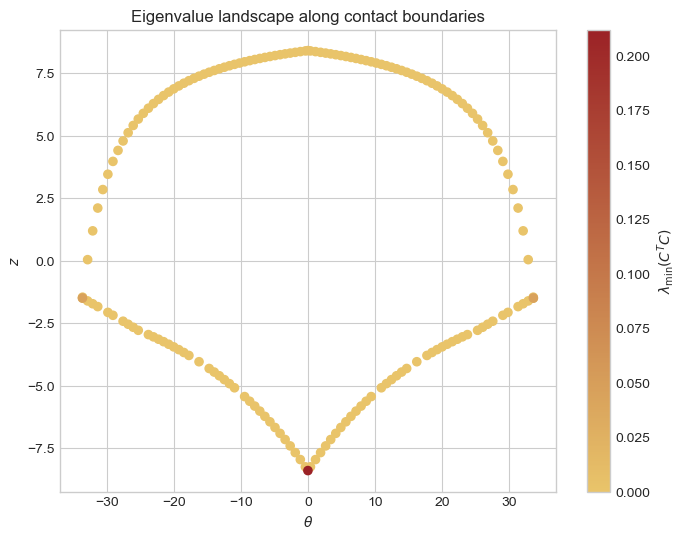

In [111]:
from matplotlib.colors import LinearSegmentedColormap

ramms_cmap = LinearSegmentedColormap.from_list(
    "ramms_constraint",
    [
        "#E9C46A",  # low lambda
        "#9B2226",  # high lambda
    ]
)


plt.figure(figsize=(8,6))

sc = plt.scatter(
    theta_plot,
    z_plot,
    c=lambda_plot,
    cmap=ramms_cmap,
    s=35,
)

plt.colorbar(
    sc,
    label=r"$\lambda_{\min}(C^TC)$"
)

plt.xlabel(r"$\theta$")
plt.ylabel(r"$z$")

plt.title(
    r"Eigenvalue landscape along contact boundaries"
)

plt.show()

In [112]:
import plotly.graph_objects as go
import numpy as np

theta = np.array(theta_plot)
z = np.array(z_plot)
lam = np.array(lambda_plot)

thresholds = [
    0,
    1e-17,
    5e-17,
    1e-16,
]

fig = go.Figure()

for i, tol in enumerate(thresholds):

    mask = lam > tol

    fig.add_trace(
        go.Scatter(
            x=theta[mask],
            y=z[mask],
            mode="markers",
            visible=(i == 0),

            marker=dict(
                size=8,
                color=lam[mask],
                colorscale=[
                    [0.0, "#E9C46A"],
                    [0.5, "#E76F51"],
                    [1.0, "#9B2226"],
                ],
                colorbar=dict(
                    title=r"$\lambda_{min}$"
                ),
                showscale=(i == 0),
            ),

            text=[
                f"θ={t:.2f}<br>"
                f"z={zz:.2f}<br>"
                f"λ={ll:.3e}"
                for t, zz, ll in zip(
                    theta[mask],
                    z[mask],
                    lam[mask],
                )
            ],

            hoverinfo="text",

            name=f"λ > {tol:.0e}",
        )
    )

buttons = []

for i, tol in enumerate(thresholds):

    visible = [False]*len(thresholds)
    visible[i] = True

    buttons.append(
        dict(
            label=f"λ > {tol:.0e}",
            method="update",
            args=[
                {"visible": visible},
                {"title":
                 f"Eigenvalue landscape (λ > {tol:.0e})"}
            ],
        )
    )

fig.update_layout(

    updatemenus=[
        dict(
            buttons=buttons,
            direction="down",
            x=1.02,
            y=1.0,
        )
    ],

    title="Eigenvalue landscape",

    xaxis_title=r"$\theta$",

    yaxis_title="z",

    width=850,
    height=700,
)

fig.show()

In [113]:
# ======================================================
# regenerate workspace explicitly for this plot
# ======================================================

theta_vals_workspace_overlay = np.linspace(-45, 45, 120)
z_vals_workspace_overlay = np.linspace(8.5, -12, 120)

workspace_results_overlay = sweep_workspace(
    BASELINE_CONF,
    theta_vals_workspace_overlay,
    z_vals_workspace_overlay,
)

In [114]:
workspace_results_overlay

[{'theta': -45.0,
  'z': 8.5,
  'contact_state': 'invalid_overlap',
  'min_gap': -0.8343527108877303},
 {'theta': -45.0,
  'z': 8.327731092436975,
  'contact_state': 'invalid_overlap',
  'min_gap': -0.8153287925302991},
 {'theta': -45.0,
  'z': 8.155462184873949,
  'contact_state': 'invalid_overlap',
  'min_gap': -0.7963048741728671},
 {'theta': -45.0,
  'z': 7.983193277310924,
  'contact_state': 'invalid_overlap',
  'min_gap': -0.7772809558154358},
 {'theta': -45.0,
  'z': 7.810924369747899,
  'contact_state': 'invalid_overlap',
  'min_gap': -0.7582570374580041},
 {'theta': -45.0,
  'z': 7.6386554621848735,
  'contact_state': 'invalid_overlap',
  'min_gap': -0.7392331191005725},
 {'theta': -45.0,
  'z': 7.466386554621849,
  'contact_state': 'invalid_overlap',
  'min_gap': -0.7202092007431412},
 {'theta': -45.0,
  'z': 7.294117647058823,
  'contact_state': 'invalid_overlap',
  'min_gap': -0.7011852823857095},
 {'theta': -45.0,
  'z': 7.121848739495798,
  'contact_state': 'invalid_overl

In [115]:
# check for double contacts
double_contacts = [
    r for r in workspace_results_overlay
    if _safe_get(r, "contact_state", "") == "double-contact"
]
len(double_contacts)

0

In [116]:
double_contacts_boundary_res = [
    r for r in boundary_results_with_double_contacts
    if _safe_get(r, "contact_state", "") == "double-contact"
]
len(double_contacts_boundary_res)

4

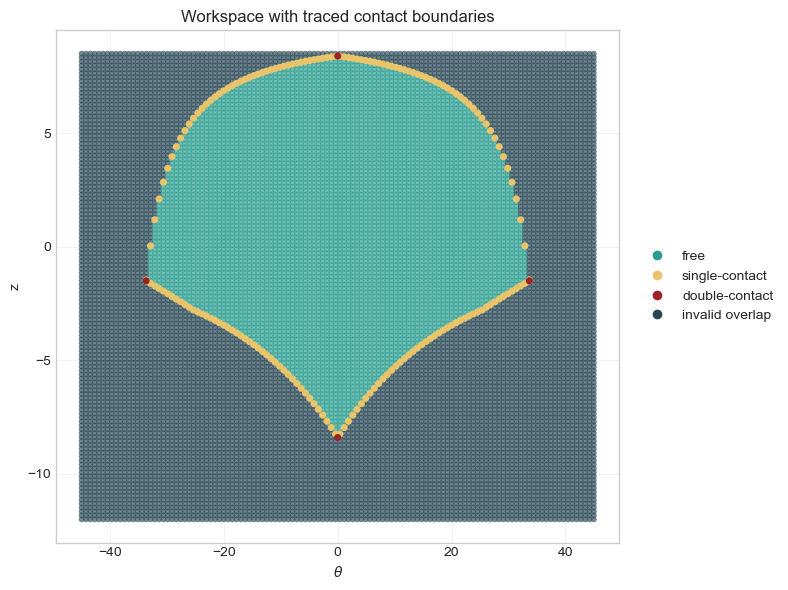

In [117]:

plt.figure(figsize=(8,6))

# ======================================================
# RAMMs colors
# ======================================================

state_colors = {

    "free": "#2A9D8F",

    "single-contact": "#E9C46A",

    "double-contact": "#9B2226",

    "invalid_overlap": "#264653",

}

# ======================================================
# workspace background
# ======================================================

theta_ws = []
z_ws = []
colors_ws = []

for r in workspace_results_overlay:

    theta_ws.append(

        _safe_get(
            r,
            "theta",
            np.nan,
        )

    )

    z_ws.append(

        _safe_get(
            r,
            "z",
            np.nan,
        )

    )

    state = _safe_get(

        r,

        "contact_state",

        "free",

    )

    colors_ws.append(

        state_colors.get(
            state,
            "#000000",
        )

    )

plt.scatter(

    theta_ws,

    z_ws,

    c=colors_ws,

    s=18,

    alpha=0.65,

    linewidths=0,

    zorder=1,

)

# ======================================================
# traced boundary overlay
# ======================================================

theta_boundary = []
z_boundary = []
boundary_colors = []

for b in boundary_results_with_double_contacts:

    theta = _safe_get(
        b,
        "theta_deg",
        np.nan,
    )

    z = _safe_get(
        b,
        "z",
        np.nan,
    )

    state = _safe_get(
        b,
        "contact_state",
        "",
    )

    if not (
        np.isfinite(theta)
        and np.isfinite(z)
    ):
        continue

    theta_boundary.append(theta)

    z_boundary.append(z)

    if state == "single-contact":

        boundary_colors.append(
            "#E9C46A"
        )

    elif state == "double-contact":

        boundary_colors.append(
            "#9B2226"
        )

    else:

        boundary_colors.append(
            "#E9C46A"
        )

plt.scatter(

    theta_boundary,

    z_boundary,

    c=boundary_colors,

    s=26,

    edgecolors="none",

    zorder=10,

)

# ======================================================
# labels
# ======================================================

plt.xlabel(r"$\theta$")

plt.ylabel("z")

plt.title(
    "Workspace with traced contact boundaries"
)

plt.grid(alpha=0.25)

legend_elements = [

    Line2D(
        [0],
        [0],
        marker='o',
        color='w',
        label='free',
        markerfacecolor='#2A9D8F',
        markersize=8,
    ),

    Line2D(
        [0],
        [0],
        marker='o',
        color='w',
        label='single-contact',
        markerfacecolor='#E9C46A',
        markersize=8,
    ),

    Line2D(
        [0],
        [0],
        marker='o',
        color='w',
        label='double-contact',
        markerfacecolor='#9B2226',
        markersize=8,
    ),

    Line2D(
        [0],
        [0],
        marker='o',
        color='w',
        label='invalid overlap',
        markerfacecolor='#264653',
        markersize=8,
    ),

]

plt.legend(

    handles=legend_elements,

    loc='center left',

    bbox_to_anchor=(1.02,0.5),

    frameon=False,

)

plt.tight_layout()

plt.show()